## The project of stock predicting
NAME = "Charon Tang"

COLLABORATORS = "Charon Tang"


### Get started: set up the environment 

In [1]:
from pathlib import Path
import sys

if "google.colab" in sys.modules:
    if not Path("/content/STOCK_PREDICTION").exists():
        !git clone https://github.com/CharonWTang/STOCK_PREDICTION.git
    %cd /content/STOCK_PREDICTION
    !git pull
    PROJECT_ROOT = Path("/content/STOCK_PREDICTION")
else:
    PROJECT_ROOT = Path(".")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "Data" / "train"

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_DIR =", DATA_DIR)
print("tools.py exists =", (PROJECT_ROOT / "tools.py").exists())

PROJECT_ROOT = .
DATA_DIR = Data/train
tools.py exists = True


In [2]:
# all required libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tools import *


In [3]:
## Import keras; set backend

import os
os.environ["KERAS_BACKEND"] = "tensorflow" # torch

import keras

print(f"Keras version {keras.__version__}, backend: {keras.backend.backend()}")

from keras.utils import plot_model

if keras.backend.backend() ==  "tensorflow":
    import tensorflow as tf
    print(f"TensorFlow version {tf.__version__}")
    from tensorflow.keras import layers
    from sklearn.metrics import classification_report, confusion_matrix
elif keras.backend.backend() ==  "torch":
    import torch
    print(f"PyTorch version {torch.__version__}")


Keras version 3.13.2, backend: tensorflow
TensorFlow version 2.20.0


### At the beginning of solving the problem: Defining
#### 1. Model type: choose a classification task
#### Reason:

* From a practical perspective, directly forecasting the exact next-day stock return is extremely difficult because realized returns are noisy and highly unpredictable.
* Therefore, I use realized future returns only to define directional labels. If the future return is above a positive threshold, the sample is labeled as Up; if it is below a negative threshold, it is labeled as Down; otherwise, it is labeled as Flat.
* The Flat class represents an ambiguous region where the future movement is too small to be reliable. During training, I remove Flat observations and let the model learn only clearer Up and Down cases.
* At prediction time, the model outputs only Up or Down probabilities. The trading strategy can still choose Keep or no-trade when the model confidence is low.

#### 2. For Performance Metric
Since the model is trained as a binary Up/Down classifier, I use Macro F1-score and a confusion matrix to evaluate directional prediction performance. However, classification metrics are not sufficient by themselves for a trading problem. Therefore, I also evaluate whether the trading strategy creates excess return relative to a benchmark or buy-and-hold strategy on the holdout period.

#### 3. Model selection
I will primarily use RNN and LSTM as the main models, since the problem involves time-series patterns. The input features can include historical returns, rolling volatility, volume changes, and technical indicators. Past returns are useful as input features, but the target remains directional rather than the exact future return, because predicting the exact future return would introduce more noise into the learning objective.

## Get the data

In [4]:
# loading the data

AAPL_data = pd.read_csv(DATA_DIR / 'AAPL.csv')
# set the date as the index
# parse Dt to real datetime, then set index
AAPL_data['Dt'] = pd.to_datetime(AAPL_data['Dt'], format='%Y-%m-%d', errors='coerce')
AAPL_data = AAPL_data.dropna(subset=['Dt']).sort_values('Dt').drop_duplicates(subset='Dt')
AAPL_data.set_index('Dt', inplace=True)
AAPL_data.head()

,Adj Close,Close,Div,Factor,High,Low,Open,Volume
Dt,,,,,,,,
2000-01-03,3.4785,111.938,0.0,1.0,112.500,101.688,104.8750,133949200.0
2000-01-04,3.1852,102.500,0.0,1.0,110.625,101.188,108.2500,128094400.0
2000-01-05,3.2318,104.000,0.0,1.0,110.563,103.000,103.7500,194580400.0
2000-01-06,2.9521,95.000,0.0,1.0,107.000,95.000,106.1183,191993200.0
2000-01-07,3.0920,99.500,0.0,1.0,101.000,95.500,96.5000,115183600.0


## Get the return of the stock, which is the target
I use the adj close to get the return, as this avoid the influence of event of divident giving and stock spliting

In [5]:
# get the return of the stock
AAPLReturn = AAPL_data['Adj Close'].pct_change()
AAPLReturn.head()

Dt
2000-01-03         NaN
2000-01-04   -0.084318
2000-01-05    0.014630
2000-01-06   -0.086546
2000-01-07    0.047390
Name: Adj Close, dtype: float64

In [6]:
# get little understanding of the data
AAPL_data.describe()

,Adj Close,Close,Div,Factor,High,Low,Open,Volume
count,4277.000000,4277.000000,4277.000000,4277.000000,4277.000000,4277.000000,4277.000000,4.277000e+03
mean,34.065846,170.450354,0.001999,1.001870,172.424040,168.407568,170.528689,1.299660e+08
std,36.698987,173.484604,0.031011,0.094251,174.989551,171.934671,173.604272,9.970883e+07
min,0.815400,13.120000,0.000000,1.000000,13.190000,12.720000,12.990000,9.835000e+06
25%,3.115300,39.759000,0.000000,1.000000,40.260000,39.030000,39.530000,6.363350e+07
50%,16.948300,106.745000,0.000000,1.000000,108.360000,105.200000,106.959000,1.016484e+08
75%,62.413600,222.250000,0.000000,1.000000,224.980000,217.890000,220.010000,1.679636e+08
max,122.771400,702.100000,0.570000,7.000000,705.070000,699.570000,702.410000,1.855410e+09


In [7]:
AAPL_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4277 entries, 2000-01-03 to 2016-12-30
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  4277 non-null   float64
 1   Close      4277 non-null   float64
 2   Div        4277 non-null   float64
 3   Factor     4277 non-null   float64
 4   High       4277 non-null   float64
 5   Low        4277 non-null   float64
 6   Open       4277 non-null   float64
 7   Volume     4277 non-null   float64
dtypes: float64(8)
memory usage: 300.7 KB


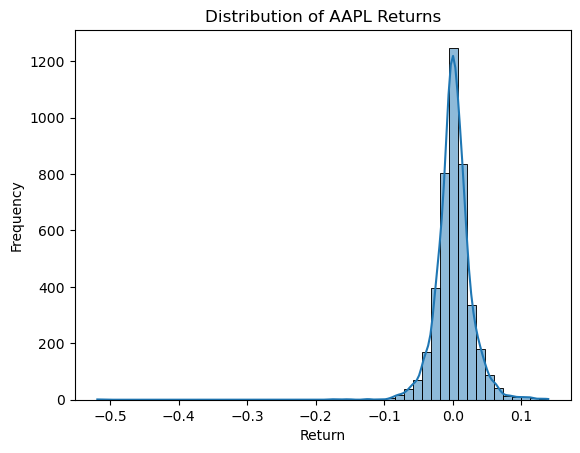

In [8]:
# get the distribution of the return
import matplotlib.pyplot as plt
import seaborn as sns   
sns.histplot(AAPLReturn.dropna(), bins=50, kde=True)
plt.title('Distribution of AAPL Returns')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.show()

In [9]:
# there is a very long tail in the distribution, is this a error in data or not? Check it.
AAPLReturn[AAPLReturn < -0.3]


Dt
2000-09-29   -0.518677
Name: Adj Close, dtype: float64

Already check the news, this is the real market data.
So the AAPL stock data, is clean and no need for other proprocess

## Get the train/validation/train split
This time only for AAPL data itself

But before the split, some decision have to do
* The window of date for each training sample: I will first set it to 1 year (252 days). But I will set the function flexible to adjust the window
* The data arrange: 0.15 for validation, 0.15 for training, and in order to get the max use of the data, so I will use a window just slide through to get the data

In [10]:
# get the data into three part: up, down and flat

x_train, y_train, x_val, y_val, x_test, y_test = single_stock_split(AAPL_data, AAPLReturn, train_size=0.7, val_size=0.15, test_size=0.15, window_size = 252, add_transformed_features=0, target_mode="raw", return_index=False)

In [11]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape) 
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (2816, 252, 8)
y_train shape: (2816,)
x_val shape: (603, 252, 8)
y_val shape: (603,)
x_test shape: (605, 252, 8)
y_test shape: (605,)


### Exploratory Data Analysis

In [12]:
# using -0.01 as down threshold and 0.01 as up threshold, get the category of the return
y_train_cat = np.where(y_train < -0.01, 0, np.where(y_train > 0.01, 2, 1))
y_val_cat = np.where(y_val < -0.01, 0, np.where(y_val > 0.01, 2, 1))
y_test_cat = np.where(y_test < -0.01, 0, np.where(y_test > 0.01, 2, 1))   

# get the ratio of the three categories in the training set
unique, counts = np.unique(y_train_cat, return_counts=True)
category_counts = dict(zip(unique, counts))
print("Training set category distribution:")
for category, count in category_counts.items():
    print(f"Category {category}: {count} samples, {count/len(y_train_cat)*100:.2f}%")

unique, counts = np.unique(y_val_cat, return_counts=True)
category_counts = dict(zip(unique, counts))
print("Validation set category distribution:")
for category, count in category_counts.items():
    print(f"Category {category}: {count} samples, {count/len(y_val_cat)*100:.2f}%")

Training set category distribution:
Category 0: 810 samples, 28.76%
Category 1: 1061 samples, 37.68%
Category 2: 945 samples, 33.56%
Validation set category distribution:
Category 0: 127 samples, 21.06%
Category 1: 322 samples, 53.40%
Category 2: 154 samples, 25.54%


There is a change in the distribution, but this is kinda acceptable


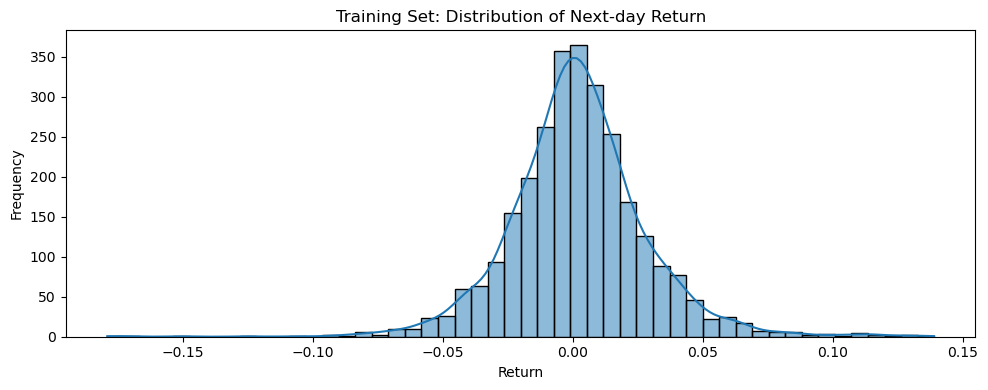

Top correlated last-day features with Return:
Volume       0.009736
Factor      -0.007064
Adj Close   -0.004444
Close       -0.003183
High        -0.002762
Open        -0.002670
Low         -0.002300
Div               NaN
dtype: float64


/opt/miniconda3/envs/ml_course/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/ml_course/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


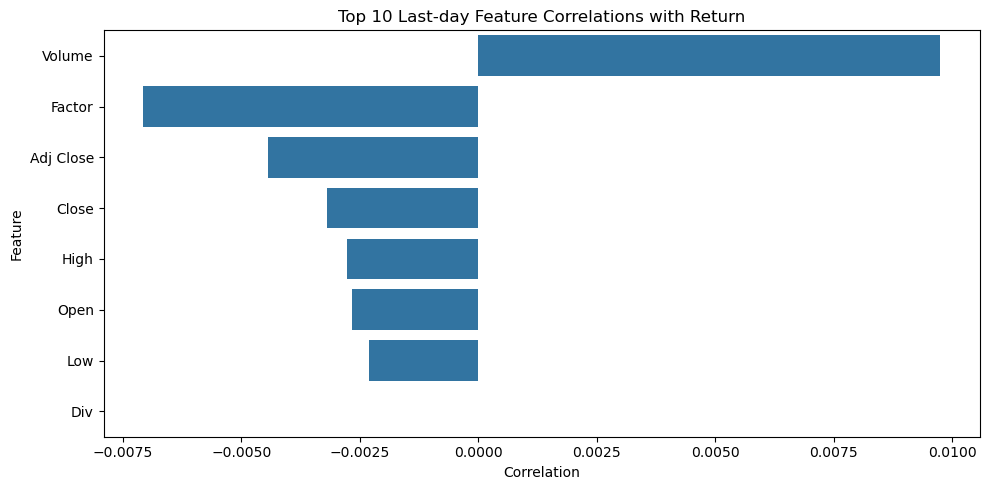

/opt/miniconda3/envs/ml_course/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/ml_course/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Top correlated window-summary features with Return:
Volume_min       -0.019784
Factor_mean       0.012703
Factor_max        0.012703
Factor_std        0.012703
Volume_mean      -0.010652
Adj Close_std    -0.007400
Adj Close_max    -0.004203
Volume_std        0.004007
Adj Close_mean   -0.003988
High_std          0.003846
dtype: float64


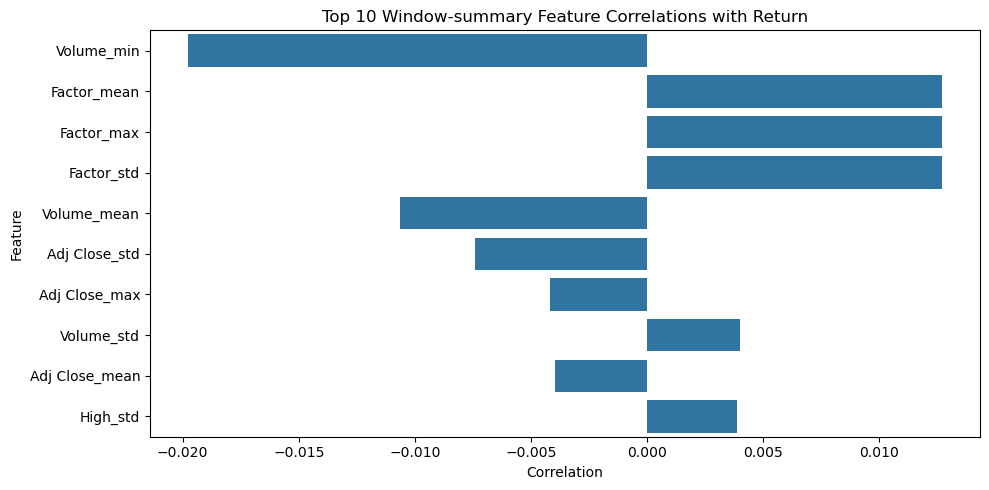

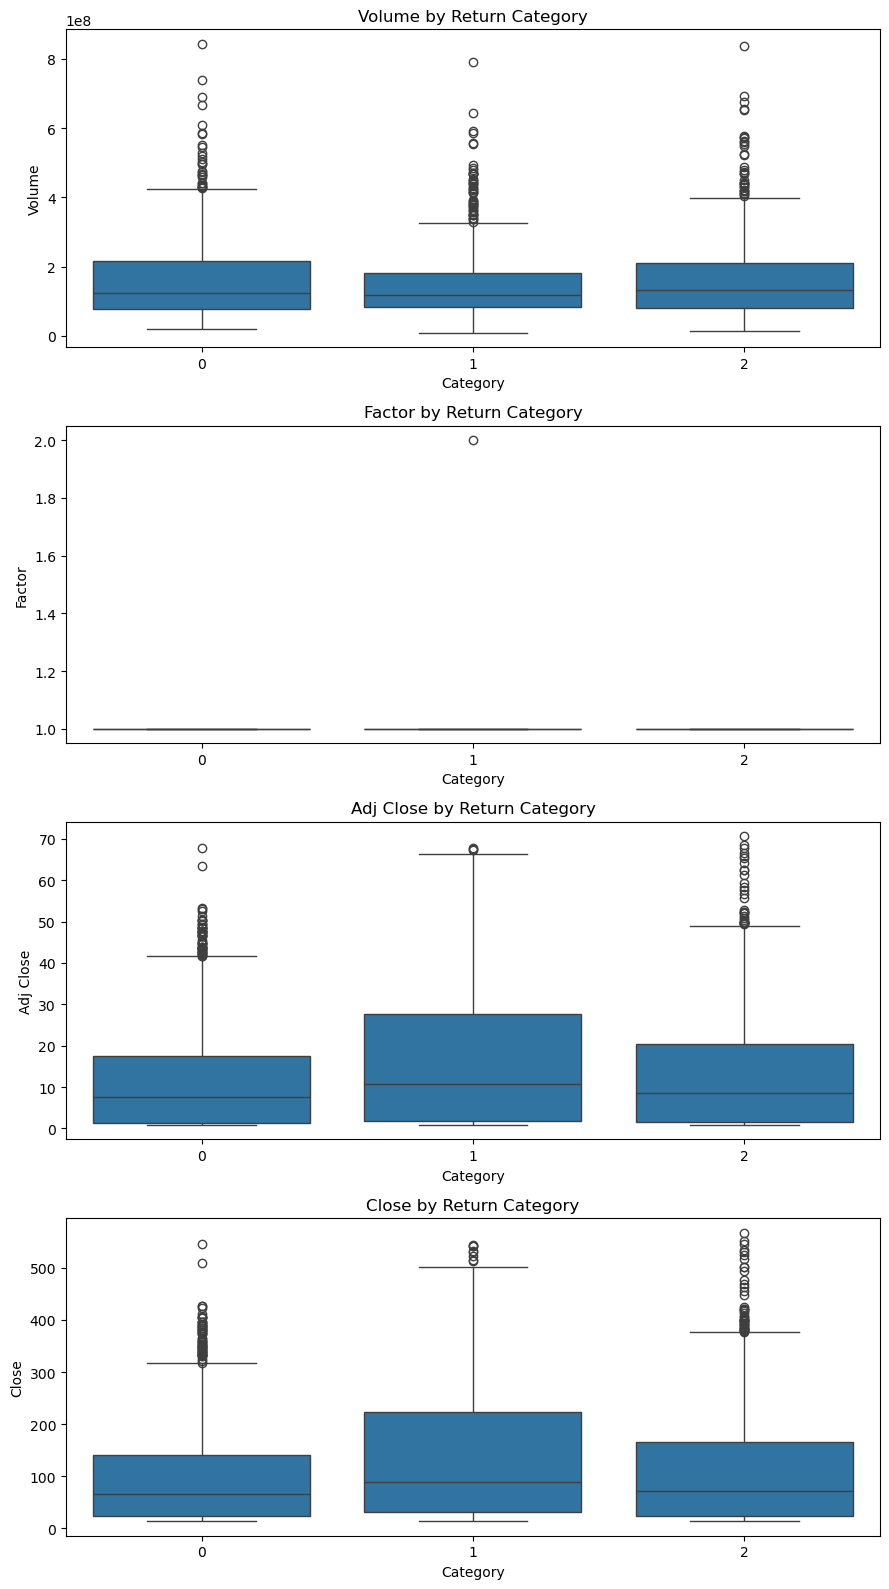

In [13]:
# EDA using train data only


# feature names: keep the same order as single_stock_split
feature_names = AAPL_data.columns.tolist()

# use only train set
X_last = pd.DataFrame(x_train[:, -1, :], columns=feature_names)
y = pd.Series(y_train, name="Return")

# 1) distribution of target in train set
plt.figure(figsize=(10, 4))
sns.histplot(y, bins=50, kde=True)
plt.title("Training Set: Distribution of Next-day Return")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 2) correlation of last-day features with target
corr_last = X_last.corrwith(y).sort_values(key=lambda s: s.abs(), ascending=False)
print("Top correlated last-day features with Return:")
print(corr_last.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(x=corr_last.head(10).values, y=corr_last.head(10).index, orient="h")
plt.title("Top 10 Last-day Feature Correlations with Return")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 3) window-level summary features
X_mean = pd.DataFrame(x_train.mean(axis=1), columns=[f"{c}_mean" for c in feature_names])
X_std = pd.DataFrame(x_train.std(axis=1), columns=[f"{c}_std" for c in feature_names])
X_min = pd.DataFrame(x_train.min(axis=1), columns=[f"{c}_min" for c in feature_names])
X_max = pd.DataFrame(x_train.max(axis=1), columns=[f"{c}_max" for c in feature_names])

summary_df = pd.concat([X_mean, X_std, X_min, X_max], axis=1)
corr_summary = summary_df.corrwith(y).sort_values(key=lambda s: s.abs(), ascending=False)

print("Top correlated window-summary features with Return:")
print(corr_summary.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(x=corr_summary.head(10).values, y=corr_summary.head(10).index, orient="h")
plt.title("Top 10 Window-summary Feature Correlations with Return")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 4) compare feature behavior for up / down / flat
top_feats = corr_last.head(4).index.tolist()
fig, axes = plt.subplots(len(top_feats), 1, figsize=(9, 4 * len(top_feats)))
if len(top_feats) == 1:
    axes = [axes]

for ax, col in zip(axes, top_feats):
    sns.boxplot(x=y_train_cat, y=X_last[col], ax=ax)
    ax.set_title(f"{col} by Return Category")
    ax.set_xlabel("Category")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

For the original data, it barely shows any prediction power.
First we see the if there is some magic from this orignal data's deep learning model. Get some baseline.
Then, we try: transfer of the data maybe helpful? Get some more transformation for data


### Current Modeling Method

The goal of this project is not to forecast the exact next-day return, because the return value is very noisy. Instead, I treat the problem as a directional classification task and let the model learn whether the next return is more likely to be Down or Up.

The training labels and the validation/test labels use slightly different rules. In the training split, I remove ambiguous Flat observations: returns above the positive threshold are labeled as Up, returns below the negative threshold are labeled as Down, and small returns around zero are dropped. This makes the model learn from clearer directional examples. In the validation and test splits, I keep all observations and use zero return as the boundary: non-positive returns are labeled as Down and positive returns are labeled as Up. This is closer to the real trading evaluation setting, where every holdout day should be evaluated.

The model itself only outputs two classes, Down and Up. I still use Macro F1-score and the confusion matrix to evaluate the directional classification quality. However, classification accuracy is not enough for a trading problem, so I also keep the original raw returns for validation and test. After prediction, I convert the predicted direction into a trading position and calculate the strategy return. The final trading evaluation compares the strategy return with a benchmark, such as AAPL buy-and-hold, and reports the excess return.

In [14]:
# RNN baseline for the binary direction task
# target_mode="direction_binary" drops Flat windows in train, while val/test use 0 return as the Down/Up boundary
(
    x_train, y_train, x_val, y_val, x_test, y_test,
    idx_train, idx_val, idx_test,
    train_raw_return, val_raw_return, test_raw_return,
) = single_stock_split(
    AAPL_data,
    AAPLReturn,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
    window_size=252,
    add_transformed_features=0,
    target_mode="direction_binary",
    return_index=True,
    return_raw_target=True,
)
y_train_rnn = y_train
y_val_rnn = y_val
y_test_rnn = y_test

print("train label counts [Down, Up]:", np.bincount(y_train_rnn, minlength=2))
print("val label counts [Down, Up]:", np.bincount(y_val_rnn, minlength=2))
print("test label counts [Down, Up]:", np.bincount(y_test_rnn, minlength=2))
print("val raw return shape:", val_raw_return.shape, "val index shape:", idx_val.shape)
print("test raw return shape:", test_raw_return.shape, "test index shape:", idx_test.shape)

# Scale each feature using statistics from the training set only
train_mean = x_train.mean(axis=(0, 1), keepdims=True)
train_std = x_train.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_rnn = (x_train - train_mean) / train_std
x_val_rnn = (x_val - train_mean) / train_std
x_test_rnn = (x_test - train_mean) / train_std

num_classes = 2
input_shape = x_train_rnn.shape[1:]

keras.backend.clear_session()

rnn_model = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.SimpleRNN(64, activation="tanh"),
    layers.Dropout(0.1),
    layers.Dense(16, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
])

rnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes)],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_macro_f1",
    mode="max",
    patience=5,
    restore_best_weights=True,
)

history = rnn_model.fit(
    x_train_rnn,
    y_train_rnn,
    validation_data=(x_val_rnn, y_val_rnn),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

# direct validation evaluation helper
rnn_results = evaluate_keras_model_on_validation(
    model=rnn_model,
    history=history,
    x_val=x_val_rnn,
    y_val_cat=y_val_rnn,
    prefix="v1_binary",
    class_names=("Down", "Up"),
    raw_return=val_raw_return,
    benchmark_name="AAPL buy-and-hold",
)


train label counts [Down, Up]: [810 945]
val label counts [Down, Up]: [303 300]
test label counts [Down, Up]: [295 310]
val raw return shape: (603,) val index shape: (603,)
test raw return shape: (605,) test index shape: (605,)
Epoch 1/30


KeyboardInterrupt: 

### Baseline Result with RNN and data of AAPL

[v1_binary] Validation macro_f1: 0.3471

[v1_binary] Validation loss: 0.7358

And there is an imbalance of the result. So the prediction in the original data directly is not good. The transfer of the data can be tried.

After changing the learning objective to binary Up/Down labels, the model is no longer allowed to hide in the Flat class. The next improvement is not to punish Flat predictions directly, but to check whether the binary predictions are useful for trading.

My next improvement ideas:
* Handle class imbalance between Down and Up if one class dominates.
* Evaluate the final strategy by excess return on the holdout period, not only by classification metrics.


To adjust for the loss function may be a good idea, but after trying different loss matrix, the biggest problem right now for the model is there is nothing for it to learn. 
Even after changing the loss matrix to stop the model to all predict flat, it then change to strategy that predicting everything in Up/Down, which means that model have no direction to learn, so it just guessing all the same result.

### Transform of data and expand the data

In [ ]:
# make the transformation of the data
# what is the potential informatiion within the data?

# some ideas:
# Returns
# Moving averages of return(e.g., 5-day, 20-day, 50-day)
# MACD  (one EMA minus another EMA)
# Volatility measures (e.g., rolling standard deviation of returns)
# Bolling bands (moving average plus/minus a multiple of rolling std)
# Relative Strength Index (RSI)
# SAR
# strat_cci 
# strat_arbr 
# pvi
# volume z-score
# return sign / streak

# here lets see the results of adding some of these features to the binary RNN model, and see if it can improve the performance
(
    x_train_ext, y_train_ext, x_val_ext, y_val_ext, x_test_ext, y_test_ext,
    idx_train_ext, idx_val_ext, idx_test_ext,
    train_raw_return_ext, val_raw_return_ext, test_raw_return_ext,
) = single_stock_split(
    AAPL_data,
    AAPLReturn,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
    window_size=252,
    add_transformed_features=1,
    target_mode="direction_binary",
    return_index=True,
    return_raw_target=True,
)

print("x_train_ext shape:", x_train_ext.shape)
print("y_train_ext shape:", y_train_ext.shape)
print("x_val_ext shape:", x_val_ext.shape) 
print("y_val_ext shape:", y_val_ext.shape)
print("x_test_ext shape:", x_test_ext.shape)
print("y_test_ext shape:", y_test_ext.shape)
print("train label counts [Down, Up]:", np.bincount(y_train_ext, minlength=2))
print("val label counts [Down, Up]:", np.bincount(y_val_ext, minlength=2))
print("test label counts [Down, Up]:", np.bincount(y_test_ext, minlength=2))
print("val raw return shape:", val_raw_return_ext.shape, "val index shape:", idx_val_ext.shape)
print("test raw return shape:", test_raw_return_ext.shape, "test index shape:", idx_test_ext.shape)


x_train_ext shape: (1721, 252, 29)
y_train_ext shape: (1721,)
x_val_ext shape: (596, 252, 29)
y_val_ext shape: (596,)
x_test_ext shape: (597, 252, 29)
y_test_ext shape: (597,)
train label counts [Down, Up]: [792 929]
val label counts [Down, Up]: [297 299]
test label counts [Down, Up]: [294 303]
val raw return shape: (596,) val index shape: (596,)
test raw return shape: (597,) test index shape: (597,)


Epoch 1/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 2.4973 - macro_f1: 0.5026 - val_loss: 2.5508 - val_macro_f1: 0.3770 - learning_rate: 7.0000e-04
Epoch 2/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 2.4498 - macro_f1: 0.5052 - val_loss: 2.5586 - val_macro_f1: 0.3687 - learning_rate: 7.0000e-04
Epoch 3/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 2.4458 - macro_f1: 0.5041 - val_loss: 2.5963 - val_macro_f1: 0.3341 - learning_rate: 7.0000e-04
Epoch 4/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 2.4401 - macro_f1: 0.5323 - val_loss: 2.5985 - val_macro_f1: 0.3341 - learning_rate: 7.0000e-04
Epoch 5/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 2.4049 - macro_f1: 0.5290 - val_loss: 2.6783 - val_macro_f1: 0.3341 - learning_rate: 3.5000e-04
Epoch 6/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 2.3682 - macro_f1: 0.5507 - val_loss: 2.7098 - val_macro_f1: 0.3341 - learning_rate: 3.5000e-04
Epoch 7/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 2.3374 - ma

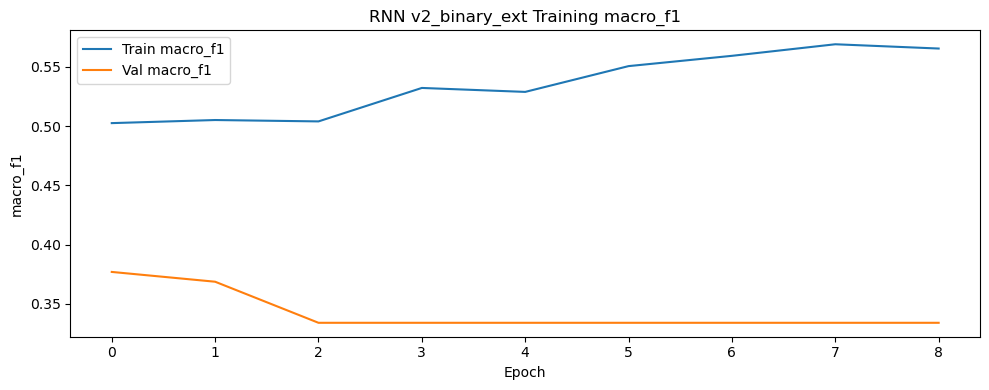

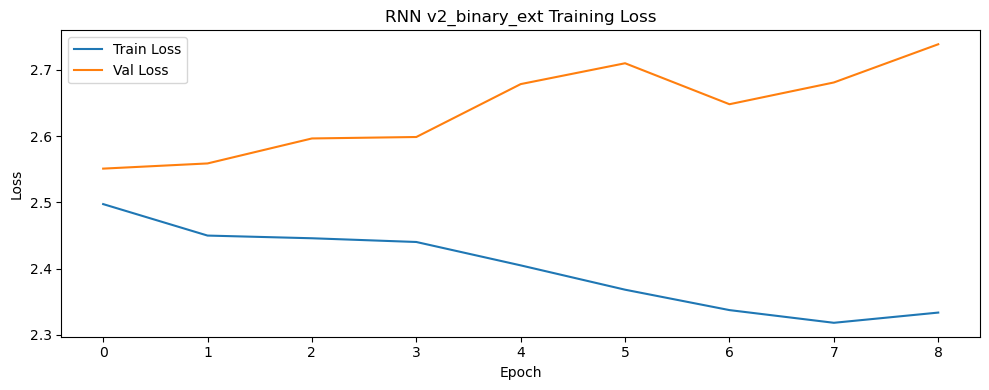

In [ ]:
# v2: deeper binary RNN trained on extended features (x_*_ext)

# labels are already in {0, 1} = {Down, Up} from split
y_train_rnn_v2 = y_train_ext
y_val_rnn_v2 = y_val_ext

# train-only normalization
train_mean_v2 = x_train_ext.mean(axis=(0, 1), keepdims=True)
train_std_v2 = x_train_ext.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_rnn_v2 = (x_train_ext - train_mean_v2) / train_std_v2
x_val_rnn_v2 = (x_val_ext - train_mean_v2) / train_std_v2

num_classes_v2 = 2
input_shape_v2 = x_train_rnn_v2.shape[1:]

keras.backend.clear_session()

rnn_model_v2 = keras.Sequential([
    layers.Input(shape=input_shape_v2),
    layers.SimpleRNN(128, activation="tanh", return_sequences=True),
    layers.Dropout(0.25),
    layers.SimpleRNN(64, activation="tanh"),
    layers.Dropout(0.25),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes_v2, activation="softmax"),
])

# Binary cost matrix: rows=true [Down, Up], cols=pred [Down, Up]
loss_matrix_v2 = np.array([
    [0.0, 3.0],
    [3.0, 0.0],
], dtype=np.float32)
loss_matrix_tf_v2 = tf.constant(loss_matrix_v2, dtype=tf.float32)

def matrix_weighted_loss_v2(y_true, y_pred):
    ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    y_true = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes_v2)
    cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_v2)
    expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
    lambda_cost_v2 = 1.2
    return ce + lambda_cost_v2 * expected_cost

rnn_model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=matrix_weighted_loss_v2,
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v2)],
)

callbacks_v2 = [
    keras.callbacks.EarlyStopping(monitor="val_macro_f1", mode="max", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_macro_f1", mode="max", factor=0.5, patience=3, min_lr=1e-5),
]

history_v2 = rnn_model_v2.fit(
    x_train_rnn_v2,
    y_train_rnn_v2,
    validation_data=(x_val_rnn_v2, y_val_rnn_v2),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_v2,
    verbose=1,
)

# direct validation evaluation helper
rnn_results_v2 = evaluate_keras_model_on_validation(
    model=rnn_model_v2,
    history=history_v2,
    x_val=x_val_rnn_v2,
    y_val_cat=y_val_rnn_v2,
    prefix="v2_binary_ext",
    class_names=("Down", "Up"),
    raw_return=val_raw_return_ext,
    benchmark_name="AAPL buy-and-hold",
)


I mean, at least the model start to make some judgement, which means that this may really helpful. Though the this model still try to guess everything as up, at lease make some try already.

x_train_ext shape: (1721, 252, 21)
y_train_ext shape: (1721,)
x_val_ext shape: (596, 252, 21)
y_val_ext shape: (596,)
x_test_ext shape: (597, 252, 21)
y_test_ext shape: (597,)
train label counts [Down, Up]: [792 929]
val label counts [Down, Up]: [297 299]
test label counts [Down, Up]: [294 303]
val raw return shape: (596,) val index shape: (596,)
test raw return shape: (597,) test index shape: (597,)
Epoch 1/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 2.4809 - macro_f1: 0.4965 - val_loss: 2.5605 - val_macro_f1: 0.3745 - learning_rate: 7.0000e-04
Epoch 2/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 2.4414 - macro_f1: 0.5020 - val_loss: 2.5114 - val_macro_f1: 0.4342 - learning_rate: 7.0000e-04
Epoch 3/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 2.4346 - macro_f1: 0.5397 - val_loss: 2.6231 - val_macro_f1: 0.3652 - learning_rate: 7.0000e-04
Epoch 4/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 2.4169 - macro_f1: 0.5106 - val_loss: 2.6037 - val_macro_f1: 0.4072 - le

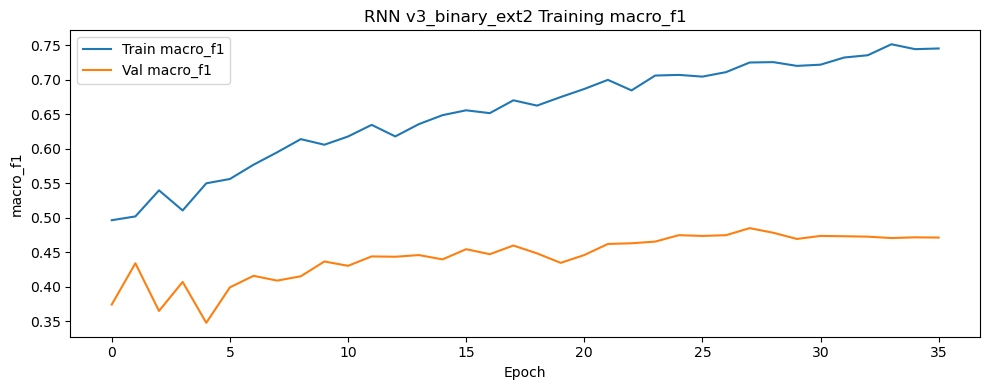

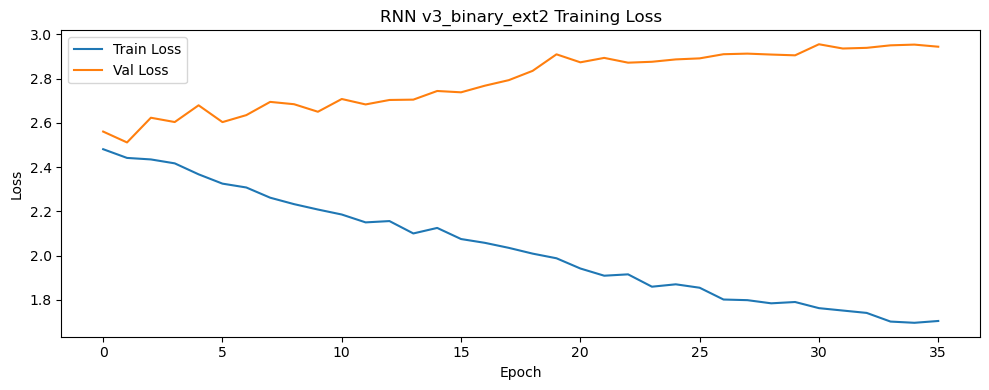

In [ ]:
# v3: keep the same binary model architecture and training setup as v2,
# but use add_transformed_features=2, which keeps only transformed technical features and drops raw OHLCV columns.
(
    x_train_ext, y_train_ext, x_val_ext, y_val_ext, x_test_ext, y_test_ext,
    idx_train_ext_v3, idx_val_ext_v3, idx_test_ext_v3,
    train_raw_return_ext_v3, val_raw_return_ext_v3, test_raw_return_ext_v3,
) = single_stock_split(
    AAPL_data,
    AAPLReturn,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
    window_size=252,
    add_transformed_features=2,
    target_mode="direction_binary",
    return_index=True,
    return_raw_target=True,
)

print("x_train_ext shape:", x_train_ext.shape)
print("y_train_ext shape:", y_train_ext.shape)
print("x_val_ext shape:", x_val_ext.shape) 
print("y_val_ext shape:", y_val_ext.shape)
print("x_test_ext shape:", x_test_ext.shape)
print("y_test_ext shape:", y_test_ext.shape)
print("train label counts [Down, Up]:", np.bincount(y_train_ext, minlength=2))
print("val label counts [Down, Up]:", np.bincount(y_val_ext, minlength=2))
print("test label counts [Down, Up]:", np.bincount(y_test_ext, minlength=2))
print("val raw return shape:", val_raw_return_ext_v3.shape, "val index shape:", idx_val_ext_v3.shape)
print("test raw return shape:", test_raw_return_ext_v3.shape, "test index shape:", idx_test_ext_v3.shape)

# labels are already in {0, 1} = {Down, Up} from split
y_train_rnn_v3 = y_train_ext
y_val_rnn_v3 = y_val_ext

# train-only normalization
train_mean_v3 = x_train_ext.mean(axis=(0, 1), keepdims=True)
train_std_v3 = x_train_ext.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_rnn_v3 = (x_train_ext - train_mean_v3) / train_std_v3
x_val_rnn_v3 = (x_val_ext - train_mean_v3) / train_std_v3

num_classes_v3 = 2
input_shape_v3 = x_train_rnn_v3.shape[1:]

keras.backend.clear_session()

rnn_model_v3 = keras.Sequential([
    layers.Input(shape=input_shape_v3),
    layers.SimpleRNN(128, activation="tanh", return_sequences=True),
    layers.Dropout(0.25),
    layers.SimpleRNN(64, activation="tanh"),
    layers.Dropout(0.25),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes_v3, activation="softmax"),
])

# Binary cost matrix: rows=true [Down, Up], cols=pred [Down, Up]
loss_matrix_v3 = np.array([
    [0.0, 3.0],
    [3.0, 0.0],
], dtype=np.float32)
loss_matrix_tf_v3 = tf.constant(loss_matrix_v3, dtype=tf.float32)

def matrix_weighted_loss_v3(y_true, y_pred):
    ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    y_true = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes_v3)
    cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_v3)
    expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
    lambda_cost_v3 = 1.2
    return ce + lambda_cost_v3 * expected_cost

rnn_model_v3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=matrix_weighted_loss_v3,
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v3)],
)

callbacks_v3 = [
    keras.callbacks.EarlyStopping(monitor="val_macro_f1", mode="max", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_macro_f1", mode="max", factor=0.5, patience=3, min_lr=1e-5),
]

history_v3 = rnn_model_v3.fit(
    x_train_rnn_v3,
    y_train_rnn_v3,
    validation_data=(x_val_rnn_v3, y_val_rnn_v3),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_v3,
    verbose=1,
)

# direct validation evaluation helper
rnn_results_v3 = evaluate_keras_model_on_validation(
    model=rnn_model_v3,
    history=history_v3,
    x_val=x_val_rnn_v3,
    y_val_cat=y_val_rnn_v3,
    prefix="v3_binary_ext2",
    class_names=("Down", "Up"),
    raw_return=val_raw_return_ext_v3,
    benchmark_name="AAPL buy-and-hold",
)


Though overfiting, but the but the f1-results seems improved, so is excess return. So dropping the original data and just use the transfered one could be a good idea.

#### Just some trys, adding all the data together

In [ ]:
from functools import reduce

# Now lets adding for information inside, let the model sturggele in higher demension ;)

# naive process, directly adding all feature in other stock

# Read all other stock files and merge them into one wide table on Dt
other_stock_paths = sorted((DATA_DIR).glob('*.csv'))
other_stock_paths = [p for p in other_stock_paths if p.stem != 'AAPL']

other_stock_tables = []
for stock_path in other_stock_paths:
    stock_name = stock_path.stem
    stock_df = pd.read_csv(stock_path)
    stock_df['Dt'] = pd.to_datetime(stock_df['Dt'])
    stock_df = stock_df.sort_values('Dt').drop_duplicates(subset='Dt')
    stock_df = stock_df.rename(columns={col: f'{stock_name}_{col}' for col in stock_df.columns if col != 'Dt'})
    other_stock_tables.append(stock_df)

other_stocks_big_table = reduce(lambda left, right: pd.merge(left, right, on='Dt', how='inner'), other_stock_tables)
other_stocks_big_table.set_index('Dt', inplace=True)

print('other_stocks_big_table shape:', other_stocks_big_table.shape)
other_stocks_big_table.head()

other_stocks_big_table shape: (4277, 184)


,ACN_Adj Close,ACN_Close,ACN_Div,ACN_Factor,ACN_High,ACN_Low,ACN_Open,ACN_Volume,ADBE_Adj Close,ADBE_Close,...,XLV_Open,XLV_Volume,XLY_Adj Close,XLY_Close,XLY_Div,XLY_Factor,XLY_High,XLY_Low,XLY_Open,XLY_Volume
Dt,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.2747,65.563,...,31.000,246700.0,23.6030,30.125,0.0,1.0,31.0000,29.8590,31.000,212900.0
2000-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.9094,60.063,...,30.188,35300.0,22.8930,29.219,0.0,1.0,29.8130,29.0310,29.688,177200.0
2000-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.2042,61.250,...,29.781,137600.0,22.6114,28.859,0.0,1.0,29.3461,28.7190,29.344,124600.0
2000-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.3283,61.750,...,29.313,50000.0,22.8685,29.188,0.0,1.0,29.4060,28.9991,29.047,135800.0
2000-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0730,64.750,...,29.469,22100.0,23.9458,30.563,0.0,1.0,30.5630,29.5000,29.500,70000.0


In [ ]:
# get this big table into the same format as x_train, x_val, x_test, and then we can concatenate it with the original features for AAPL to train the model
# Binary setup: train removes flat days using the 3-class threshold first; validation/test use 0 as the Down/Up boundary.
(
    x_train_multi_all, y_train_multi_all,
    x_val_multi_all, y_val_multi_all,
    x_test_multi_all, y_test_multi_all,
    idx_train_multi_all, idx_val_multi_all, idx_test_multi_all,
    train_raw_return_multi_all, val_raw_return_multi_all, test_raw_return_multi_all,
) = multi_stock_split(
    AAPL_data,
    AAPLReturn,
    other_stocks_big_table,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
    window_size=252,
    add_transformed_features=1,
    target_mode="direction_binary",
    return_index=True,
    return_raw_target=True,
)

print("x_train_multi_all shape:", x_train_multi_all.shape)
print("y_train_multi_all shape:", y_train_multi_all.shape)
print("x_val_multi_all shape:", x_val_multi_all.shape)
print("y_val_multi_all shape:", y_val_multi_all.shape)
print("x_test_multi_all shape:", x_test_multi_all.shape)
print("y_test_multi_all shape:", y_test_multi_all.shape)
print("train label counts [Down, Up]:", np.bincount(y_train_multi_all, minlength=2))
print("val label counts [Down, Up]:", np.bincount(y_val_multi_all, minlength=2))
print("test label counts [Down, Up]:", np.bincount(y_test_multi_all, minlength=2))
print("val raw return shape:", val_raw_return_multi_all.shape)
print("val date range:", idx_val_multi_all[0], "to", idx_val_multi_all[-1])


x_train_multi_all shape: (10, 252, 213)
y_train_multi_all shape: (10,)
x_val_multi_all shape: (8, 252, 213)
y_val_multi_all shape: (8,)
x_test_multi_all shape: (10, 252, 213)
y_test_multi_all shape: (10,)
train label counts [Down, Up]: [5 5]
val label counts [Down, Up]: [2 6]
test label counts [Down, Up]: [4 6]
val raw return shape: (8,)
val date range: 2016-12-06T00:00:00.000000 to 2016-12-15T00:00:00.000000


In [ ]:

# I can't directly use the merged data, as the missing data in the other stock will cause the number of samples to drop significantly, so I need to do some imputation for the missing data, and then train the model on the imputed data.
# So I have to check the the missing data first

start_dates = []

stock_names = sorted({col.split('_', 1)[0] for col in other_stocks_big_table.columns if '_' in col})

for stock in stock_names:
    stock_cols = [c for c in other_stocks_big_table.columns if c.startswith(f"{stock}_")]
    has_data = other_stocks_big_table[stock_cols].notna().any(axis=1)
    first_date = has_data[has_data].index.min() if has_data.any() else pd.NaT
    start_dates.append((stock, first_date, len(stock_cols)))

start_dates_df = pd.DataFrame(start_dates, columns=["Stock", "FirstAvailableDate", "NumFeatures"]).sort_values("FirstAvailableDate")
print(start_dates_df.to_string(index=False))

Stock FirstAvailableDate  NumFeatures
  SPY         2000-01-03            8
  XLU         2000-01-03            8
  XLP         2000-01-03            8
  XLK         2000-01-03            8
  XLI         2000-01-03            8
  XLF         2000-01-03            8
  XLE         2000-01-03            8
  XLB         2000-01-03            8
  XLV         2000-01-03            8
 NVDA         2000-01-03            8
  XLY         2000-01-03            8
 INTC         2000-01-03            8
  IBM         2000-01-03            8
 CSCO         2000-01-03            8
 ADBE         2000-01-03            8
 MSFT         2000-01-03            8
  ACN         2001-07-19            8
  CRM         2004-06-23            8
 GOOG         2004-08-19            8
   MA         2006-05-25            8
    V         2008-03-19            8
   FB         2012-05-18            8
 XLRE         2015-10-08            8


In [ ]:
# so as long as I delete  MA/V/FB/XLRE then the time is fine
deleted_stocks = {'MA', 'V', 'FB', 'XLRE'}

# only drop columns whose stock prefix is exactly in deleted_stocks
cols_to_drop = [
    col for col in other_stocks_big_table.columns
    if col.split('_', 1)[0] in deleted_stocks
]

other_stocks_big_table_dropped = other_stocks_big_table.drop(columns=cols_to_drop)

print("dropped columns:", len(cols_to_drop))
print("other_stocks_big_table_dropped shape:", other_stocks_big_table_dropped.shape)
other_stocks_big_table_dropped.head()

dropped columns: 32
other_stocks_big_table_dropped shape: (4277, 152)


,ACN_Adj Close,ACN_Close,ACN_Div,ACN_Factor,ACN_High,ACN_Low,ACN_Open,ACN_Volume,ADBE_Adj Close,ADBE_Close,...,XLV_Open,XLV_Volume,XLY_Adj Close,XLY_Close,XLY_Div,XLY_Factor,XLY_High,XLY_Low,XLY_Open,XLY_Volume
Dt,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.2747,65.563,...,31.000,246700.0,23.6030,30.125,0.0,1.0,31.0000,29.8590,31.000,212900.0
2000-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.9094,60.063,...,30.188,35300.0,22.8930,29.219,0.0,1.0,29.8130,29.0310,29.688,177200.0
2000-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.2042,61.250,...,29.781,137600.0,22.6114,28.859,0.0,1.0,29.3461,28.7190,29.344,124600.0
2000-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.3283,61.750,...,29.313,50000.0,22.8685,29.188,0.0,1.0,29.4060,28.9991,29.047,135800.0
2000-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0730,64.750,...,29.469,22100.0,23.9458,30.563,0.0,1.0,30.5630,29.5000,29.500,70000.0


In [ ]:
# Same binary target setup, using the dropped multi-stock table.
(
    x_train_multi_dropped, y_train_multi_dropped,
    x_val_multi_dropped, y_val_multi_dropped,
    x_test_multi_dropped, y_test_multi_dropped,
    idx_train_multi_dropped, idx_val_multi_dropped, idx_test_multi_dropped,
    train_raw_return_multi_dropped, val_raw_return_multi_dropped, test_raw_return_multi_dropped,
) = multi_stock_split(
    AAPL_data,
    AAPLReturn,
    other_stocks_big_table_dropped,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
    window_size=252,
    add_transformed_features=1,
    target_mode="direction_binary",
    return_index=True,
    return_raw_target=True,
)

print("x_train_multi_dropped shape:", x_train_multi_dropped.shape)
print("y_train_multi_dropped shape:", y_train_multi_dropped.shape)
print("x_val_multi_dropped shape:", x_val_multi_dropped.shape)
print("y_val_multi_dropped shape:", y_val_multi_dropped.shape)
print("x_test_multi_dropped shape:", x_test_multi_dropped.shape)
print("y_test_multi_dropped shape:", y_test_multi_dropped.shape)
print("train label counts [Down, Up]:", np.bincount(y_train_multi_dropped, minlength=2))
print("val label counts [Down, Up]:", np.bincount(y_val_multi_dropped, minlength=2))
print("test label counts [Down, Up]:", np.bincount(y_test_multi_dropped, minlength=2))
print("val raw return shape:", val_raw_return_multi_dropped.shape)
print("val date range:", idx_val_multi_dropped[0], "to", idx_val_multi_dropped[-1])


x_train_multi_dropped shape: (1155, 252, 181)
y_train_multi_dropped shape: (1155,)
x_val_multi_dropped shape: (429, 252, 181)
y_val_multi_dropped shape: (429,)
x_test_multi_dropped shape: (430, 252, 181)
y_test_multi_dropped shape: (430,)
train label counts [Down, Up]: [521 634]
val label counts [Down, Up]: [196 233]
test label counts [Down, Up]: [219 211]
val raw return shape: (429,)
val date range: 2013-08-06T00:00:00.000000 to 2015-04-20T00:00:00.000000


Epoch 1/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 2.5413 - macro_f1: 0.4553 - val_loss: 2.4652 - val_macro_f1: 0.3611 - learning_rate: 7.0000e-04
Epoch 2/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 2.4643 - macro_f1: 0.4534 - val_loss: 2.4720 - val_macro_f1: 0.4725 - learning_rate: 7.0000e-04
Epoch 3/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 2.4449 - macro_f1: 0.4967 - val_loss: 2.4515 - val_macro_f1: 0.3510 - learning_rate: 7.0000e-04
Epoch 4/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 2.4194 - macro_f1: 0.4748 - val_loss: 2.4509 - val_macro_f1: 0.3556 - learning_rate: 7.0000e-04
Epoch 5/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 2.3739 - macro_f1: 0.5113 - val_loss: 2.4592 - val_macro_f1: 0.3973 - learning_rate: 7.0000e-04
Epoch 6/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 2.3621 - macro_f1: 0.5279 - val_loss: 2.4572 - val_macro_f1: 0.3762 - learning_rate: 3.5000e-04
Epoch 7/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 2.3286 - ma

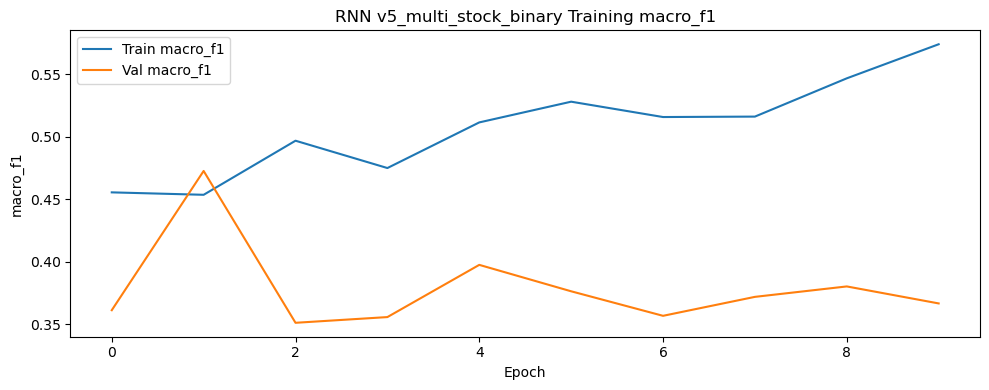

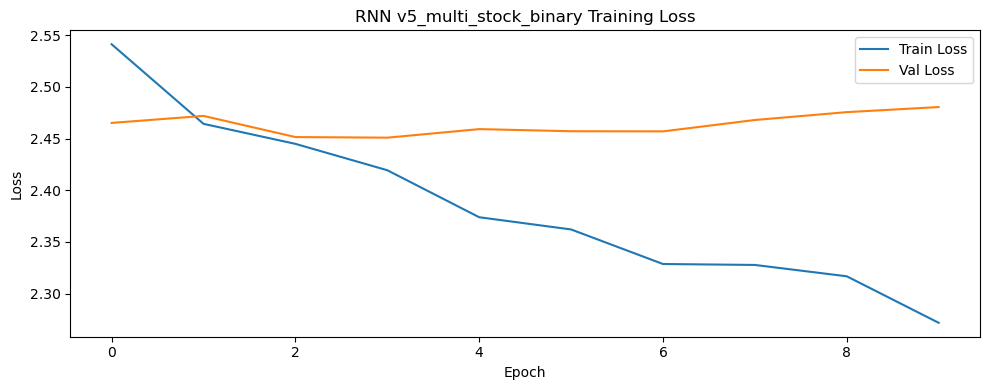

In [ ]:
# now still use RNN but see with more feature inside if there is magic

# v5: RNN on multi-stock features with the binary target setup

# Use the dropped multi-stock table split explicitly, so the benchmark return cannot be overwritten by another split cell.
x_train = x_train_multi_dropped
y_train = y_train_multi_dropped
x_val = x_val_multi_dropped
y_val = y_val_multi_dropped
x_test = x_test_multi_dropped
y_test = y_test_multi_dropped

# labels are already in {0, 1} = {Down, Up}
y_train_rnn_v5 = y_train
y_val_rnn_v5 = y_val
y_test_rnn_v5 = y_test

# train-only normalization
train_mean_v5 = x_train.mean(axis=(0, 1), keepdims=True)
train_std_v5 = x_train.std(axis=(0, 1), keepdims=True) + 1e-8

x_train_rnn_v5 = (x_train - train_mean_v5) / train_std_v5
x_val_rnn_v5 = (x_val - train_mean_v5) / train_std_v5
x_test_rnn_v5 = (x_test - train_mean_v5) / train_std_v5

num_classes_v5 = 2
input_shape_v5 = x_train_rnn_v5.shape[1:]

keras.backend.clear_session()

rnn_model_v5 = keras.Sequential([
    layers.Input(shape=input_shape_v5),
    layers.SimpleRNN(128, activation="tanh", return_sequences=True),
    layers.Dropout(0.25),
    layers.SimpleRNN(64, activation="tanh"),
    layers.Dropout(0.25),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes_v5, activation="softmax"),
])

# binary cost-sensitive loss: penalize predicting the opposite direction
loss_matrix_v5 = np.array([
    [0.0, 3.0],  # true Down, predicted Up
    [3.0, 0.0],  # true Up, predicted Down
], dtype=np.float32)
loss_matrix_tf_v5 = tf.constant(loss_matrix_v5, dtype=tf.float32)

def matrix_weighted_loss_v5(y_true, y_pred):
    ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    y_true = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes_v5)
    cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_v5)
    expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
    lambda_cost_v5 = 1.2
    return ce + lambda_cost_v5 * expected_cost

rnn_model_v5.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=matrix_weighted_loss_v5,
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v5)],
)

callbacks_v5 = [
    keras.callbacks.EarlyStopping(monitor="val_macro_f1", mode="max", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_macro_f1", mode="max", factor=0.5, patience=3, min_lr=1e-5),
]

history_v5 = rnn_model_v5.fit(
    x_train_rnn_v5,
    y_train_rnn_v5,
    validation_data=(x_val_rnn_v5, y_val_rnn_v5),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_v5,
    verbose=1,
)

# validation evaluation
rnn_results_v5 = evaluate_keras_model_on_validation(
    model=rnn_model_v5,
    history=history_v5,
    x_val=x_val_rnn_v5,
    y_val_cat=y_val_rnn_v5,
    prefix="v5_multi_stock_binary",
    class_names=("Down", "Up"),
    raw_return=val_raw_return_multi_dropped,
    benchmark_name="AAPL buy-and-hold",
)


#### Adding the other stocks information even the original one indeed improve the performance. So now let's start adding the feaures

### Previous multi-stock result (obsolete after binary target switch)

The old `v5_multi_stock` result below was from the 3-class setup. After switching the multi-stock model to the binary setup, rerun the v5 cell and use the new `v5_multi_stock_binary` macro F1 plus validation trading/excess-return output.


In [ ]:
# since we want to transfer the data, we need to understand the data.
# the indicator of the market: SPY
# start from add_technical_features output, then remove AAPL raw OHLCV/corporate-action columns.

AAPL_data_expand = add_technical_features(AAPL_data)
AAPL_raw_cols = [col for col in AAPL_data.columns if col in AAPL_data_expand.columns]
AAPL_data_expand = AAPL_data_expand.drop(columns=AAPL_raw_cols)

print("Dropped AAPL raw columns:", AAPL_raw_cols)
print("AAPL technical-only shape:", AAPL_data_expand.shape)
AAPL_data_expand.head(20)


Dropped AAPL raw columns: ['Adj Close', 'Close', 'Div', 'Factor', 'High', 'Low', 'Open', 'Volume']
AAPL technical-only shape: (4277, 21)


,ret_1d,ret_ma_5,ret_ma_20,ret_ma_50,macd,macd_signal,macd_hist,volatility_20,bb_mid,bb_upper,...,bb_width,rsi_14,sar,cci_20,strat_ar,strat_br,volume_z_20,pvi,ret_sign,ret_streak
Dt,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,...,NaN,NaN,101.688000,NaN,NaN,NaN,NaN,1000.000000,NaN,0.0
2000-01-04,-0.084318,NaN,NaN,NaN,-0.023397,-0.004679,-0.018718,NaN,NaN,NaN,...,NaN,NaN,112.500000,NaN,NaN,NaN,NaN,1000.000000,-1.0,-1.0
2000-01-05,0.014630,NaN,NaN,NaN,-0.037744,-0.011292,-0.026452,NaN,NaN,NaN,...,NaN,NaN,112.500000,NaN,NaN,NaN,NaN,1014.630165,1.0,1.0
2000-01-06,-0.086546,NaN,NaN,NaN,-0.070867,-0.023207,-0.047660,NaN,NaN,NaN,...,NaN,NaN,112.273760,NaN,NaN,NaN,NaN,1014.630165,-1.0,-1.0
2000-01-07,0.047390,NaN,NaN,NaN,-0.084850,-0.035536,-0.049314,NaN,NaN,NaN,...,NaN,NaN,111.582810,NaN,NaN,NaN,NaN,1014.630165,1.0,1.0
2000-01-10,-0.017594,-0.025288,NaN,NaN,-0.099178,-0.048264,-0.050914,NaN,NaN,NaN,...,NaN,NaN,110.919497,NaN,NaN,NaN,NaN,996.778974,-1.0,-1.0
2000-01-11,-0.051159,-0.018656,NaN,NaN,-0.121670,-0.062946,-0.058725,NaN,NaN,NaN,...,NaN,NaN,109.949327,NaN,NaN,NaN,NaN,996.778974,-1.0,-2.0
2000-01-12,-0.059954,-0.033573,NaN,NaN,-0.151690,-0.080694,-0.070996,NaN,NaN,NaN,...,NaN,NaN,108.393381,NaN,NaN,NaN,NaN,937.017886,-1.0,-3.0
2000-01-13,0.109655,0.005668,NaN,NaN,-0.149781,-0.094512,-0.055269,NaN,NaN,NaN,...,NaN,NaN,106.204043,NaN,NaN,NaN,NaN,1039.766840,1.0,1.0


In [ ]:
# Build market-related feature blocks separately, then append them once.
# This keeps the AAPL technical-feature base clean and makes each added block easier to inspect.

market_feature_prefixes = ("alpha_", "beta_", "spy_", "aapl_excess_")
aapl_base_cols = [
    col for col in AAPL_data_expand.columns
    if not col.startswith(market_feature_prefixes)
]
aapl_base_features = AAPL_data_expand.loc[:, aapl_base_cols].copy()

alpha_beta_30 = add_rolling_alpha_beta_from_ret1d(
    stock_features_df=aapl_base_features,
    market_data=DATA_DIR / "SPY.csv",
    rolling_window=30,
)[["alpha_30", "beta_30"]]

alpha_beta_60 = add_rolling_alpha_beta_from_ret1d(
    stock_features_df=aapl_base_features,
    market_data=DATA_DIR / "SPY.csv",
    rolling_window=60,
)[["alpha_60", "beta_60"]]

alpha_beta_features = pd.concat([alpha_beta_30, alpha_beta_60], axis=1)
alpha_beta_features["alpha_60minus_30"] = alpha_beta_features["alpha_60"] - alpha_beta_features["alpha_30"]
alpha_beta_features["beta_60minus_30"] = alpha_beta_features["beta_60"] - alpha_beta_features["beta_30"]

SPY_raw = pd.read_csv(DATA_DIR / "SPY.csv")
SPY_raw["Dt"] = pd.to_datetime(SPY_raw["Dt"], format="%Y-%m-%d", errors="coerce")
SPY_raw = SPY_raw.dropna(subset=["Dt"]).sort_values("Dt").drop_duplicates(subset="Dt").set_index("Dt")

spy_features = build_market_features(SPY_raw).reindex(aapl_base_features.index)

excess_features = pd.DataFrame(index=aapl_base_features.index)
excess_features["aapl_excess_ret_1d"] = aapl_base_features["ret_1d"] - spy_features["spy_ret_1d"]
excess_features["aapl_excess_ret_ma_5"] = aapl_base_features["ret_ma_5"] - spy_features["spy_ret_ma_5"]
excess_features["aapl_excess_ret_ma_20"] = aapl_base_features["ret_ma_20"] - spy_features["spy_ret_ma_20"]

new_market_features = pd.concat(
    [alpha_beta_features, spy_features, excess_features],
    axis=1,
)
new_market_features = new_market_features.loc[:, ~new_market_features.columns.duplicated()]

AAPL_data_expand = pd.concat([aapl_base_features, new_market_features], axis=1)
AAPL_data_expand = AAPL_data_expand.loc[:, ~AAPL_data_expand.columns.duplicated()]

print("AAPL base feature shape:", aapl_base_features.shape)
print("alpha/beta feature shape:", alpha_beta_features.shape)
print("SPY feature shape:", spy_features.shape)
print("excess-return feature shape:", excess_features.shape)
print("AAPL_data_expand final shape:", AAPL_data_expand.shape)
print("Added columns:", new_market_features.columns.tolist())

AAPL_data_expand.head(50)


AAPL base feature shape: (4277, 21)
alpha/beta feature shape: (4277, 6)
SPY feature shape: (4277, 13)
excess-return feature shape: (4277, 3)
AAPL_data_expand final shape: (4277, 43)
Added columns: ['alpha_30', 'beta_30', 'alpha_60', 'beta_60', 'alpha_60minus_30', 'beta_60minus_30', 'spy_ret_1d', 'spy_ret_ma_5', 'spy_ret_ma_20', 'spy_ret_ma_50', 'spy_volatility_20', 'spy_macd', 'spy_macd_signal', 'spy_macd_hist', 'spy_bb_width', 'spy_rsi_14', 'spy_volume_z_20', 'spy_ret_sign', 'spy_ret_streak', 'aapl_excess_ret_1d', 'aapl_excess_ret_ma_5', 'aapl_excess_ret_ma_20']


,ret_1d,ret_ma_5,ret_ma_20,ret_ma_50,macd,macd_signal,macd_hist,volatility_20,bb_mid,bb_upper,...,spy_macd_signal,spy_macd_hist,spy_bb_width,spy_rsi_14,spy_volume_z_20,spy_ret_sign,spy_ret_streak,aapl_excess_ret_1d,aapl_excess_ret_ma_5,aapl_excess_ret_ma_20
Dt,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,...,0.000000,0.000000,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2000-01-04,-0.084318,NaN,NaN,NaN,-0.023397,-0.004679,-0.018718,NaN,NaN,NaN,...,-0.062685,-0.250740,NaN,NaN,NaN,-1.0,-1.0,-0.045212,NaN,NaN
2000-01-05,0.014630,NaN,NaN,NaN,-0.037744,-0.011292,-0.026452,NaN,NaN,NaN,...,-0.158475,-0.383161,NaN,NaN,NaN,1.0,1.0,0.012841,NaN,NaN
2000-01-06,-0.086546,NaN,NaN,NaN,-0.070867,-0.023207,-0.047660,NaN,NaN,NaN,...,-0.294431,-0.543822,NaN,NaN,NaN,-1.0,-1.0,-0.070475,NaN,NaN
2000-01-07,0.047390,NaN,NaN,NaN,-0.084850,-0.035536,-0.049314,NaN,NaN,NaN,...,-0.359591,-0.260640,NaN,NaN,NaN,1.0,1.0,-0.010686,NaN,NaN
2000-01-10,-0.017594,-0.025288,NaN,NaN,-0.099178,-0.048264,-0.050914,NaN,NaN,NaN,...,-0.370631,-0.044163,NaN,NaN,NaN,1.0,2.0,-0.021024,-0.026911,NaN
2000-01-11,-0.051159,-0.018656,NaN,NaN,-0.121670,-0.062946,-0.058725,NaN,NaN,NaN,...,-0.365615,0.020065,NaN,NaN,NaN,-1.0,-1.0,-0.039193,-0.025707,NaN
2000-01-12,-0.059954,-0.033573,NaN,NaN,-0.151690,-0.080694,-0.070996,NaN,NaN,NaN,...,-0.365808,-0.000773,NaN,NaN,NaN,-1.0,-2.0,-0.050006,-0.038277,NaN
2000-01-13,0.109655,0.005668,NaN,NaN,-0.149781,-0.094512,-0.055269,NaN,NaN,NaN,...,-0.347068,0.074961,NaN,NaN,NaN,1.0,1.0,0.096112,-0.004959,NaN


x_train_exp shape: (1713, 252, 43)
y_train_exp shape: (1713,)
x_val_exp shape: (594, 252, 43)
y_val_exp shape: (594,)
x_test_exp shape: (596, 252, 43)
y_test_exp shape: (596,)
train label counts [Down, Up]: [789 924]
val label counts [Down, Up]: [296 298]
test label counts [Down, Up]: [294 302]
val raw return shape: (594,) val index shape: (594,)
Epoch 1/60


2026-04-28 20:02:10.475363: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 2.5557 - macro_f1: 0.4815 - val_loss: 2.5808 - val_macro_f1: 0.3341 - learning_rate: 7.0000e-04
Epoch 2/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 2.4382 - macro_f1: 0.4877 - val_loss: 2.5206 - val_macro_f1: 0.4108 - learning_rate: 7.0000e-04
Epoch 3/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 2.4242 - macro_f1: 0.5246 - val_loss: 2.5570 - val_macro_f1: 0.3653 - learning_rate: 7.0000e-04
Epoch 4/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 2.3381 - macro_f1: 0.5685 - val_loss: 2.5472 - val_macro_f1: 0.4178 - learning_rate: 7.0000e-04
Epoch 5/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 2.3048 - macro_f1: 0.5927 - val_loss: 2.5931 - val_macro_f1: 0.3538 - learning_rate: 7.0000e-04
Epoch 6/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 2.2519 - macro_f1: 0.5975 - val_loss: 2.5618 - val_macro_f1: 0.4066 - learning_rate: 7.0000e-04
Epoch 7/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 2.2144 - macro_f1: 0.6

2026-04-28 20:03:08.442876: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[v6_expanded_binary] Validation macro_f1: 0.5080
[v6_expanded_binary] Validation loss: 2.5767

[v6_expanded_binary] Validation classification report:
              precision    recall  f1-score   support

        Down       0.56      0.30      0.39       296
          Up       0.53      0.77      0.62       298

    accuracy                           0.54       594
   macro avg       0.54      0.53      0.51       594
weighted avg       0.54      0.54      0.51       594


[v6_expanded_binary] Validation confusion matrix:
[[ 89 207]
 [ 69 229]]

[v6_expanded_binary] Validation trading performance:
[v6_expanded_binary] Strategy average return: 0.133006%
[v6_expanded_binary] AAPL buy-and-hold average return: 0.042816%
[v6_expanded_binary] Excess average return: 0.090190%
[v6_expanded_binary] Strategy annualized arithmetic return: 33.5175%
[v6_expanded_binary] AAPL buy-and-hold annualized arithmetic return: 10.7895%
[v6_expanded_binary] Excess annualized arithmetic return: 22.7279%


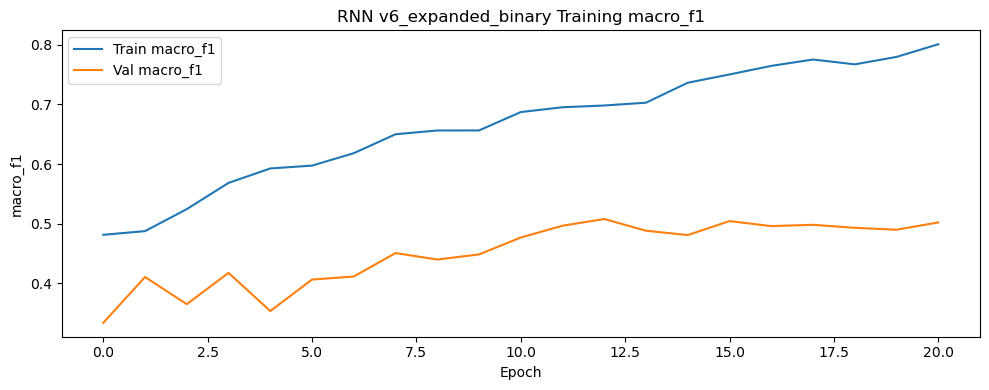

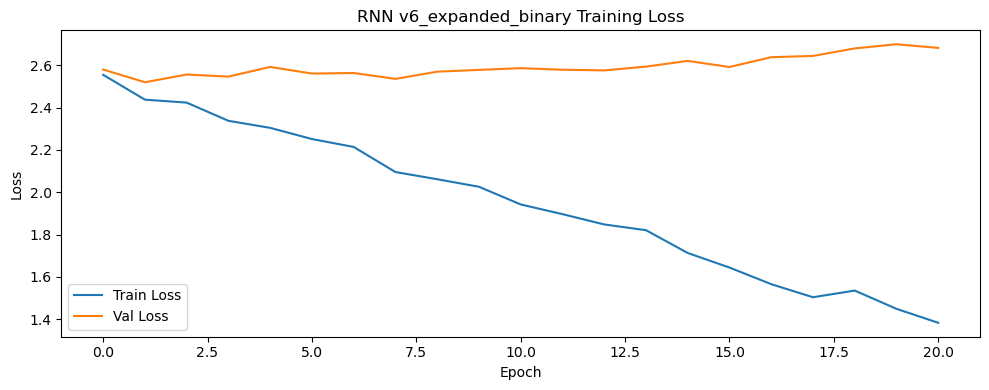

In [ ]:
# Adding these seems meaningful information, let's see if it helps
# Binary setup: train removes flat days using the 3-class threshold first; validation/test use 0 as the Down/Up boundary.
(
    x_train_exp, y_train_exp,
    x_val_exp, y_val_exp,
    x_test_exp, y_test_exp,
    idx_train_exp_v6, idx_val_exp_v6, idx_test_exp_v6,
    train_raw_return_exp_v6, val_raw_return_exp_v6, test_raw_return_exp_v6,
) = single_stock_split(
    AAPL_data_expand,
    AAPLReturn,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
    window_size=252,
    add_transformed_features=0,
    target_mode="direction_binary",
    return_index=True,
    return_raw_target=True,
)

print("x_train_exp shape:", x_train_exp.shape)
print("y_train_exp shape:", y_train_exp.shape)
print("x_val_exp shape:", x_val_exp.shape)
print("y_val_exp shape:", y_val_exp.shape)
print("x_test_exp shape:", x_test_exp.shape)
print("y_test_exp shape:", y_test_exp.shape)
print("train label counts [Down, Up]:", np.bincount(y_train_exp, minlength=2))
print("val label counts [Down, Up]:", np.bincount(y_val_exp, minlength=2))
print("test label counts [Down, Up]:", np.bincount(y_test_exp, minlength=2))
print("val raw return shape:", val_raw_return_exp_v6.shape, "val index shape:", idx_val_exp_v6.shape)

# v6: RNN on AAPL with expanded features (technical + SPY-related)

# labels are already in {0, 1} = {Down, Up} from split
y_train_rnn_v6 = y_train_exp
y_val_rnn_v6 = y_val_exp
y_test_rnn_v6 = y_test_exp

# train-only normalization
train_mean_v6 = x_train_exp.mean(axis=(0, 1), keepdims=True)
train_std_v6 = x_train_exp.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_rnn_v6 = (x_train_exp - train_mean_v6) / train_std_v6
x_val_rnn_v6 = (x_val_exp - train_mean_v6) / train_std_v6
x_test_rnn_v6 = (x_test_exp - train_mean_v6) / train_std_v6

num_classes_v6 = 2
input_shape_v6 = x_train_rnn_v6.shape[1:]

keras.backend.clear_session()

rnn_model_v6 = keras.Sequential([
    layers.Input(shape=input_shape_v6),
    layers.SimpleRNN(128, activation="tanh", return_sequences=True),
    layers.Dropout(0.25),
    layers.SimpleRNN(64, activation="tanh"),
    layers.Dropout(0.25),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes_v6, activation="softmax"),
])

# binary cost-sensitive loss: penalize predicting the opposite direction
loss_matrix_v6 = np.array([
    [0.0, 3.0],  # true Down, predicted Up
    [3.0, 0.0],  # true Up, predicted Down
], dtype=np.float32)
loss_matrix_tf_v6 = tf.constant(loss_matrix_v6, dtype=tf.float32)

def matrix_weighted_loss_v6(y_true, y_pred):
    ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    y_true = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes_v6)
    cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_v6)
    expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
    lambda_cost_v6 = 1.2
    return ce + lambda_cost_v6 * expected_cost

rnn_model_v6.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=matrix_weighted_loss_v6,
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v6)],
)

callbacks_v6 = [
    keras.callbacks.EarlyStopping(monitor="val_macro_f1", mode="max", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_macro_f1", mode="max", factor=0.5, patience=3, min_lr=1e-5),
]

history_v6 = rnn_model_v6.fit(
    x_train_rnn_v6,
    y_train_rnn_v6,
    validation_data=(x_val_rnn_v6, y_val_rnn_v6),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_v6,
    verbose=1,
)

# direct validation evaluation helper
rnn_results_v6 = evaluate_keras_model_on_validation(
    model=rnn_model_v6,
    history=history_v6,
    x_val=x_val_rnn_v6,
    y_val_cat=y_val_rnn_v6,
    prefix="v6_expanded_binary",
    class_names=("Down", "Up"),
    raw_return=val_raw_return_exp_v6,
    benchmark_name="AAPL buy-and-hold",
)


In [ ]:
# v6 feature ablation: compare whether SPY features and alpha/beta features help.
# Use the same binary RNN architecture and the same common valid dates for every feature set.

v6_feature_sets_raw = {
    "full": pd.concat([aapl_base_features, alpha_beta_features, spy_features, excess_features], axis=1),
    "no_spy_direct": pd.concat([aapl_base_features, alpha_beta_features, excess_features], axis=1),
    "no_alpha_beta": pd.concat([aapl_base_features, spy_features, excess_features], axis=1),
    "aapl_technical_only": aapl_base_features.copy(),
}

# Use the full feature set to define the common usable date range.
v6_full_features = v6_feature_sets_raw["full"].loc[:, ~v6_feature_sets_raw["full"].columns.duplicated()]
v6_common_index = v6_full_features.replace([np.inf, -np.inf], np.nan).dropna().index

v6_feature_sets = {}
for feature_set_name, feature_df in v6_feature_sets_raw.items():
    clean_df = feature_df.loc[:, ~feature_df.columns.duplicated()].reindex(v6_common_index)
    v6_feature_sets[feature_set_name] = clean_df
    print(f"{feature_set_name}: rows={clean_df.shape[0]}, features={clean_df.shape[1]}")


def train_eval_v6_binary_feature_set(feature_set_name, feature_df, seed=42):
    set_global_determinism(seed)

    (
        x_train_cmp, y_train_cmp,
        x_val_cmp, y_val_cmp,
        x_test_cmp, y_test_cmp,
        idx_train_cmp, idx_val_cmp, idx_test_cmp,
        train_raw_return_cmp, val_raw_return_cmp, test_raw_return_cmp,
    ) = single_stock_split(
        feature_df,
        AAPLReturn,
        train_size=0.7,
        val_size=0.15,
        test_size=0.15,
        window_size=252,
        add_transformed_features=0,
        target_mode="direction_binary",
        return_index=True,
        return_raw_target=True,
    )

    train_mean_cmp = x_train_cmp.mean(axis=(0, 1), keepdims=True)
    train_std_cmp = x_train_cmp.std(axis=(0, 1), keepdims=True) + 1e-8
    x_train_rnn_cmp = (x_train_cmp - train_mean_cmp) / train_std_cmp
    x_val_rnn_cmp = (x_val_cmp - train_mean_cmp) / train_std_cmp

    num_classes_cmp = 2
    input_shape_cmp = x_train_rnn_cmp.shape[1:]

    keras.backend.clear_session()
    model_cmp = keras.Sequential([
        layers.Input(shape=input_shape_cmp),
        layers.SimpleRNN(128, activation="tanh", return_sequences=True),
        layers.Dropout(0.25),
        layers.SimpleRNN(64, activation="tanh"),
        layers.Dropout(0.25),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes_cmp, activation="softmax"),
    ])

    loss_matrix_cmp = np.array([
        [0.0, 3.0],
        [3.0, 0.0],
    ], dtype=np.float32)
    loss_matrix_tf_cmp = tf.constant(loss_matrix_cmp, dtype=tf.float32)

    def matrix_weighted_loss_cmp(y_true, y_pred):
        ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        y_true = tf.cast(y_true, tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=num_classes_cmp)
        cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_cmp)
        expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
        return ce + 1.2 * expected_cost

    model_cmp.compile(
        optimizer=keras.optimizers.Adam(learning_rate=7e-4),
        loss=matrix_weighted_loss_cmp,
        metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_cmp)],
    )

    callbacks_cmp = [
        keras.callbacks.EarlyStopping(monitor="val_macro_f1", mode="max", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_macro_f1", mode="max", factor=0.5, patience=3, min_lr=1e-5),
    ]

    history_cmp = model_cmp.fit(
        x_train_rnn_cmp,
        y_train_cmp,
        validation_data=(x_val_rnn_cmp, y_val_cmp),
        epochs=60,
        batch_size=32,
        callbacks=callbacks_cmp,
        verbose=0,
        shuffle=False,
    )

    results_cmp = evaluate_keras_model_on_validation(
        model=model_cmp,
        history=history_cmp,
        x_val=x_val_rnn_cmp,
        y_val_cat=y_val_cmp,
        prefix=f"v6_ablation_{feature_set_name}",
        class_names=("Down", "Up"),
        raw_return=val_raw_return_cmp,
        benchmark_name="AAPL buy-and-hold",
        plot_history=False,
    )

    return {
        "feature_set": feature_set_name,
        "n_features": feature_df.shape[1],
        "train_samples": len(y_train_cmp),
        "val_samples": len(y_val_cmp),
        "val_start": idx_val_cmp[0],
        "val_end": idx_val_cmp[-1],
        "val_macro_f1": results_cmp["val_macro_f1"],
        "strategy_annualized_return": results_cmp["strategy_annualized_return"],
        "benchmark_annualized_return": results_cmp["benchmark_annualized_return"],
        "excess_annualized_return": results_cmp["excess_annualized_return"],
    }


v6_comparison_rows = []
for feature_set_name, feature_df in v6_feature_sets.items():
    print(f"=== Training v6 feature set: {feature_set_name} ===")
    v6_comparison_rows.append(train_eval_v6_binary_feature_set(feature_set_name, feature_df, seed=42))

v6_feature_comparison = pd.DataFrame(v6_comparison_rows)
v6_feature_comparison = v6_feature_comparison.sort_values(
    ["excess_annualized_return", "val_macro_f1"],
    ascending=False,
).reset_index(drop=True)

v6_feature_comparison


full: rows=4216, features=43
no_spy_direct: rows=4216, features=30
no_alpha_beta: rows=4216, features=37
aapl_technical_only: rows=4216, features=21
=== Training v6 feature set: full ===


2026-04-28 20:03:41.611607: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-28 20:04:30.489800: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[v6_ablation_full] Validation macro_f1: 0.4525
[v6_ablation_full] Validation loss: 2.6087

[v6_ablation_full] Validation classification report:
              precision    recall  f1-score   support

        Down       0.51      0.20      0.28       296
          Up       0.50      0.81      0.62       298

    accuracy                           0.51       594
   macro avg       0.51      0.50      0.45       594
weighted avg       0.51      0.51      0.45       594


[v6_ablation_full] Validation confusion matrix:
[[ 58 238]
 [ 56 242]]

[v6_ablation_full] Validation trading performance:
[v6_ablation_full] Strategy average return: 0.042915%
[v6_ablation_full] AAPL buy-and-hold average return: 0.042816%
[v6_ablation_full] Excess average return: 0.000099%
[v6_ablation_full] Strategy annualized arithmetic return: 10.8146%
[v6_ablation_full] AAPL buy-and-hold annualized arithmetic return: 10.7895%
[v6_ablation_full] Excess annualized arithmetic return: 0.0250%
=== Training v6 feature set: 

2026-04-28 20:04:35.744794: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-28 20:05:43.208628: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[v6_ablation_no_spy_direct] Validation macro_f1: 0.4648
[v6_ablation_no_spy_direct] Validation loss: 2.6985

[v6_ablation_no_spy_direct] Validation classification report:
              precision    recall  f1-score   support

        Down       0.50      0.24      0.32       296
          Up       0.50      0.76      0.61       298

    accuracy                           0.50       594
   macro avg       0.50      0.50      0.46       594
weighted avg       0.50      0.50      0.47       594


[v6_ablation_no_spy_direct] Validation confusion matrix:
[[ 71 225]
 [ 71 227]]

[v6_ablation_no_spy_direct] Validation trading performance:
[v6_ablation_no_spy_direct] Strategy average return: 0.042040%
[v6_ablation_no_spy_direct] AAPL buy-and-hold average return: 0.042816%
[v6_ablation_no_spy_direct] Excess average return: -0.000775%
[v6_ablation_no_spy_direct] Strategy annualized arithmetic return: 10.5942%
[v6_ablation_no_spy_direct] AAPL buy-and-hold annualized arithmetic return: 10.7895%
[v

2026-04-28 20:05:48.631398: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-28 20:06:58.735341: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[v6_ablation_no_alpha_beta] Validation macro_f1: 0.5256
[v6_ablation_no_alpha_beta] Validation loss: 3.0742

[v6_ablation_no_alpha_beta] Validation classification report:
              precision    recall  f1-score   support

        Down       0.53      0.48      0.50       296
          Up       0.53      0.58      0.55       298

    accuracy                           0.53       594
   macro avg       0.53      0.53      0.53       594
weighted avg       0.53      0.53      0.53       594


[v6_ablation_no_alpha_beta] Validation confusion matrix:
[[141 155]
 [126 172]]

[v6_ablation_no_alpha_beta] Validation trading performance:
[v6_ablation_no_alpha_beta] Strategy average return: 0.140236%
[v6_ablation_no_alpha_beta] AAPL buy-and-hold average return: 0.042816%
[v6_ablation_no_alpha_beta] Excess average return: 0.097420%
[v6_ablation_no_alpha_beta] Strategy annualized arithmetic return: 35.3394%
[v6_ablation_no_alpha_beta] AAPL buy-and-hold annualized arithmetic return: 10.7895%
[v6

2026-04-28 20:07:03.928385: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-28 20:07:25.158809: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[v6_ablation_aapl_technical_only] Validation macro_f1: 0.3408
[v6_ablation_aapl_technical_only] Validation loss: 2.5532

[v6_ablation_aapl_technical_only] Validation classification report:
              precision    recall  f1-score   support

        Down       0.67      0.01      0.01       296
          Up       0.50      1.00      0.67       298

    accuracy                           0.50       594
   macro avg       0.58      0.50      0.34       594
weighted avg       0.58      0.50      0.34       594


[v6_ablation_aapl_technical_only] Validation confusion matrix:
[[  2 294]
 [  1 297]]

[v6_ablation_aapl_technical_only] Validation trading performance:
[v6_ablation_aapl_technical_only] Strategy average return: 0.046068%
[v6_ablation_aapl_technical_only] AAPL buy-and-hold average return: 0.042816%
[v6_ablation_aapl_technical_only] Excess average return: 0.003253%
[v6_ablation_aapl_technical_only] Strategy annualized arithmetic return: 11.6092%
[v6_ablation_aapl_technical_only] 

,feature_set,n_features,train_samples,val_samples,val_start,val_end,val_macro_f1,strategy_annualized_return,benchmark_annualized_return,excess_annualized_return
0,no_alpha_beta,37,1713,594,2012-04-11,2014-08-20,0.525644,0.353394,0.107895,0.245499
1,aapl_technical_only,21,1713,594,2012-04-11,2014-08-20,0.340772,0.116092,0.107895,0.008197
2,full,43,1713,594,2012-04-11,2014-08-20,0.452517,0.108146,0.107895,0.000250
3,no_spy_direct,30,1713,594,2012-04-11,2014-08-20,0.464767,0.105942,0.107895,-0.001953


### market data with no alpha gives the best result
[v6_ablation_no_alpha_beta] Validation macro_f1: 0.5256

[v6_ablation_no_alpha_beta] Excess annualized arithmetic return: 24.5499%

So this will be used as new data baseline



Now use `no_alpha_beta` as the new data baseline. After that, add extra market features from `add_more_market_feature`, but keep excluding all `alpha_` and `beta_` columns.


In [ ]:

# New data baseline after v6 ablation: AAPL technical + SPY direct + excess return, without alpha/beta.
AAPL_data_baseline_no_alpha_beta = pd.concat(
    [aapl_base_features, spy_features, excess_features],
    axis=1,
)
AAPL_data_baseline_no_alpha_beta = AAPL_data_baseline_no_alpha_beta.loc[
    :, ~AAPL_data_baseline_no_alpha_beta.columns.duplicated()
]

# Add more market features only after the no-alpha/beta baseline is chosen.
extra_market_candidate_all = add_more_market_feature(
    AAPL_data_baseline_no_alpha_beta.copy(),
    DATA_DIR / "SPY.csv",
)

extra_market_cols = [
    col for col in extra_market_candidate_all.columns
    if col not in AAPL_data_baseline_no_alpha_beta.columns
    and col.startswith(("spy_", "aapl_spy_", "aapl_excess_"))
    and not col.startswith(("alpha_", "beta_"))
]
extra_market_features = extra_market_candidate_all.loc[:, extra_market_cols]

skipped_alpha_beta_cols = [
    col for col in extra_market_candidate_all.columns
    if col not in AAPL_data_baseline_no_alpha_beta.columns
    and col.startswith(("alpha_", "beta_"))
]

AAPL_data_expand = pd.concat(
    [AAPL_data_baseline_no_alpha_beta, extra_market_features],
    axis=1,
)
AAPL_data_expand = AAPL_data_expand.loc[:, ~AAPL_data_expand.columns.duplicated()]

print("No-alpha/beta baseline shape:", AAPL_data_baseline_no_alpha_beta.shape)
print("Extra market feature shape:", extra_market_features.shape)
print("AAPL_data_expand with extra market features shape:", AAPL_data_expand.shape)
print("Extra market columns added:")
print(extra_market_cols)
print("Skipped alpha/beta columns:")
print(skipped_alpha_beta_cols)
print("Alpha/beta columns in final data:", [c for c in AAPL_data_expand.columns if c.startswith(("alpha_", "beta_"))])

AAPL_data_expand[extra_market_cols].head(20)


tools.py reloaded from: /Users/tianmushang/Desktop/the study in class/FRE 7773/ML_Spring_2026/assignments/stock_prediction/tools.py
No-alpha/beta baseline shape: (4277, 37)
Extra market feature shape: (4277, 13)
AAPL_data_expand with extra market features shape: (4277, 50)
Extra market columns added:
['spy_volatility_60', 'spy_volatility_ratio_20_60', 'spy_trend_5_20', 'spy_trend_20_50', 'spy_shock_flag_q95_60', 'aapl_spy_sign_agree_20', 'aapl_spy_lag_corr_20', 'aapl_spy_sign_agree_60', 'aapl_spy_lag_corr_60', 'spy_volume_pressure_20', 'spy_volume_momentum_pressure_20', 'spy_bb_macd_pressure', 'spy_market_state']
Skipped alpha/beta columns:
['beta_20', 'alpha_20', 'beta_60', 'alpha_60', 'beta_252', 'alpha_252', 'beta_20_minus_252', 'alpha_20_minus_60']
Alpha/beta columns in final data: []


,spy_volatility_60,spy_volatility_ratio_20_60,spy_trend_5_20,spy_trend_20_50,spy_shock_flag_q95_60,aapl_spy_sign_agree_20,aapl_spy_lag_corr_20,aapl_spy_sign_agree_60,aapl_spy_lag_corr_60,spy_volume_pressure_20,spy_volume_momentum_pressure_20,spy_bb_macd_pressure,spy_market_state
Dt,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2000-01-04,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2000-01-05,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2000-01-06,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2000-01-07,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2000-01-10,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2000-01-11,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2000-01-12,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2000-01-13,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [ ]:
# Compare the selected no-alpha/beta baseline against adding the extra non-alpha/beta market features.
# This uses the same helper defined in the v6 ablation cell above.

if "train_eval_v6_binary_feature_set" not in globals():
    raise RuntimeError("Run the v6 ablation cell first so train_eval_v6_binary_feature_set is defined.")

extra_market_compare_sets_raw = {
    "no_alpha_beta_baseline": AAPL_data_baseline_no_alpha_beta,
    "no_alpha_beta_plus_extra_market": AAPL_data_expand,
}

# Keep both models on identical usable dates, so benchmark and validation period are identical.
extra_market_common_index = None
for feature_df in extra_market_compare_sets_raw.values():
    clean_index = feature_df.loc[:, ~feature_df.columns.duplicated()].replace([np.inf, -np.inf], np.nan).dropna().index
    extra_market_common_index = clean_index if extra_market_common_index is None else extra_market_common_index.intersection(clean_index)

extra_market_compare_sets = {}
for feature_set_name, feature_df in extra_market_compare_sets_raw.items():
    clean_df = feature_df.loc[:, ~feature_df.columns.duplicated()].reindex(extra_market_common_index)
    extra_market_compare_sets[feature_set_name] = clean_df
    print(f"{feature_set_name}: rows={clean_df.shape[0]}, features={clean_df.shape[1]}")

extra_market_compare_rows = []
for feature_set_name, feature_df in extra_market_compare_sets.items():
    print(f"=== Training extra-market comparison: {feature_set_name} ===")
    extra_market_compare_rows.append(train_eval_v6_binary_feature_set(feature_set_name, feature_df, seed=42))

extra_market_feature_comparison = pd.DataFrame(extra_market_compare_rows)
extra_market_feature_comparison = extra_market_feature_comparison.sort_values(
    ["excess_annualized_return", "val_macro_f1"],
    ascending=False,
).reset_index(drop=True)

baseline_excess = extra_market_feature_comparison.loc[
    extra_market_feature_comparison["feature_set"] == "no_alpha_beta_baseline",
    "excess_annualized_return",
].iloc[0]
baseline_f1 = extra_market_feature_comparison.loc[
    extra_market_feature_comparison["feature_set"] == "no_alpha_beta_baseline",
    "val_macro_f1",
].iloc[0]

extra_market_feature_comparison["delta_excess_vs_baseline"] = (
    extra_market_feature_comparison["excess_annualized_return"] - baseline_excess
)
extra_market_feature_comparison["delta_macro_f1_vs_baseline"] = (
    extra_market_feature_comparison["val_macro_f1"] - baseline_f1
)

extra_market_feature_comparison


no_alpha_beta_baseline: rows=4215, features=37
no_alpha_beta_plus_extra_market: rows=4215, features=50
=== Training extra-market comparison: no_alpha_beta_baseline ===


2026-04-28 20:16:29.991558: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-28 20:17:57.535654: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[v6_ablation_no_alpha_beta_baseline] Validation macro_f1: 0.5035
[v6_ablation_no_alpha_beta_baseline] Validation loss: 2.8755

[v6_ablation_no_alpha_beta_baseline] Validation classification report:
              precision    recall  f1-score   support

        Down       0.54      0.31      0.40       295
          Up       0.52      0.74      0.61       299

    accuracy                           0.53       594
   macro avg       0.53      0.53      0.50       594
weighted avg       0.53      0.53      0.50       594


[v6_ablation_no_alpha_beta_baseline] Validation confusion matrix:
[[ 92 203]
 [ 78 221]]

[v6_ablation_no_alpha_beta_baseline] Validation trading performance:
[v6_ablation_no_alpha_beta_baseline] Strategy average return: 0.083614%
[v6_ablation_no_alpha_beta_baseline] AAPL buy-and-hold average return: 0.043432%
[v6_ablation_no_alpha_beta_baseline] Excess average return: 0.040182%
[v6_ablation_no_alpha_beta_baseline] Strategy annualized arithmetic return: 21.0707%
[v6_abl

2026-04-28 20:18:03.177046: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-28 20:19:29.211949: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[v6_ablation_no_alpha_beta_plus_extra_market] Validation macro_f1: 0.5212
[v6_ablation_no_alpha_beta_plus_extra_market] Validation loss: 2.5790

[v6_ablation_no_alpha_beta_plus_extra_market] Validation classification report:
              precision    recall  f1-score   support

        Down       0.52      0.49      0.50       295
          Up       0.52      0.56      0.54       299

    accuracy                           0.52       594
   macro avg       0.52      0.52      0.52       594
weighted avg       0.52      0.52      0.52       594


[v6_ablation_no_alpha_beta_plus_extra_market] Validation confusion matrix:
[[144 151]
 [133 166]]

[v6_ablation_no_alpha_beta_plus_extra_market] Validation trading performance:
[v6_ablation_no_alpha_beta_plus_extra_market] Strategy average return: 0.093129%
[v6_ablation_no_alpha_beta_plus_extra_market] AAPL buy-and-hold average return: 0.043432%
[v6_ablation_no_alpha_beta_plus_extra_market] Excess average return: 0.049697%
[v6_ablation_no_alph

,feature_set,n_features,train_samples,val_samples,val_start,val_end,val_macro_f1,strategy_annualized_return,benchmark_annualized_return,excess_annualized_return,delta_excess_vs_baseline,delta_macro_f1_vs_baseline
0,no_alpha_beta_plus_extra_market,50,1712,594,2012-04-12,2014-08-21,0.521229,0.234686,0.10945,0.125237,0.023979,0.017709
1,no_alpha_beta_baseline,37,1712,594,2012-04-12,2014-08-21,0.503520,0.210707,0.10945,0.101258,0.000000,0.000000


### Adding the more market is helpful, so no_alpha_beta_plus_extra_market became the new baseline
0.521229 on F1 compare with 0.503520

and 0.125237 on excess compare with 0.101258

In [ ]:
# Sector ETF vs SPY feature block.
# Add two feature groups after the no_alpha_beta_plus_extra_market baseline:
# 1) sector excess-return changes relative to SPY
# 2) sector volume pressure relative to SPY

sector_market_tickers = ["XLU", "XLP", "XLK", "XLI", "XLF", "XLE", "XLB", "XLV"]
AAPL_data_baseline_extra_market = AAPL_data_expand.copy()


def load_price_volume_table(ticker, data_dir=DATA_DIR):
    raw = pd.read_csv(data_dir / f"{ticker}.csv")
    raw["Dt"] = pd.to_datetime(raw["Dt"], format="%Y-%m-%d", errors="coerce")
    raw = raw.dropna(subset=["Dt"]).sort_values("Dt").drop_duplicates(subset="Dt").set_index("Dt")
    return raw


def rolling_volume_z(volume, window=20):
    volume = volume.astype(float)
    return (volume - volume.rolling(window).mean()) / (volume.rolling(window).std() + 1e-12)


SPY_raw_for_sector = load_price_volume_table("SPY")
SPY_features_for_sector = add_technical_features(SPY_raw_for_sector)
SPY_ret_1d = SPY_features_for_sector["ret_1d"]
SPY_ret_ma_5 = SPY_features_for_sector["ret_ma_5"]
SPY_ret_ma_20 = SPY_features_for_sector["ret_ma_20"]
SPY_volume = SPY_raw_for_sector["Volume"].astype(float)
SPY_volume_chg_1d = SPY_volume.pct_change()
SPY_volume_z_20 = rolling_volume_z(SPY_volume, window=20)
SPY_volume_ma_20 = SPY_volume.rolling(20).mean()

sector_market_feature_blocks = []
sector_market_feature_summary = []

for ticker in sector_market_tickers:
    sector_raw = load_price_volume_table(ticker)
    sector_features = add_technical_features(sector_raw)
    sector_volume = sector_raw["Volume"].astype(float)

    block = pd.DataFrame(index=AAPL_data_baseline_extra_market.index)

    # Sector excess-return changes relative to SPY.
    sector_excess_ret_1d = sector_features["ret_1d"] - SPY_ret_1d
    sector_excess_ret_ma_5 = sector_features["ret_ma_5"] - SPY_ret_ma_5
    sector_excess_ret_ma_20 = sector_features["ret_ma_20"] - SPY_ret_ma_20
    block[f"{ticker}_spy_excess_ret_1d"] = sector_excess_ret_1d.reindex(block.index)
    block[f"{ticker}_spy_excess_ret_ma_5"] = sector_excess_ret_ma_5.reindex(block.index)
    block[f"{ticker}_spy_excess_ret_ma_20"] = sector_excess_ret_ma_20.reindex(block.index)
    block[f"{ticker}_spy_excess_ret_mom_5_20"] = (sector_excess_ret_ma_5 - sector_excess_ret_ma_20).reindex(block.index)

    # Sector volume pressure relative to SPY.
    sector_volume_chg_1d = sector_volume.pct_change()
    sector_volume_z_20 = rolling_volume_z(sector_volume, window=20)
    sector_volume_ma_20 = sector_volume.rolling(20).mean()
    block[f"{ticker}_spy_volume_chg_excess_1d"] = (sector_volume_chg_1d - SPY_volume_chg_1d).reindex(block.index)
    block[f"{ticker}_spy_volume_z_20_spread"] = (sector_volume_z_20 - SPY_volume_z_20).reindex(block.index)
    block[f"{ticker}_spy_volume_ratio_20"] = ((sector_volume_ma_20 / (SPY_volume_ma_20 + 1e-12)) - 1.0).reindex(block.index)

    sector_market_feature_blocks.append(block)
    sector_market_feature_summary.append({
        "ticker": ticker,
        "first_date": sector_raw.index.min(),
        "last_date": sector_raw.index.max(),
        "features_added": block.shape[1],
    })

sector_market_features = pd.concat(sector_market_feature_blocks, axis=1)
sector_market_features = sector_market_features.replace([np.inf, -np.inf], np.nan)

AAPL_data_with_sector_market = pd.concat(
    [AAPL_data_baseline_extra_market, sector_market_features],
    axis=1,
)
AAPL_data_with_sector_market = AAPL_data_with_sector_market.loc[:, ~AAPL_data_with_sector_market.columns.duplicated()]

sector_market_feature_summary = pd.DataFrame(sector_market_feature_summary)

print("Baseline extra-market shape:", AAPL_data_baseline_extra_market.shape)
print("Sector market feature shape:", sector_market_features.shape)
print("Candidate with sector market shape:", AAPL_data_with_sector_market.shape)
print("Sector market features added:", sector_market_features.shape[1])
print("Alpha/beta columns in sector candidate:", [c for c in AAPL_data_with_sector_market.columns if c.startswith(("alpha_", "beta_"))])

sector_market_feature_summary


Baseline extra-market shape: (4277, 50)
Sector market feature shape: (4277, 56)
Candidate with sector market shape: (4277, 106)
Sector market features added: 56
Alpha/beta columns in sector candidate: []


,ticker,first_date,last_date,features_added
0,XLU,2000-01-03,2016-12-30,7
1,XLP,2000-01-03,2016-12-30,7
2,XLK,2000-01-03,2016-12-30,7
3,XLI,2000-01-03,2016-12-30,7
4,XLF,2000-01-03,2016-12-30,7
5,XLE,2000-01-03,2016-12-30,7
6,XLB,2000-01-03,2016-12-30,7
7,XLV,2000-01-03,2016-12-30,7


In [ ]:
# Compare current extra-market baseline vs adding sector-vs-SPY return/volume features.
# Keep identical usable dates for a fair comparison.

if "train_eval_v6_binary_feature_set" not in globals():
    raise RuntimeError("Run the v6 ablation cell first so train_eval_v6_binary_feature_set is defined.")

sector_market_compare_sets_raw = {
    "no_alpha_beta_plus_extra_market": AAPL_data_baseline_extra_market,
    "plus_sector_excess_and_volume": AAPL_data_with_sector_market,
}

sector_market_common_index = None
for feature_df in sector_market_compare_sets_raw.values():
    clean_index = feature_df.loc[:, ~feature_df.columns.duplicated()].replace([np.inf, -np.inf], np.nan).dropna().index
    sector_market_common_index = clean_index if sector_market_common_index is None else sector_market_common_index.intersection(clean_index)

sector_market_compare_sets = {}
for feature_set_name, feature_df in sector_market_compare_sets_raw.items():
    clean_df = feature_df.loc[:, ~feature_df.columns.duplicated()].reindex(sector_market_common_index)
    sector_market_compare_sets[feature_set_name] = clean_df
    print(f"{feature_set_name}: rows={clean_df.shape[0]}, features={clean_df.shape[1]}")

sector_market_compare_rows = []
for feature_set_name, feature_df in sector_market_compare_sets.items():
    print(f"=== Training sector-market comparison: {feature_set_name} ===")
    sector_market_compare_rows.append(train_eval_v6_binary_feature_set(feature_set_name, feature_df, seed=42))

sector_market_feature_comparison = pd.DataFrame(sector_market_compare_rows)
sector_market_feature_comparison = sector_market_feature_comparison.sort_values(
    ["excess_annualized_return", "val_macro_f1"],
    ascending=False,
).reset_index(drop=True)

sector_baseline_excess = sector_market_feature_comparison.loc[
    sector_market_feature_comparison["feature_set"] == "no_alpha_beta_plus_extra_market",
    "excess_annualized_return",
].iloc[0]
sector_baseline_f1 = sector_market_feature_comparison.loc[
    sector_market_feature_comparison["feature_set"] == "no_alpha_beta_plus_extra_market",
    "val_macro_f1",
].iloc[0]

sector_market_feature_comparison["delta_excess_vs_baseline"] = (
    sector_market_feature_comparison["excess_annualized_return"] - sector_baseline_excess
)
sector_market_feature_comparison["delta_macro_f1_vs_baseline"] = (
    sector_market_feature_comparison["val_macro_f1"] - sector_baseline_f1
)

sector_market_feature_comparison


no_alpha_beta_plus_extra_market: rows=4215, features=50
plus_sector_excess_and_volume: rows=4215, features=106
=== Training sector-market comparison: no_alpha_beta_plus_extra_market ===


2026-04-28 21:09:20.853425: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-28 21:10:48.126314: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[v6_ablation_no_alpha_beta_plus_extra_market] Validation macro_f1: 0.5212
[v6_ablation_no_alpha_beta_plus_extra_market] Validation loss: 2.5790

[v6_ablation_no_alpha_beta_plus_extra_market] Validation classification report:
              precision    recall  f1-score   support

        Down       0.52      0.49      0.50       295
          Up       0.52      0.56      0.54       299

    accuracy                           0.52       594
   macro avg       0.52      0.52      0.52       594
weighted avg       0.52      0.52      0.52       594


[v6_ablation_no_alpha_beta_plus_extra_market] Validation confusion matrix:
[[144 151]
 [133 166]]

[v6_ablation_no_alpha_beta_plus_extra_market] Validation trading performance:
[v6_ablation_no_alpha_beta_plus_extra_market] Strategy average return: 0.093129%
[v6_ablation_no_alpha_beta_plus_extra_market] AAPL buy-and-hold average return: 0.043432%
[v6_ablation_no_alpha_beta_plus_extra_market] Excess average return: 0.049697%
[v6_ablation_no_alph

2026-04-28 21:10:54.342647: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-28 21:11:40.409767: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[v6_ablation_plus_sector_excess_and_volume] Validation macro_f1: 0.4959
[v6_ablation_plus_sector_excess_and_volume] Validation loss: 2.7507

[v6_ablation_plus_sector_excess_and_volume] Validation classification report:
              precision    recall  f1-score   support

        Down       0.52      0.32      0.40       295
          Up       0.51      0.71      0.59       299

    accuracy                           0.52       594
   macro avg       0.52      0.51      0.50       594
weighted avg       0.52      0.52      0.50       594


[v6_ablation_plus_sector_excess_and_volume] Validation confusion matrix:
[[ 95 200]
 [ 88 211]]

[v6_ablation_plus_sector_excess_and_volume] Validation trading performance:
[v6_ablation_plus_sector_excess_and_volume] Strategy average return: 0.075782%
[v6_ablation_plus_sector_excess_and_volume] AAPL buy-and-hold average return: 0.043432%
[v6_ablation_plus_sector_excess_and_volume] Excess average return: 0.032350%
[v6_ablation_plus_sector_excess_and_

,feature_set,n_features,train_samples,val_samples,val_start,val_end,val_macro_f1,strategy_annualized_return,benchmark_annualized_return,excess_annualized_return,delta_excess_vs_baseline,delta_macro_f1_vs_baseline
0,no_alpha_beta_plus_extra_market,50,1712,594,2012-04-12,2014-08-21,0.521229,0.234686,0.10945,0.125237,0.000000,0.000000
1,plus_sector_excess_and_volume,106,1712,594,2012-04-12,2014-08-21,0.495928,0.190972,0.10945,0.081522,-0.043715,-0.025301


In [ ]:
# Sector-only excess-return comparison.
# The previous sector block added both excess-return and volume features; here we keep only sector-vs-SPY excess-return features.

if "train_eval_v6_binary_feature_set" not in globals():
    raise RuntimeError("Run the v6 ablation cell first so train_eval_v6_binary_feature_set is defined.")
if "sector_market_features" not in globals():
    raise RuntimeError("Run the sector feature block first so sector_market_features is defined.")

sector_excess_only_cols = [
    col for col in sector_market_features.columns
    if "_spy_excess_ret_" in col
]
sector_excess_only_features = sector_market_features.loc[:, sector_excess_only_cols]

AAPL_data_with_sector_excess_only = pd.concat(
    [AAPL_data_baseline_extra_market, sector_excess_only_features],
    axis=1,
)
AAPL_data_with_sector_excess_only = AAPL_data_with_sector_excess_only.loc[
    :, ~AAPL_data_with_sector_excess_only.columns.duplicated()
]

sector_excess_compare_sets_raw = {
    "no_alpha_beta_plus_extra_market": AAPL_data_baseline_extra_market,
    "plus_sector_excess_only": AAPL_data_with_sector_excess_only,
}

sector_excess_common_index = None
for feature_df in sector_excess_compare_sets_raw.values():
    clean_index = feature_df.loc[:, ~feature_df.columns.duplicated()].replace([np.inf, -np.inf], np.nan).dropna().index
    sector_excess_common_index = clean_index if sector_excess_common_index is None else sector_excess_common_index.intersection(clean_index)

sector_excess_compare_sets = {}
for feature_set_name, feature_df in sector_excess_compare_sets_raw.items():
    clean_df = feature_df.loc[:, ~feature_df.columns.duplicated()].reindex(sector_excess_common_index)
    sector_excess_compare_sets[feature_set_name] = clean_df
    print(f"{feature_set_name}: rows={clean_df.shape[0]}, features={clean_df.shape[1]}")

print("Sector excess-only feature count:", len(sector_excess_only_cols))
print("Sector excess-only columns:")
print(sector_excess_only_cols)

sector_excess_compare_rows = []
for feature_set_name, feature_df in sector_excess_compare_sets.items():
    print(f"=== Training sector excess-only comparison: {feature_set_name} ===")
    sector_excess_compare_rows.append(train_eval_v6_binary_feature_set(feature_set_name, feature_df, seed=42))

sector_excess_feature_comparison = pd.DataFrame(sector_excess_compare_rows)
sector_excess_feature_comparison = sector_excess_feature_comparison.sort_values(
    ["excess_annualized_return", "val_macro_f1"],
    ascending=False,
).reset_index(drop=True)

sector_excess_baseline_excess = sector_excess_feature_comparison.loc[
    sector_excess_feature_comparison["feature_set"] == "no_alpha_beta_plus_extra_market",
    "excess_annualized_return",
].iloc[0]
sector_excess_baseline_f1 = sector_excess_feature_comparison.loc[
    sector_excess_feature_comparison["feature_set"] == "no_alpha_beta_plus_extra_market",
    "val_macro_f1",
].iloc[0]

sector_excess_feature_comparison["delta_excess_vs_baseline"] = (
    sector_excess_feature_comparison["excess_annualized_return"] - sector_excess_baseline_excess
)
sector_excess_feature_comparison["delta_macro_f1_vs_baseline"] = (
    sector_excess_feature_comparison["val_macro_f1"] - sector_excess_baseline_f1
)

sector_excess_feature_comparison


no_alpha_beta_plus_extra_market: rows=4215, features=50
plus_sector_excess_only: rows=4215, features=82
Sector excess-only feature count: 32
Sector excess-only columns:
['XLU_spy_excess_ret_1d', 'XLU_spy_excess_ret_ma_5', 'XLU_spy_excess_ret_ma_20', 'XLU_spy_excess_ret_mom_5_20', 'XLP_spy_excess_ret_1d', 'XLP_spy_excess_ret_ma_5', 'XLP_spy_excess_ret_ma_20', 'XLP_spy_excess_ret_mom_5_20', 'XLK_spy_excess_ret_1d', 'XLK_spy_excess_ret_ma_5', 'XLK_spy_excess_ret_ma_20', 'XLK_spy_excess_ret_mom_5_20', 'XLI_spy_excess_ret_1d', 'XLI_spy_excess_ret_ma_5', 'XLI_spy_excess_ret_ma_20', 'XLI_spy_excess_ret_mom_5_20', 'XLF_spy_excess_ret_1d', 'XLF_spy_excess_ret_ma_5', 'XLF_spy_excess_ret_ma_20', 'XLF_spy_excess_ret_mom_5_20', 'XLE_spy_excess_ret_1d', 'XLE_spy_excess_ret_ma_5', 'XLE_spy_excess_ret_ma_20', 'XLE_spy_excess_ret_mom_5_20', 'XLB_spy_excess_ret_1d', 'XLB_spy_excess_ret_ma_5', 'XLB_spy_excess_ret_ma_20', 'XLB_spy_excess_ret_mom_5_20', 'XLV_spy_excess_ret_1d', 'XLV_spy_excess_ret_ma_5', '

2026-04-28 21:11:46.219808: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-28 21:13:13.535656: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[v6_ablation_no_alpha_beta_plus_extra_market] Validation macro_f1: 0.5212
[v6_ablation_no_alpha_beta_plus_extra_market] Validation loss: 2.5790

[v6_ablation_no_alpha_beta_plus_extra_market] Validation classification report:
              precision    recall  f1-score   support

        Down       0.52      0.49      0.50       295
          Up       0.52      0.56      0.54       299

    accuracy                           0.52       594
   macro avg       0.52      0.52      0.52       594
weighted avg       0.52      0.52      0.52       594


[v6_ablation_no_alpha_beta_plus_extra_market] Validation confusion matrix:
[[144 151]
 [133 166]]

[v6_ablation_no_alpha_beta_plus_extra_market] Validation trading performance:
[v6_ablation_no_alpha_beta_plus_extra_market] Strategy average return: 0.093129%
[v6_ablation_no_alpha_beta_plus_extra_market] AAPL buy-and-hold average return: 0.043432%
[v6_ablation_no_alpha_beta_plus_extra_market] Excess average return: 0.049697%
[v6_ablation_no_alph

2026-04-28 21:13:19.312095: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-28 21:14:09.834591: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[v6_ablation_plus_sector_excess_only] Validation macro_f1: 0.5036
[v6_ablation_plus_sector_excess_only] Validation loss: 2.6672

[v6_ablation_plus_sector_excess_only] Validation classification report:
              precision    recall  f1-score   support

        Down       0.50      0.43      0.46       295
          Up       0.51      0.58      0.54       299

    accuracy                           0.51       594
   macro avg       0.51      0.51      0.50       594
weighted avg       0.51      0.51      0.50       594


[v6_ablation_plus_sector_excess_only] Validation confusion matrix:
[[127 168]
 [125 174]]

[v6_ablation_plus_sector_excess_only] Validation trading performance:
[v6_ablation_plus_sector_excess_only] Strategy average return: 0.067776%
[v6_ablation_plus_sector_excess_only] AAPL buy-and-hold average return: 0.043432%
[v6_ablation_plus_sector_excess_only] Excess average return: 0.024343%
[v6_ablation_plus_sector_excess_only] Strategy annualized arithmetic return: 17.0795

,feature_set,n_features,train_samples,val_samples,val_start,val_end,val_macro_f1,strategy_annualized_return,benchmark_annualized_return,excess_annualized_return,delta_excess_vs_baseline,delta_macro_f1_vs_baseline
0,no_alpha_beta_plus_extra_market,50,1712,594,2012-04-12,2014-08-21,0.521229,0.234686,0.10945,0.125237,0.000000,0.000000
1,plus_sector_excess_only,82,1712,594,2012-04-12,2014-08-21,0.503626,0.170795,0.10945,0.061346,-0.063891,-0.017602


In [ ]:
# Sector ETF vs AAPL direct comparison.
# The SPY-relative sector features did not help, so test whether sector features relative to AAPL are more useful.
# Feature groups:
# 1) AAPL excess return relative to each sector ETF
# 2) sector volume pressure relative to AAPL volume

if "train_eval_v6_binary_feature_set" not in globals():
    raise RuntimeError("Run the v6 ablation cell first so train_eval_v6_binary_feature_set is defined.")

sector_market_tickers = ["XLU", "XLP", "XLK", "XLI", "XLF", "XLE", "XLB", "XLV"]
AAPL_data_baseline_extra_market = AAPL_data_expand.copy()


def load_price_volume_table(ticker, data_dir=DATA_DIR):
    raw = pd.read_csv(data_dir / f"{ticker}.csv")
    raw["Dt"] = pd.to_datetime(raw["Dt"], format="%Y-%m-%d", errors="coerce")
    raw = raw.dropna(subset=["Dt"]).sort_values("Dt").drop_duplicates(subset="Dt").set_index("Dt")
    return raw


def rolling_volume_z(volume, window=20):
    volume = volume.astype(float)
    return (volume - volume.rolling(window).mean()) / (volume.rolling(window).std() + 1e-12)


AAPL_raw_for_sector = load_price_volume_table("AAPL")
AAPL_features_for_sector = add_technical_features(AAPL_raw_for_sector)
AAPL_ret_1d = AAPL_features_for_sector["ret_1d"]
AAPL_ret_ma_5 = AAPL_features_for_sector["ret_ma_5"]
AAPL_ret_ma_20 = AAPL_features_for_sector["ret_ma_20"]
AAPL_volume = AAPL_raw_for_sector["Volume"].astype(float)
AAPL_volume_chg_1d = AAPL_volume.pct_change()
AAPL_volume_z_20 = rolling_volume_z(AAPL_volume, window=20)
AAPL_volume_ma_20 = AAPL_volume.rolling(20).mean()

sector_aapl_feature_blocks = []
sector_aapl_feature_summary = []

for ticker in sector_market_tickers:
    sector_raw = load_price_volume_table(ticker)
    sector_features = add_technical_features(sector_raw)
    sector_volume = sector_raw["Volume"].astype(float)

    block = pd.DataFrame(index=AAPL_data_baseline_extra_market.index)

    # AAPL excess return relative to sector ETF.
    sector_ret_1d = sector_features["ret_1d"]
    sector_ret_ma_5 = sector_features["ret_ma_5"]
    sector_ret_ma_20 = sector_features["ret_ma_20"]
    aapl_sector_excess_ret_1d = AAPL_ret_1d - sector_ret_1d
    aapl_sector_excess_ret_ma_5 = AAPL_ret_ma_5 - sector_ret_ma_5
    aapl_sector_excess_ret_ma_20 = AAPL_ret_ma_20 - sector_ret_ma_20
    block[f"AAPL_{ticker}_excess_ret_1d"] = aapl_sector_excess_ret_1d.reindex(block.index)
    block[f"AAPL_{ticker}_excess_ret_ma_5"] = aapl_sector_excess_ret_ma_5.reindex(block.index)
    block[f"AAPL_{ticker}_excess_ret_ma_20"] = aapl_sector_excess_ret_ma_20.reindex(block.index)
    block[f"AAPL_{ticker}_excess_ret_mom_5_20"] = (aapl_sector_excess_ret_ma_5 - aapl_sector_excess_ret_ma_20).reindex(block.index)

    # Sector volume pressure relative to AAPL volume.
    sector_volume_chg_1d = sector_volume.pct_change()
    sector_volume_z_20 = rolling_volume_z(sector_volume, window=20)
    sector_volume_ma_20 = sector_volume.rolling(20).mean()
    block[f"{ticker}_AAPL_volume_chg_excess_1d"] = (sector_volume_chg_1d - AAPL_volume_chg_1d).reindex(block.index)
    block[f"{ticker}_AAPL_volume_z_20_spread"] = (sector_volume_z_20 - AAPL_volume_z_20).reindex(block.index)
    block[f"{ticker}_AAPL_volume_ratio_20"] = ((sector_volume_ma_20 / (AAPL_volume_ma_20 + 1e-12)) - 1.0).reindex(block.index)

    sector_aapl_feature_blocks.append(block)
    sector_aapl_feature_summary.append({
        "ticker": ticker,
        "first_date": sector_raw.index.min(),
        "last_date": sector_raw.index.max(),
        "features_added": block.shape[1],
    })

sector_aapl_features = pd.concat(sector_aapl_feature_blocks, axis=1)
sector_aapl_features = sector_aapl_features.replace([np.inf, -np.inf], np.nan)

AAPL_data_with_sector_aapl_direct = pd.concat(
    [AAPL_data_baseline_extra_market, sector_aapl_features],
    axis=1,
)
AAPL_data_with_sector_aapl_direct = AAPL_data_with_sector_aapl_direct.loc[
    :, ~AAPL_data_with_sector_aapl_direct.columns.duplicated()
]

sector_aapl_feature_summary = pd.DataFrame(sector_aapl_feature_summary)

print("Baseline extra-market shape:", AAPL_data_baseline_extra_market.shape)
print("Sector-vs-AAPL feature shape:", sector_aapl_features.shape)
print("Candidate with sector-vs-AAPL shape:", AAPL_data_with_sector_aapl_direct.shape)
print("Alpha/beta columns in candidate:", [c for c in AAPL_data_with_sector_aapl_direct.columns if c.startswith(("alpha_", "beta_"))])

sector_aapl_feature_summary


Baseline extra-market shape: (4277, 50)
Sector-vs-AAPL feature shape: (4277, 56)
Candidate with sector-vs-AAPL shape: (4277, 106)
Alpha/beta columns in candidate: []


,ticker,first_date,last_date,features_added
0,XLU,2000-01-03,2016-12-30,7
1,XLP,2000-01-03,2016-12-30,7
2,XLK,2000-01-03,2016-12-30,7
3,XLI,2000-01-03,2016-12-30,7
4,XLF,2000-01-03,2016-12-30,7
5,XLE,2000-01-03,2016-12-30,7
6,XLB,2000-01-03,2016-12-30,7
7,XLV,2000-01-03,2016-12-30,7


In [ ]:
# Compare current extra-market baseline vs sector features measured directly against AAPL.

sector_aapl_compare_sets_raw = {
    "no_alpha_beta_plus_extra_market": AAPL_data_baseline_extra_market,
    "plus_sector_aapl_excess_and_volume": AAPL_data_with_sector_aapl_direct,
}

sector_aapl_common_index = None
for feature_df in sector_aapl_compare_sets_raw.values():
    clean_index = feature_df.loc[:, ~feature_df.columns.duplicated()].replace([np.inf, -np.inf], np.nan).dropna().index
    sector_aapl_common_index = clean_index if sector_aapl_common_index is None else sector_aapl_common_index.intersection(clean_index)

sector_aapl_compare_sets = {}
for feature_set_name, feature_df in sector_aapl_compare_sets_raw.items():
    clean_df = feature_df.loc[:, ~feature_df.columns.duplicated()].reindex(sector_aapl_common_index)
    sector_aapl_compare_sets[feature_set_name] = clean_df
    print(f"{feature_set_name}: rows={clean_df.shape[0]}, features={clean_df.shape[1]}")

sector_aapl_compare_rows = []
for feature_set_name, feature_df in sector_aapl_compare_sets.items():
    print(f"=== Training sector-vs-AAPL comparison: {feature_set_name} ===")
    sector_aapl_compare_rows.append(train_eval_v6_binary_feature_set(feature_set_name, feature_df, seed=42))

sector_aapl_feature_comparison = pd.DataFrame(sector_aapl_compare_rows)
sector_aapl_feature_comparison = sector_aapl_feature_comparison.sort_values(
    ["excess_annualized_return", "val_macro_f1"],
    ascending=False,
).reset_index(drop=True)

sector_aapl_baseline_excess = sector_aapl_feature_comparison.loc[
    sector_aapl_feature_comparison["feature_set"] == "no_alpha_beta_plus_extra_market",
    "excess_annualized_return",
].iloc[0]
sector_aapl_baseline_f1 = sector_aapl_feature_comparison.loc[
    sector_aapl_feature_comparison["feature_set"] == "no_alpha_beta_plus_extra_market",
    "val_macro_f1",
].iloc[0]

sector_aapl_feature_comparison["delta_excess_vs_baseline"] = (
    sector_aapl_feature_comparison["excess_annualized_return"] - sector_aapl_baseline_excess
)
sector_aapl_feature_comparison["delta_macro_f1_vs_baseline"] = (
    sector_aapl_feature_comparison["val_macro_f1"] - sector_aapl_baseline_f1
)

sector_aapl_feature_comparison


no_alpha_beta_plus_extra_market: rows=4215, features=50
plus_sector_aapl_excess_and_volume: rows=4215, features=106
=== Training sector-vs-AAPL comparison: no_alpha_beta_plus_extra_market ===


2026-04-28 21:18:36.354009: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-28 21:20:05.736768: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[v6_ablation_no_alpha_beta_plus_extra_market] Validation macro_f1: 0.5212
[v6_ablation_no_alpha_beta_plus_extra_market] Validation loss: 2.5790

[v6_ablation_no_alpha_beta_plus_extra_market] Validation classification report:
              precision    recall  f1-score   support

        Down       0.52      0.49      0.50       295
          Up       0.52      0.56      0.54       299

    accuracy                           0.52       594
   macro avg       0.52      0.52      0.52       594
weighted avg       0.52      0.52      0.52       594


[v6_ablation_no_alpha_beta_plus_extra_market] Validation confusion matrix:
[[144 151]
 [133 166]]

[v6_ablation_no_alpha_beta_plus_extra_market] Validation trading performance:
[v6_ablation_no_alpha_beta_plus_extra_market] Strategy average return: 0.093129%
[v6_ablation_no_alpha_beta_plus_extra_market] AAPL buy-and-hold average return: 0.043432%
[v6_ablation_no_alpha_beta_plus_extra_market] Excess average return: 0.049697%
[v6_ablation_no_alph

2026-04-28 21:20:11.790685: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-28 21:22:00.312243: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[v6_ablation_plus_sector_aapl_excess_and_volume] Validation macro_f1: 0.5408
[v6_ablation_plus_sector_aapl_excess_and_volume] Validation loss: 3.2647

[v6_ablation_plus_sector_aapl_excess_and_volume] Validation classification report:
              precision    recall  f1-score   support

        Down       0.55      0.45      0.49       295
          Up       0.54      0.64      0.59       299

    accuracy                           0.55       594
   macro avg       0.55      0.54      0.54       594
weighted avg       0.55      0.55      0.54       594


[v6_ablation_plus_sector_aapl_excess_and_volume] Validation confusion matrix:
[[132 163]
 [107 192]]

[v6_ablation_plus_sector_aapl_excess_and_volume] Validation trading performance:
[v6_ablation_plus_sector_aapl_excess_and_volume] Strategy average return: 0.130543%
[v6_ablation_plus_sector_aapl_excess_and_volume] AAPL buy-and-hold average return: 0.043432%
[v6_ablation_plus_sector_aapl_excess_and_volume] Excess average return: 0.0871

,feature_set,n_features,train_samples,val_samples,val_start,val_end,val_macro_f1,strategy_annualized_return,benchmark_annualized_return,excess_annualized_return,delta_excess_vs_baseline,delta_macro_f1_vs_baseline
0,plus_sector_aapl_excess_and_volume,106,1712,594,2012-04-12,2014-08-21,0.540769,0.328968,0.10945,0.219518,0.094282,0.01954
1,no_alpha_beta_plus_extra_market,50,1712,594,2012-04-12,2014-08-21,0.521229,0.234686,0.10945,0.125237,0.000000,0.00000


#### The results is better so these feature will be included. Adding this would be new benchmark

In [ ]:
# Peer/company ETF vs AAPL excess-return feature block.
# Since sector-vs-AAPL features improved the result, use that as the new baseline and test peer excess-return features.
# Direction follows the sector block: AAPL return minus peer return.

if "AAPL_data_with_sector_aapl_direct" not in globals():
    raise RuntimeError("Run the sector-vs-AAPL feature cell first so AAPL_data_with_sector_aapl_direct is defined.")

peer_aapl_tickers = ["NVDA", "XLY", "INTC", "IBM", "CSCO", "ADBE", "MSFT", "ACN", "CRM", "GOOG"]
AAPL_data_baseline_sector_aapl = AAPL_data_with_sector_aapl_direct.copy()


def load_price_volume_table(ticker, data_dir=DATA_DIR):
    raw = pd.read_csv(data_dir / f"{ticker}.csv")
    raw["Dt"] = pd.to_datetime(raw["Dt"], format="%Y-%m-%d", errors="coerce")
    raw = raw.dropna(subset=["Dt"]).sort_values("Dt").drop_duplicates(subset="Dt").set_index("Dt")
    return raw


AAPL_raw_for_peer = load_price_volume_table("AAPL")
AAPL_features_for_peer = add_technical_features(AAPL_raw_for_peer)
AAPL_ret_1d_peer = AAPL_features_for_peer["ret_1d"]
AAPL_ret_ma_5_peer = AAPL_features_for_peer["ret_ma_5"]
AAPL_ret_ma_20_peer = AAPL_features_for_peer["ret_ma_20"]

peer_aapl_feature_blocks = []
peer_aapl_feature_summary = []

for ticker in peer_aapl_tickers:
    peer_raw = load_price_volume_table(ticker)
    peer_features = add_technical_features(peer_raw)

    block = pd.DataFrame(index=AAPL_data_baseline_sector_aapl.index)

    peer_ret_1d = peer_features["ret_1d"]
    peer_ret_ma_5 = peer_features["ret_ma_5"]
    peer_ret_ma_20 = peer_features["ret_ma_20"]

    aapl_peer_excess_ret_1d = AAPL_ret_1d_peer - peer_ret_1d
    aapl_peer_excess_ret_ma_5 = AAPL_ret_ma_5_peer - peer_ret_ma_5
    aapl_peer_excess_ret_ma_20 = AAPL_ret_ma_20_peer - peer_ret_ma_20

    block[f"AAPL_{ticker}_excess_ret_1d"] = aapl_peer_excess_ret_1d.reindex(block.index)
    block[f"AAPL_{ticker}_excess_ret_ma_5"] = aapl_peer_excess_ret_ma_5.reindex(block.index)
    block[f"AAPL_{ticker}_excess_ret_ma_20"] = aapl_peer_excess_ret_ma_20.reindex(block.index)
    block[f"AAPL_{ticker}_excess_ret_mom_5_20"] = (aapl_peer_excess_ret_ma_5 - aapl_peer_excess_ret_ma_20).reindex(block.index)

    peer_aapl_feature_blocks.append(block)
    peer_aapl_feature_summary.append({
        "ticker": ticker,
        "first_date": peer_raw.index.min(),
        "last_date": peer_raw.index.max(),
        "features_added": block.shape[1],
    })

peer_aapl_excess_features = pd.concat(peer_aapl_feature_blocks, axis=1)
peer_aapl_excess_features = peer_aapl_excess_features.replace([np.inf, -np.inf], np.nan)

AAPL_data_with_sector_and_peer_excess = pd.concat(
    [AAPL_data_baseline_sector_aapl, peer_aapl_excess_features],
    axis=1,
)
AAPL_data_with_sector_and_peer_excess = AAPL_data_with_sector_and_peer_excess.loc[
    :, ~AAPL_data_with_sector_and_peer_excess.columns.duplicated()
]

peer_aapl_feature_summary = pd.DataFrame(peer_aapl_feature_summary)

print("Sector-vs-AAPL baseline shape:", AAPL_data_baseline_sector_aapl.shape)
print("Peer-vs-AAPL excess feature shape:", peer_aapl_excess_features.shape)
print("Candidate with peer-vs-AAPL excess shape:", AAPL_data_with_sector_and_peer_excess.shape)
print("Alpha/beta columns in candidate:", [c for c in AAPL_data_with_sector_and_peer_excess.columns if c.startswith(("alpha_", "beta_"))])

peer_aapl_feature_summary


Sector-vs-AAPL baseline shape: (4277, 106)
Peer-vs-AAPL excess feature shape: (4277, 40)
Candidate with peer-vs-AAPL excess shape: (4277, 146)
Alpha/beta columns in candidate: []


,ticker,first_date,last_date,features_added
0,NVDA,2000-01-03,2016-12-30,4
1,XLY,2000-01-03,2016-12-30,4
2,INTC,2000-01-03,2016-12-30,4
3,IBM,2000-01-03,2016-12-30,4
4,CSCO,2000-01-03,2016-12-30,4
5,ADBE,2000-01-03,2016-12-30,4
6,MSFT,2000-01-03,2016-12-30,4
7,ACN,2000-01-03,2016-12-30,4
8,CRM,2000-01-03,2016-12-30,4
9,GOOG,2000-01-03,2016-12-30,4


In [ ]:
# Compare sector-vs-AAPL baseline against adding peer/company-vs-AAPL excess-return features.

if "train_eval_v6_binary_feature_set" not in globals():
    raise RuntimeError("Run the v6 ablation cell first so train_eval_v6_binary_feature_set is defined.")

peer_aapl_compare_sets_raw = {
    "plus_sector_aapl_excess_and_volume": AAPL_data_baseline_sector_aapl,
    "plus_sector_and_peer_aapl_excess": AAPL_data_with_sector_and_peer_excess,
}

peer_aapl_common_index = None
for feature_df in peer_aapl_compare_sets_raw.values():
    clean_index = feature_df.loc[:, ~feature_df.columns.duplicated()].replace([np.inf, -np.inf], np.nan).dropna().index
    peer_aapl_common_index = clean_index if peer_aapl_common_index is None else peer_aapl_common_index.intersection(clean_index)

peer_aapl_compare_sets = {}
for feature_set_name, feature_df in peer_aapl_compare_sets_raw.items():
    clean_df = feature_df.loc[:, ~feature_df.columns.duplicated()].reindex(peer_aapl_common_index)
    peer_aapl_compare_sets[feature_set_name] = clean_df
    print(f"{feature_set_name}: rows={clean_df.shape[0]}, features={clean_df.shape[1]}")

peer_aapl_compare_rows = []
for feature_set_name, feature_df in peer_aapl_compare_sets.items():
    print(f"=== Training peer-vs-AAPL comparison: {feature_set_name} ===")
    peer_aapl_compare_rows.append(train_eval_v6_binary_feature_set(feature_set_name, feature_df, seed=42))

peer_aapl_feature_comparison = pd.DataFrame(peer_aapl_compare_rows)
peer_aapl_feature_comparison = peer_aapl_feature_comparison.sort_values(
    ["excess_annualized_return", "val_macro_f1"],
    ascending=False,
).reset_index(drop=True)

peer_baseline_excess = peer_aapl_feature_comparison.loc[
    peer_aapl_feature_comparison["feature_set"] == "plus_sector_aapl_excess_and_volume",
    "excess_annualized_return",
].iloc[0]
peer_baseline_f1 = peer_aapl_feature_comparison.loc[
    peer_aapl_feature_comparison["feature_set"] == "plus_sector_aapl_excess_and_volume",
    "val_macro_f1",
].iloc[0]

peer_aapl_feature_comparison["delta_excess_vs_baseline"] = (
    peer_aapl_feature_comparison["excess_annualized_return"] - peer_baseline_excess
)
peer_aapl_feature_comparison["delta_macro_f1_vs_baseline"] = (
    peer_aapl_feature_comparison["val_macro_f1"] - peer_baseline_f1
)

peer_aapl_feature_comparison


plus_sector_aapl_excess_and_volume: rows=3095, features=106
plus_sector_and_peer_aapl_excess: rows=3095, features=146
=== Training peer-vs-AAPL comparison: plus_sector_aapl_excess_and_volume ===


2026-04-28 21:29:22.002546: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-28 21:30:09.004852: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[v6_ablation_plus_sector_aapl_excess_and_volume] Validation macro_f1: 0.5604
[v6_ablation_plus_sector_aapl_excess_and_volume] Validation loss: 2.9591

[v6_ablation_plus_sector_aapl_excess_and_volume] Validation classification report:
              precision    recall  f1-score   support

        Down       0.52      0.50      0.51       193
          Up       0.60      0.62      0.61       233

    accuracy                           0.57       426
   macro avg       0.56      0.56      0.56       426
weighted avg       0.56      0.57      0.56       426


[v6_ablation_plus_sector_aapl_excess_and_volume] Validation confusion matrix:
[[ 97  96]
 [ 89 144]]

[v6_ablation_plus_sector_aapl_excess_and_volume] Validation trading performance:
[v6_ablation_plus_sector_aapl_excess_and_volume] Strategy average return: 0.166836%
[v6_ablation_plus_sector_aapl_excess_and_volume] AAPL buy-and-hold average return: 0.162428%
[v6_ablation_plus_sector_aapl_excess_and_volume] Excess average return: 0.0044

2026-04-28 21:30:14.229895: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-28 21:30:47.212852: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[v6_ablation_plus_sector_and_peer_aapl_excess] Validation macro_f1: 0.5535
[v6_ablation_plus_sector_and_peer_aapl_excess] Validation loss: 2.6659

[v6_ablation_plus_sector_and_peer_aapl_excess] Validation classification report:
              precision    recall  f1-score   support

        Down       0.51      0.50      0.51       193
          Up       0.59      0.61      0.60       233

    accuracy                           0.56       426
   macro avg       0.55      0.55      0.55       426
weighted avg       0.56      0.56      0.56       426


[v6_ablation_plus_sector_and_peer_aapl_excess] Validation confusion matrix:
[[ 96  97]
 [ 91 142]]

[v6_ablation_plus_sector_and_peer_aapl_excess] Validation trading performance:
[v6_ablation_plus_sector_and_peer_aapl_excess] Strategy average return: 0.123289%
[v6_ablation_plus_sector_and_peer_aapl_excess] AAPL buy-and-hold average return: 0.162428%
[v6_ablation_plus_sector_and_peer_aapl_excess] Excess average return: -0.039138%
[v6_ablatio

,feature_set,n_features,train_samples,val_samples,val_start,val_end,val_macro_f1,strategy_annualized_return,benchmark_annualized_return,excess_annualized_return,delta_excess_vs_baseline,delta_macro_f1_vs_baseline
0,plus_sector_aapl_excess_and_volume,106,1149,426,2013-08-14,2015-04-23,0.560376,0.420426,0.409317,0.011109,0.000000,0.000000
1,plus_sector_and_peer_aapl_excess,146,1149,426,2013-08-14,2015-04-23,0.553479,0.310689,0.409317,-0.098629,-0.109737,-0.006897


In [ ]:
# Peer/company vs AAPL volatility and volume feature block.
# Peer excess-return features did not help, so now test volatility and volume features only.
# Baseline remains the better sector-vs-AAPL feature set.

if "AAPL_data_with_sector_aapl_direct" not in globals():
    raise RuntimeError("Run the sector-vs-AAPL feature cell first so AAPL_data_with_sector_aapl_direct is defined.")

peer_vol_volume_tickers = ["NVDA", "XLY", "INTC", "IBM", "CSCO", "ADBE", "MSFT", "ACN", "CRM", "GOOG"]
AAPL_data_baseline_sector_aapl = AAPL_data_with_sector_aapl_direct.copy()


def load_price_volume_table(ticker, data_dir=DATA_DIR):
    raw = pd.read_csv(data_dir / f"{ticker}.csv")
    raw["Dt"] = pd.to_datetime(raw["Dt"], format="%Y-%m-%d", errors="coerce")
    raw = raw.dropna(subset=["Dt"]).sort_values("Dt").drop_duplicates(subset="Dt").set_index("Dt")
    return raw


def rolling_volume_z(volume, window=20):
    volume = volume.astype(float)
    return (volume - volume.rolling(window).mean()) / (volume.rolling(window).std() + 1e-12)


AAPL_raw_for_peer_vol = load_price_volume_table("AAPL")
AAPL_features_for_peer_vol = add_technical_features(AAPL_raw_for_peer_vol)
AAPL_ret_for_peer_vol = AAPL_features_for_peer_vol["ret_1d"]
AAPL_volatility_20 = AAPL_features_for_peer_vol["volatility_20"]
AAPL_volatility_60 = AAPL_ret_for_peer_vol.rolling(60).std()
AAPL_volume = AAPL_raw_for_peer_vol["Volume"].astype(float)
AAPL_volume_chg_1d = AAPL_volume.pct_change()
AAPL_volume_z_20 = rolling_volume_z(AAPL_volume, window=20)
AAPL_volume_ma_20 = AAPL_volume.rolling(20).mean()

peer_vol_volume_feature_blocks = []
peer_vol_volume_feature_summary = []

for ticker in peer_vol_volume_tickers:
    peer_raw = load_price_volume_table(ticker)
    peer_features = add_technical_features(peer_raw)
    peer_ret = peer_features["ret_1d"]
    peer_volume = peer_raw["Volume"].astype(float)

    block = pd.DataFrame(index=AAPL_data_baseline_sector_aapl.index)

    # Volatility comparison against AAPL.
    peer_volatility_20 = peer_features["volatility_20"]
    peer_volatility_60 = peer_ret.rolling(60).std()
    block[f"{ticker}_AAPL_volatility_20_spread"] = (peer_volatility_20 - AAPL_volatility_20).reindex(block.index)
    block[f"{ticker}_AAPL_volatility_60_spread"] = (peer_volatility_60 - AAPL_volatility_60).reindex(block.index)
    block[f"{ticker}_AAPL_volatility_ratio_20"] = ((peer_volatility_20 / (AAPL_volatility_20 + 1e-12)) - 1.0).reindex(block.index)
    block[f"{ticker}_AAPL_volatility_ratio_60"] = ((peer_volatility_60 / (AAPL_volatility_60 + 1e-12)) - 1.0).reindex(block.index)

    # Volume pressure comparison against AAPL.
    peer_volume_chg_1d = peer_volume.pct_change()
    peer_volume_z_20 = rolling_volume_z(peer_volume, window=20)
    peer_volume_ma_20 = peer_volume.rolling(20).mean()
    block[f"{ticker}_AAPL_volume_chg_excess_1d"] = (peer_volume_chg_1d - AAPL_volume_chg_1d).reindex(block.index)
    block[f"{ticker}_AAPL_volume_z_20_spread"] = (peer_volume_z_20 - AAPL_volume_z_20).reindex(block.index)
    block[f"{ticker}_AAPL_volume_ratio_20"] = ((peer_volume_ma_20 / (AAPL_volume_ma_20 + 1e-12)) - 1.0).reindex(block.index)

    peer_has_data = peer_raw.notna().any(axis=1)
    peer_first_available = peer_has_data[peer_has_data].index.min() if peer_has_data.any() else pd.NaT

    peer_vol_volume_feature_blocks.append(block)
    peer_vol_volume_feature_summary.append({
        "ticker": ticker,
        "first_available_date": peer_first_available,
        "last_date": peer_raw.index.max(),
        "features_added": block.shape[1],
    })

peer_vol_volume_features = pd.concat(peer_vol_volume_feature_blocks, axis=1)
peer_vol_volume_features = peer_vol_volume_features.replace([np.inf, -np.inf], np.nan)

AAPL_data_with_sector_and_peer_vol_volume = pd.concat(
    [AAPL_data_baseline_sector_aapl, peer_vol_volume_features],
    axis=1,
)
AAPL_data_with_sector_and_peer_vol_volume = AAPL_data_with_sector_and_peer_vol_volume.loc[
    :, ~AAPL_data_with_sector_and_peer_vol_volume.columns.duplicated()
]

peer_vol_volume_feature_summary = pd.DataFrame(peer_vol_volume_feature_summary)

print("Sector-vs-AAPL baseline shape:", AAPL_data_baseline_sector_aapl.shape)
print("Peer vol/volume feature shape:", peer_vol_volume_features.shape)
print("Candidate with peer vol/volume shape:", AAPL_data_with_sector_and_peer_vol_volume.shape)
print("Alpha/beta columns in candidate:", [c for c in AAPL_data_with_sector_and_peer_vol_volume.columns if c.startswith(("alpha_", "beta_"))])

peer_vol_volume_feature_summary


Sector-vs-AAPL baseline shape: (4277, 106)
Peer vol/volume feature shape: (4277, 70)
Candidate with peer vol/volume shape: (4277, 176)
Alpha/beta columns in candidate: []


,ticker,first_available_date,last_date,features_added
0,NVDA,2000-01-03,2016-12-30,7
1,XLY,2000-01-03,2016-12-30,7
2,INTC,2000-01-03,2016-12-30,7
3,IBM,2000-01-03,2016-12-30,7
4,CSCO,2000-01-03,2016-12-30,7
5,ADBE,2000-01-03,2016-12-30,7
6,MSFT,2000-01-03,2016-12-30,7
7,ACN,2001-07-19,2016-12-30,7
8,CRM,2004-06-23,2016-12-30,7
9,GOOG,2004-08-19,2016-12-30,7


In [ ]:
# Compare sector-vs-AAPL baseline against adding peer/company volatility and volume features.

if "train_eval_v6_binary_feature_set" not in globals():
    raise RuntimeError("Run the v6 ablation cell first so train_eval_v6_binary_feature_set is defined.")

peer_vol_volume_compare_sets_raw = {
    "plus_sector_aapl_excess_and_volume": AAPL_data_baseline_sector_aapl,
    "plus_sector_and_peer_vol_volume": AAPL_data_with_sector_and_peer_vol_volume,
}

peer_vol_volume_common_index = None
for feature_df in peer_vol_volume_compare_sets_raw.values():
    clean_index = feature_df.loc[:, ~feature_df.columns.duplicated()].replace([np.inf, -np.inf], np.nan).dropna().index
    peer_vol_volume_common_index = clean_index if peer_vol_volume_common_index is None else peer_vol_volume_common_index.intersection(clean_index)

peer_vol_volume_compare_sets = {}
for feature_set_name, feature_df in peer_vol_volume_compare_sets_raw.items():
    clean_df = feature_df.loc[:, ~feature_df.columns.duplicated()].reindex(peer_vol_volume_common_index)
    peer_vol_volume_compare_sets[feature_set_name] = clean_df
    print(f"{feature_set_name}: rows={clean_df.shape[0]}, features={clean_df.shape[1]}")

peer_vol_volume_compare_rows = []
for feature_set_name, feature_df in peer_vol_volume_compare_sets.items():
    print(f"=== Training peer vol/volume comparison: {feature_set_name} ===")
    peer_vol_volume_compare_rows.append(train_eval_v6_binary_feature_set(feature_set_name, feature_df, seed=42))

peer_vol_volume_feature_comparison = pd.DataFrame(peer_vol_volume_compare_rows)
peer_vol_volume_feature_comparison = peer_vol_volume_feature_comparison.sort_values(
    ["excess_annualized_return", "val_macro_f1"],
    ascending=False,
).reset_index(drop=True)

peer_vol_volume_baseline_excess = peer_vol_volume_feature_comparison.loc[
    peer_vol_volume_feature_comparison["feature_set"] == "plus_sector_aapl_excess_and_volume",
    "excess_annualized_return",
].iloc[0]
peer_vol_volume_baseline_f1 = peer_vol_volume_feature_comparison.loc[
    peer_vol_volume_feature_comparison["feature_set"] == "plus_sector_aapl_excess_and_volume",
    "val_macro_f1",
].iloc[0]

peer_vol_volume_feature_comparison["delta_excess_vs_baseline"] = (
    peer_vol_volume_feature_comparison["excess_annualized_return"] - peer_vol_volume_baseline_excess
)
peer_vol_volume_feature_comparison["delta_macro_f1_vs_baseline"] = (
    peer_vol_volume_feature_comparison["val_macro_f1"] - peer_vol_volume_baseline_f1
)

peer_vol_volume_feature_comparison


plus_sector_aapl_excess_and_volume: rows=3055, features=106
plus_sector_and_peer_vol_volume: rows=3055, features=176
=== Training peer vol/volume comparison: plus_sector_aapl_excess_and_volume ===


2026-04-28 21:34:08.238684: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-28 21:34:50.309302: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[v6_ablation_plus_sector_aapl_excess_and_volume] Validation macro_f1: 0.5731
[v6_ablation_plus_sector_aapl_excess_and_volume] Validation loss: 2.7675

[v6_ablation_plus_sector_aapl_excess_and_volume] Validation classification report:
              precision    recall  f1-score   support

        Down       0.54      0.54      0.54       192
          Up       0.61      0.61      0.61       228

    accuracy                           0.58       420
   macro avg       0.57      0.57      0.57       420
weighted avg       0.58      0.58      0.58       420


[v6_ablation_plus_sector_aapl_excess_and_volume] Validation confusion matrix:
[[103  89]
 [ 89 139]]

[v6_ablation_plus_sector_aapl_excess_and_volume] Validation trading performance:
[v6_ablation_plus_sector_aapl_excess_and_volume] Strategy average return: 0.231735%
[v6_ablation_plus_sector_aapl_excess_and_volume] AAPL buy-and-hold average return: 0.162493%
[v6_ablation_plus_sector_aapl_excess_and_volume] Excess average return: 0.0692

2026-04-28 21:34:55.981779: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-28 21:35:26.296281: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[v6_ablation_plus_sector_and_peer_vol_volume] Validation macro_f1: 0.4959
[v6_ablation_plus_sector_and_peer_vol_volume] Validation loss: 2.7087

[v6_ablation_plus_sector_and_peer_vol_volume] Validation classification report:
              precision    recall  f1-score   support

        Down       0.47      0.31      0.37       192
          Up       0.55      0.71      0.62       228

    accuracy                           0.53       420
   macro avg       0.51      0.51      0.50       420
weighted avg       0.51      0.53      0.51       420


[v6_ablation_plus_sector_and_peer_vol_volume] Validation confusion matrix:
[[ 59 133]
 [ 66 162]]

[v6_ablation_plus_sector_and_peer_vol_volume] Validation trading performance:
[v6_ablation_plus_sector_and_peer_vol_volume] Strategy average return: 0.091845%
[v6_ablation_plus_sector_and_peer_vol_volume] AAPL buy-and-hold average return: 0.162493%
[v6_ablation_plus_sector_and_peer_vol_volume] Excess average return: -0.070648%
[v6_ablation_plus_s

,feature_set,n_features,train_samples,val_samples,val_start,val_end,val_macro_f1,strategy_annualized_return,benchmark_annualized_return,excess_annualized_return,delta_excess_vs_baseline,delta_macro_f1_vs_baseline
0,plus_sector_aapl_excess_and_volume,106,1121,420,2013-08-30,2015-05-01,0.573054,0.583972,0.409482,0.174489,0.000000,0.000000
1,plus_sector_and_peer_vol_volume,176,1121,420,2013-08-30,2015-05-01,0.495871,0.231450,0.409482,-0.178033,-0.352522,-0.077182


In [ ]:
# Peer/company original return mean/std feature block.
# Use peer original returns directly, not AAPL-peer excess returns.
# Four aggregate features: mean and std of peer ret_1d, mean and std of peer ret_ma_5.

if "AAPL_data_baseline_sector_aapl" not in globals():
    raise RuntimeError("Run the sector-vs-AAPL feature cell first so AAPL_data_baseline_sector_aapl is defined.")

peer_original_return_tickers = ["NVDA", "XLY", "INTC", "IBM", "CSCO", "ADBE", "MSFT", "ACN", "CRM", "GOOG"]


def load_price_volume_table(ticker, data_dir=DATA_DIR):
    raw = pd.read_csv(data_dir / f"{ticker}.csv")
    raw["Dt"] = pd.to_datetime(raw["Dt"], format="%Y-%m-%d", errors="coerce")
    raw = raw.dropna(subset=["Dt"]).sort_values("Dt").drop_duplicates(subset="Dt").set_index("Dt")
    return raw


peer_original_return_frames = []
peer_original_return_summary = []
for ticker in peer_original_return_tickers:
    peer_raw = load_price_volume_table(ticker)
    peer_features = add_technical_features(peer_raw)
    peer_original_return_frames.append(pd.DataFrame({
        f"{ticker}_ret_1d": peer_features["ret_1d"],
        f"{ticker}_ret_ma_5": peer_features["ret_ma_5"],
    }))

    peer_has_data = peer_raw.notna().any(axis=1)
    peer_first_available = peer_has_data[peer_has_data].index.min() if peer_has_data.any() else pd.NaT
    peer_original_return_summary.append({
        "ticker": ticker,
        "first_available_date": peer_first_available,
        "last_date": peer_raw.index.max(),
        "features_used": 2,
    })

peer_original_return_table = pd.concat(peer_original_return_frames, axis=1).reindex(AAPL_data_baseline_sector_aapl.index)

peer_original_return_mean_std_features = pd.DataFrame(index=AAPL_data_baseline_sector_aapl.index)
peer_ret_1d_cols = [col for col in peer_original_return_table.columns if col.endswith("_ret_1d")]
peer_ret_ma_5_cols = [col for col in peer_original_return_table.columns if col.endswith("_ret_ma_5")]

peer_original_return_mean_std_features["peer_mean_ret_1d"] = peer_original_return_table[peer_ret_1d_cols].mean(axis=1, skipna=True)
peer_original_return_mean_std_features["peer_std_ret_1d"] = peer_original_return_table[peer_ret_1d_cols].std(axis=1, skipna=True)
peer_original_return_mean_std_features["peer_mean_ret_ma_5"] = peer_original_return_table[peer_ret_ma_5_cols].mean(axis=1, skipna=True)
peer_original_return_mean_std_features["peer_std_ret_ma_5"] = peer_original_return_table[peer_ret_ma_5_cols].std(axis=1, skipna=True)

AAPL_data_with_sector_and_peer_original_return_mean_std = pd.concat(
    [AAPL_data_baseline_sector_aapl, peer_original_return_mean_std_features],
    axis=1,
)
AAPL_data_with_sector_and_peer_original_return_mean_std = AAPL_data_with_sector_and_peer_original_return_mean_std.loc[
    :, ~AAPL_data_with_sector_and_peer_original_return_mean_std.columns.duplicated()
]

peer_original_return_summary = pd.DataFrame(peer_original_return_summary)

print("Sector-vs-AAPL baseline shape:", AAPL_data_baseline_sector_aapl.shape)
print("Peer original return mean/std feature shape:", peer_original_return_mean_std_features.shape)
print("Candidate with peer original return mean/std shape:", AAPL_data_with_sector_and_peer_original_return_mean_std.shape)
print("ret_1d source columns:", len(peer_ret_1d_cols))
print("ret_ma_5 source columns:", len(peer_ret_ma_5_cols))
print("Alpha/beta columns in candidate:", [c for c in AAPL_data_with_sector_and_peer_original_return_mean_std.columns if c.startswith(("alpha_", "beta_"))])

peer_original_return_mean_std_features.head(20)


Sector-vs-AAPL baseline shape: (4277, 106)
Peer original return mean/std feature shape: (4277, 4)
Candidate with peer original return mean/std shape: (4277, 110)
ret_1d source columns: 10
ret_ma_5 source columns: 10
Alpha/beta columns in candidate: []


,peer_mean_ret_1d,peer_std_ret_1d,peer_mean_ret_ma_5,peer_std_ret_ma_5
Dt,,,,
2000-01-03,NaN,NaN,NaN,NaN
2000-01-04,-0.044456,0.020175,NaN,NaN
2000-01-05,0.003637,0.022201,NaN,NaN
2000-01-06,-0.024478,0.029868,NaN,NaN
2000-01-07,0.031584,0.023167,NaN,NaN
2000-01-10,0.028028,0.019130,-0.001137,0.007634
2000-01-11,-0.016611,0.037000,0.004432,0.011972
2000-01-12,-0.010352,0.018172,0.001634,0.012524
2000-01-13,0.018479,0.023088,0.010226,0.010273


In [ ]:
# Compare sector-vs-AAPL baseline against peer/company original return mean/std features.

if "train_eval_v6_binary_feature_set" not in globals():
    raise RuntimeError("Run the v6 ablation cell first so train_eval_v6_binary_feature_set is defined.")

peer_original_return_mean_std_compare_sets_raw = {
    "plus_sector_aapl_excess_and_volume": AAPL_data_baseline_sector_aapl,
    "plus_sector_and_peer_original_return_mean_std": AAPL_data_with_sector_and_peer_original_return_mean_std,
}

peer_original_return_mean_std_common_index = None
for feature_df in peer_original_return_mean_std_compare_sets_raw.values():
    clean_index = feature_df.loc[:, ~feature_df.columns.duplicated()].replace([np.inf, -np.inf], np.nan).dropna().index
    peer_original_return_mean_std_common_index = clean_index if peer_original_return_mean_std_common_index is None else peer_original_return_mean_std_common_index.intersection(clean_index)

peer_original_return_mean_std_compare_sets = {}
for feature_set_name, feature_df in peer_original_return_mean_std_compare_sets_raw.items():
    clean_df = feature_df.loc[:, ~feature_df.columns.duplicated()].reindex(peer_original_return_mean_std_common_index)
    peer_original_return_mean_std_compare_sets[feature_set_name] = clean_df
    print(f"{feature_set_name}: rows={clean_df.shape[0]}, features={clean_df.shape[1]}")

peer_original_return_mean_std_compare_rows = []
for feature_set_name, feature_df in peer_original_return_mean_std_compare_sets.items():
    print(f"=== Training peer original return mean/std comparison: {feature_set_name} ===")
    peer_original_return_mean_std_compare_rows.append(train_eval_v6_binary_feature_set(feature_set_name, feature_df, seed=42))

peer_original_return_mean_std_feature_comparison = pd.DataFrame(peer_original_return_mean_std_compare_rows)
peer_original_return_mean_std_feature_comparison = peer_original_return_mean_std_feature_comparison.sort_values(
    ["excess_annualized_return", "val_macro_f1"],
    ascending=False,
).reset_index(drop=True)

peer_original_return_mean_std_baseline_excess = peer_original_return_mean_std_feature_comparison.loc[
    peer_original_return_mean_std_feature_comparison["feature_set"] == "plus_sector_aapl_excess_and_volume",
    "excess_annualized_return",
].iloc[0]
peer_original_return_mean_std_baseline_f1 = peer_original_return_mean_std_feature_comparison.loc[
    peer_original_return_mean_std_feature_comparison["feature_set"] == "plus_sector_aapl_excess_and_volume",
    "val_macro_f1",
].iloc[0]

peer_original_return_mean_std_feature_comparison["delta_excess_vs_baseline"] = (
    peer_original_return_mean_std_feature_comparison["excess_annualized_return"] - peer_original_return_mean_std_baseline_excess
)
peer_original_return_mean_std_feature_comparison["delta_macro_f1_vs_baseline"] = (
    peer_original_return_mean_std_feature_comparison["val_macro_f1"] - peer_original_return_mean_std_baseline_f1
)

peer_original_return_mean_std_feature_comparison


plus_sector_aapl_excess_and_volume: rows=4215, features=106
plus_sector_and_peer_original_return_mean_std: rows=4215, features=110
=== Training peer original return mean/std comparison: plus_sector_aapl_excess_and_volume ===


2026-04-28 22:02:39.364956: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-28 22:04:32.689334: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[v6_ablation_plus_sector_aapl_excess_and_volume] Validation macro_f1: 0.5408
[v6_ablation_plus_sector_aapl_excess_and_volume] Validation loss: 3.2647

[v6_ablation_plus_sector_aapl_excess_and_volume] Validation classification report:
              precision    recall  f1-score   support

        Down       0.55      0.45      0.49       295
          Up       0.54      0.64      0.59       299

    accuracy                           0.55       594
   macro avg       0.55      0.54      0.54       594
weighted avg       0.55      0.55      0.54       594


[v6_ablation_plus_sector_aapl_excess_and_volume] Validation confusion matrix:
[[132 163]
 [107 192]]

[v6_ablation_plus_sector_aapl_excess_and_volume] Validation trading performance:
[v6_ablation_plus_sector_aapl_excess_and_volume] Strategy average return: 0.130543%
[v6_ablation_plus_sector_aapl_excess_and_volume] AAPL buy-and-hold average return: 0.043432%
[v6_ablation_plus_sector_aapl_excess_and_volume] Excess average return: 0.0871

2026-04-28 22:04:38.928012: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-28 22:06:06.049412: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[v6_ablation_plus_sector_and_peer_original_return_mean_std] Validation macro_f1: 0.4995
[v6_ablation_plus_sector_and_peer_original_return_mean_std] Validation loss: 3.3197

[v6_ablation_plus_sector_and_peer_original_return_mean_std] Validation classification report:
              precision    recall  f1-score   support

        Down       0.50      0.47      0.48       295
          Up       0.50      0.53      0.52       299

    accuracy                           0.50       594
   macro avg       0.50      0.50      0.50       594
weighted avg       0.50      0.50      0.50       594


[v6_ablation_plus_sector_and_peer_original_return_mean_std] Validation confusion matrix:
[[139 156]
 [141 158]]

[v6_ablation_plus_sector_and_peer_original_return_mean_std] Validation trading performance:
[v6_ablation_plus_sector_and_peer_original_return_mean_std] Strategy average return: 0.128831%
[v6_ablation_plus_sector_and_peer_original_return_mean_std] AAPL buy-and-hold average return: 0.043432%
[

,feature_set,n_features,train_samples,val_samples,val_start,val_end,val_macro_f1,strategy_annualized_return,benchmark_annualized_return,excess_annualized_return,delta_excess_vs_baseline,delta_macro_f1_vs_baseline
0,plus_sector_aapl_excess_and_volume,106,1712,594,2012-04-12,2014-08-21,0.540769,0.328968,0.10945,0.219518,0.000000,0.000000
1,plus_sector_and_peer_original_return_mean_std,110,1712,594,2012-04-12,2014-08-21,0.499488,0.324653,0.10945,0.215204,-0.004315,-0.041281


### As the other company's data only make the result worse, so it's excluded
#### Next part when adjust the model, we use the data plus_sector_aapl_excess_and_volume

In [ ]:
# Build the selected data baseline from the packaged function.
# This is the winning feature set from the feature-search section:
# plus_sector_aapl_excess_and_volume.

import importlib
import tools

tools = importlib.reload(tools)
for name in dir(tools):
    if not name.startswith("_"):
        globals()[name] = getattr(tools, name)

feature_datas, selected_feature_audit = build_plus_sector_aapl_excess_and_volume_features(
    AAPL_data,
    DATA_DIR,
)

# Keep this alias for older cells that still use AAPL_data_expand.
AAPL_data_expand = feature_datas

print("Selected feature set:", selected_feature_audit["feature_set_name"])
print("feature_datas shape:", feature_datas.shape)
print("alpha/beta columns in final:", selected_feature_audit["alpha_beta_columns_in_final"])
print("extra market columns:", len(selected_feature_audit["extra_market_columns"]))
print("sector feature shape:", selected_feature_audit["sector_feature_shape"])

selected_feature_audit["sector_summary"]


Selected feature set: plus_sector_aapl_excess_and_volume
feature_datas shape: (4277, 106)
alpha/beta columns in final: []
extra market columns: 13
sector feature shape: (4277, 56)


,ticker,first_available_date,last_date,features_added
0,XLU,2000-01-03,2016-12-30,7
1,XLP,2000-01-03,2016-12-30,7
2,XLK,2000-01-03,2016-12-30,7
3,XLI,2000-01-03,2016-12-30,7
4,XLF,2000-01-03,2016-12-30,7
5,XLE,2000-01-03,2016-12-30,7
6,XLB,2000-01-03,2016-12-30,7
7,XLV,2000-01-03,2016-12-30,7


In [ ]:
# RNN window-size comparison on the selected feature baseline.
# Features: plus_sector_aapl_excess_and_volume from build_plus_sector_aapl_excess_and_volume_features.
# Keep the same binary RNN setup as v6; only change window_size.

if "feature_datas" not in globals():
    feature_datas, selected_feature_audit = build_plus_sector_aapl_excess_and_volume_features(
        AAPL_data,
        DATA_DIR,
    )

selected_rnn_windows = [20, 63, 126, 252]
selected_rnn_window_rows = []
selected_rnn_window_histories = {}
selected_rnn_window_models = {}
selected_rnn_window_results = {}


def train_eval_selected_rnn_window(window_size, seed=42):
    set_global_determinism(seed)

    (
        x_train_win, y_train_win,
        x_val_win, y_val_win,
        x_test_win, y_test_win,
        idx_train_win, idx_val_win, idx_test_win,
        train_raw_return_win, val_raw_return_win, test_raw_return_win,
    ) = single_stock_split(
        feature_datas,
        AAPLReturn,
        train_size=0.7,
        val_size=0.15,
        test_size=0.15,
        window_size=window_size,
        add_transformed_features=0,
        target_mode="direction_binary",
        return_index=True,
        return_raw_target=True,
    )

    train_mean_win = x_train_win.mean(axis=(0, 1), keepdims=True)
    train_std_win = x_train_win.std(axis=(0, 1), keepdims=True) + 1e-8
    x_train_rnn_win = (x_train_win - train_mean_win) / train_std_win
    x_val_rnn_win = (x_val_win - train_mean_win) / train_std_win
    x_test_rnn_win = (x_test_win - train_mean_win) / train_std_win

    num_classes_win = 2
    input_shape_win = x_train_rnn_win.shape[1:]

    keras.backend.clear_session()
    rnn_model_win = keras.Sequential([
        layers.Input(shape=input_shape_win),
        layers.SimpleRNN(128, activation="tanh", return_sequences=True),
        layers.Dropout(0.25),
        layers.SimpleRNN(64, activation="tanh"),
        layers.Dropout(0.25),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes_win, activation="softmax"),
    ])

    loss_matrix_win = np.array([
        [0.0, 3.0],
        [3.0, 0.0],
    ], dtype=np.float32)
    loss_matrix_tf_win = tf.constant(loss_matrix_win, dtype=tf.float32)

    def matrix_weighted_loss_win(y_true, y_pred):
        ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        y_true = tf.cast(y_true, tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=num_classes_win)
        cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_win)
        expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
        return ce + 1.2 * expected_cost

    rnn_model_win.compile(
        optimizer=keras.optimizers.Adam(learning_rate=7e-4),
        loss=matrix_weighted_loss_win,
        metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_win)],
    )

    callbacks_win = [
        keras.callbacks.EarlyStopping(monitor="val_macro_f1", mode="max", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_macro_f1", mode="max", factor=0.5, patience=3, min_lr=1e-5),
    ]

    history_win = rnn_model_win.fit(
        x_train_rnn_win,
        y_train_win,
        validation_data=(x_val_rnn_win, y_val_win),
        epochs=60,
        batch_size=32,
        callbacks=callbacks_win,
        verbose=1,
        shuffle=False,
    )

    results_win = evaluate_keras_model_on_validation(
        model=rnn_model_win,
        history=history_win,
        x_val=x_val_rnn_win,
        y_val_cat=y_val_win,
        prefix=f"selected_rnn_win{window_size}",
        class_names=("Down", "Up"),
        raw_return=val_raw_return_win,
        benchmark_name="AAPL buy-and-hold",
        plot_history=False,
    )

    row = {
        "window_size": window_size,
        "n_features": feature_datas.shape[1],
        "train_samples": len(y_train_win),
        "val_samples": len(y_val_win),
        "test_samples": len(y_test_win),
        "val_start": idx_val_win[0],
        "val_end": idx_val_win[-1],
        "val_macro_f1": results_win["val_macro_f1"],
        "strategy_annualized_return": results_win["strategy_annualized_return"],
        "benchmark_annualized_return": results_win["benchmark_annualized_return"],
        "excess_annualized_return": results_win["excess_annualized_return"],
    }

    return row, history_win, rnn_model_win, results_win


for window_size in selected_rnn_windows:
    print(f"\n=== Training selected RNN with window size: {window_size} ===")
    row, history_win, model_win, results_win = train_eval_selected_rnn_window(window_size, seed=42)
    selected_rnn_window_rows.append(row)
    selected_rnn_window_histories[window_size] = history_win
    selected_rnn_window_models[window_size] = model_win
    selected_rnn_window_results[window_size] = results_win

selected_rnn_window_comparison = pd.DataFrame(selected_rnn_window_rows)
selected_rnn_window_comparison = selected_rnn_window_comparison.sort_values(
    ["excess_annualized_return", "val_macro_f1"],
    ascending=False,
).reset_index(drop=True)

selected_rnn_window_comparison



=== Training selected RNN with window size: 20 ===
Epoch 1/60


2026-04-28 23:05:50.125613: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.4799 - macro_f1: 0.5323 - val_loss: 2.4846 - val_macro_f1: 0.3998 - learning_rate: 7.0000e-04
Epoch 2/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4287 - macro_f1: 0.5248 - val_loss: 2.5091 - val_macro_f1: 0.3611 - learning_rate: 7.0000e-04
Epoch 3/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3591 - macro_f1: 0.5686 - val_loss: 2.5206 - val_macro_f1: 0.4221 - learning_rate: 7.0000e-04
Epoch 4/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2713 - macro_f1: 0.6075 - val_loss: 2.5050 - val_macro_f1: 0.4280 - learning_rate: 7.0000e-04
Epoch 5/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1979 - macro_f1: 0.6301 - val_loss: 2.4686 - val_macro_f1: 0.5234 - learning_rate: 7.0000e-04
Epoch 6/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1045 - macro_f1: 0.6439 - val_loss: 2.4795 - val_macro_f1: 0.5392 - learning_rate: 7.0000e-04
Epoch 7/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9513 - macro_f1: 0.6824 - 

2026-04-28 23:05:56.884977: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[selected_rnn_win20] Validation macro_f1: 0.5392
[selected_rnn_win20] Validation loss: 2.4795

[selected_rnn_win20] Validation classification report:
              precision    recall  f1-score   support

        Down       0.53      0.46      0.49       305
          Up       0.55      0.62      0.58       324

    accuracy                           0.54       629
   macro avg       0.54      0.54      0.54       629
weighted avg       0.54      0.54      0.54       629


[selected_rnn_win20] Validation confusion matrix:
[[140 165]
 [122 202]]

[selected_rnn_win20] Validation trading performance:
[selected_rnn_win20] Strategy average return: 0.182474%
[selected_rnn_win20] AAPL buy-and-hold average return: 0.098859%
[selected_rnn_win20] Excess average return: 0.083615%
[selected_rnn_win20] Strategy annualized arithmetic return: 45.9834%
[selected_rnn_win20] AAPL buy-and-hold annualized arithmetic return: 24.9124%
[selected_rnn_win20] Excess annualized arithmetic return: 21.0710%

=== T

...

2026-04-28 23:07:09.732948: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 2.4984 - macro_f1: 0.5040 - val_loss: 2.5381 - val_macro_f1: 0.3661 - learning_rate: 7.0000e-04
Epoch 2/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 2.4026 - macro_f1: 0.4999 - val_loss: 2.6413 - val_macro_f1: 0.3697 - learning_rate: 7.0000e-04
Epoch 3/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 2.3394 - macro_f1: 0.5562 - val_loss: 2.6261 - val_macro_f1: 0.3671 - learning_rate: 7.0000e-04
Epoch 4/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 2.2813 - macro_f1: 0.5970 - val_loss: 2.6108 - val_macro_f1: 0.4471 - learning_rate: 7.0000e-04
Epoch 5/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 2.2121 - macro_f1: 0.6261 - val_loss: 2.5410 - val_macro_f1: 0.4810 - learning_rate: 7.0000e-04
Epoch 6/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 2.0944 - macro_f1: 0.6609 - val_loss: 2.6342 - val_macro_f1: 0.4482 - learning_rate: 7.0000e-04
Epoch 7/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 1.9776 - macro_f1: 0.6

2026-04-28 23:08:59.034005: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[selected_rnn_win252] Validation macro_f1: 0.5408
[selected_rnn_win252] Validation loss: 3.2647

[selected_rnn_win252] Validation classification report:
              precision    recall  f1-score   support

        Down       0.55      0.45      0.49       295
          Up       0.54      0.64      0.59       299

    accuracy                           0.55       594
   macro avg       0.55      0.54      0.54       594
weighted avg       0.55      0.55      0.54       594


[selected_rnn_win252] Validation confusion matrix:
[[132 163]
 [107 192]]

[selected_rnn_win252] Validation trading performance:
[selected_rnn_win252] Strategy average return: 0.130543%
[selected_rnn_win252] AAPL buy-and-hold average return: 0.043432%
[selected_rnn_win252] Excess average return: 0.087110%
[selected_rnn_win252] Strategy annualized arithmetic return: 32.8968%
[selected_rnn_win252] AAPL buy-and-hold annualized arithmetic return: 10.9450%
[selected_rnn_win252] Excess annualized arithmetic return: 21.9

,window_size,n_features,train_samples,val_samples,test_samples,val_start,val_end,val_macro_f1,strategy_annualized_return,benchmark_annualized_return,excess_annualized_return
0,252,106,1712,594,595,2012-04-12,2014-08-21,0.540769,0.328968,0.109450,0.219518
1,20,106,1873,629,630,2011-12-30,2014-07-02,0.539243,0.459834,0.249124,0.210710
2,126,106,1797,613,614,2012-02-16,2014-07-25,0.515978,0.335780,0.187773,0.148007
3,63,106,1839,622,624,2012-01-20,2014-07-11,0.533536,0.269676,0.237322,0.032353


### Still 256 the best, but I think we should solve the overfiting a little bit, try adding the ratio of dropout

In [ ]:
# RNN window-size comparison on the selected feature baseline.
# Features: plus_sector_aapl_excess_and_volume from build_plus_sector_aapl_excess_and_volume_features.
# Keep the same binary RNN setup as v6; only change window_size.

if "feature_datas" not in globals():
    feature_datas, selected_feature_audit = build_plus_sector_aapl_excess_and_volume_features(
        AAPL_data,
        DATA_DIR,
    )

selected_rnn_windows = [20, 63, 126, 252]
selected_rnn_window_rows = []
selected_rnn_window_histories = {}
selected_rnn_window_models = {}
selected_rnn_window_results = {}


def train_eval_selected_rnn_window(window_size, seed=42):
    set_global_determinism(seed)

    (
        x_train_win, y_train_win,
        x_val_win, y_val_win,
        x_test_win, y_test_win,
        idx_train_win, idx_val_win, idx_test_win,
        train_raw_return_win, val_raw_return_win, test_raw_return_win,
    ) = single_stock_split(
        feature_datas,
        AAPLReturn,
        train_size=0.7,
        val_size=0.15,
        test_size=0.15,
        window_size=window_size,
        add_transformed_features=0,
        target_mode="direction_binary",
        return_index=True,
        return_raw_target=True,
    )

    train_mean_win = x_train_win.mean(axis=(0, 1), keepdims=True)
    train_std_win = x_train_win.std(axis=(0, 1), keepdims=True) + 1e-8
    x_train_rnn_win = (x_train_win - train_mean_win) / train_std_win
    x_val_rnn_win = (x_val_win - train_mean_win) / train_std_win
    x_test_rnn_win = (x_test_win - train_mean_win) / train_std_win

    num_classes_win = 2
    input_shape_win = x_train_rnn_win.shape[1:]

    keras.backend.clear_session()
    rnn_model_win = keras.Sequential([
        layers.Input(shape=input_shape_win),
        layers.SimpleRNN(128, activation="tanh", return_sequences=True),
        layers.Dropout(0.4),
        layers.SimpleRNN(64, activation="tanh"),
        layers.Dropout(0.4),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes_win, activation="softmax"),
    ])

    loss_matrix_win = np.array([
        [0.0, 3.0],
        [3.0, 0.0],
    ], dtype=np.float32)
    loss_matrix_tf_win = tf.constant(loss_matrix_win, dtype=tf.float32)

    def matrix_weighted_loss_win(y_true, y_pred):
        ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        y_true = tf.cast(y_true, tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=num_classes_win)
        cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_win)
        expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
        return ce + 1.2 * expected_cost

    rnn_model_win.compile(
        optimizer=keras.optimizers.Adam(learning_rate=7e-4),
        loss=matrix_weighted_loss_win,
        metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_win)],
    )

    callbacks_win = [
        keras.callbacks.EarlyStopping(monitor="val_macro_f1", mode="max", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_macro_f1", mode="max", factor=0.5, patience=3, min_lr=1e-5),
    ]

    history_win = rnn_model_win.fit(
        x_train_rnn_win,
        y_train_win,
        validation_data=(x_val_rnn_win, y_val_win),
        epochs=60,
        batch_size=32,
        callbacks=callbacks_win,
        verbose=1,
        shuffle=False,
    )

    results_win = evaluate_keras_model_on_validation(
        model=rnn_model_win,
        history=history_win,
        x_val=x_val_rnn_win,
        y_val_cat=y_val_win,
        prefix=f"selected_rnn_win{window_size}",
        class_names=("Down", "Up"),
        raw_return=val_raw_return_win,
        benchmark_name="AAPL buy-and-hold",
        plot_history=False,
    )

    row = {
        "window_size": window_size,
        "n_features": feature_datas.shape[1],
        "train_samples": len(y_train_win),
        "val_samples": len(y_val_win),
        "test_samples": len(y_test_win),
        "val_start": idx_val_win[0],
        "val_end": idx_val_win[-1],
        "val_macro_f1": results_win["val_macro_f1"],
        "strategy_annualized_return": results_win["strategy_annualized_return"],
        "benchmark_annualized_return": results_win["benchmark_annualized_return"],
        "excess_annualized_return": results_win["excess_annualized_return"],
    }

    return row, history_win, rnn_model_win, results_win


for window_size in selected_rnn_windows:
    print(f"\n=== Training selected RNN with window size: {window_size} ===")
    row, history_win, model_win, results_win = train_eval_selected_rnn_window(window_size, seed=42)
    selected_rnn_window_rows.append(row)
    selected_rnn_window_histories[window_size] = history_win
    selected_rnn_window_models[window_size] = model_win
    selected_rnn_window_results[window_size] = results_win

selected_rnn_window_comparison = pd.DataFrame(selected_rnn_window_rows)
selected_rnn_window_comparison = selected_rnn_window_comparison.sort_values(
    ["excess_annualized_return", "val_macro_f1"],
    ascending=False,
).reset_index(drop=True)

selected_rnn_window_comparison



=== Training selected RNN with window size: 20 ===
Epoch 1/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 2.4896 - macro_f1: 0.5065 - val_loss: 2.4867 - val_macro_f1: 0.4782 - learning_rate: 7.0000e-04
Epoch 2/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4504 - macro_f1: 0.5080 - val_loss: 2.5117 - val_macro_f1: 0.3935 - learning_rate: 7.0000e-04
Epoch 3/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4538 - macro_f1: 0.5299 - val_loss: 2.4865 - val_macro_f1: 0.4855 - learning_rate: 7.0000e-04
Epoch 4/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4174 - macro_f1: 0.5435 - val_loss: 2.4842 - val_macro_f1: 0.4538 - learning_rate: 7.0000e-04
Epoch 5/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3669 - macro_f1: 0.5719 - val_loss: 2.4836 - val_macro_f1: 0.4829 - learning_rate: 7.0000e-04
Epoch 6/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3741 - macro_f1: 0.5766 - val_loss: 2.4706 - val_macro_f1: 0.5255 - learning_rate: 7.0000e-04
Epoch 7/60
59/59 ━━━━━━

2026-04-28 23:09:07.651542: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[selected_rnn_win20] Validation macro_f1: 0.5471
[selected_rnn_win20] Validation loss: 2.4620

[selected_rnn_win20] Validation classification report:
              precision    recall  f1-score   support

        Down       0.54      0.51      0.52       305
          Up       0.56      0.59      0.57       324

    accuracy                           0.55       629
   macro avg       0.55      0.55      0.55       629
weighted avg       0.55      0.55      0.55       629


[selected_rnn_win20] Validation confusion matrix:
[[155 150]
 [134 190]]

[selected_rnn_win20] Validation trading performance:
[selected_rnn_win20] Strategy average return: 0.188699%
[selected_rnn_win20] AAPL buy-and-hold average return: 0.098859%
[selected_rnn_win20] Excess average return: 0.089840%
[selected_rnn_win20] Strategy annualized arithmetic return: 47.5520%
[selected_rnn_win20] AAPL buy-and-hold annualized arithmetic return: 24.9124%
[selected_rnn_win20] Excess annualized arithmetic return: 22.6397%

=== T

2026-04-28 23:09:44.828317: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[selected_rnn_win63] Validation macro_f1: 0.5259
[selected_rnn_win63] Validation loss: 2.7759

[selected_rnn_win63] Validation classification report:
              precision    recall  f1-score   support

        Down       0.51      0.49      0.50       301
          Up       0.54      0.56      0.55       321

    accuracy                           0.53       622
   macro avg       0.53      0.53      0.53       622
weighted avg       0.53      0.53      0.53       622


[selected_rnn_win63] Validation confusion matrix:
[[147 154]
 [140 181]]

[selected_rnn_win63] Validation trading performance:
[selected_rnn_win63] Strategy average return: 0.170290%
[selected_rnn_win63] AAPL buy-and-hold average return: 0.094176%
[selected_rnn_win63] Excess average return: 0.076114%
[selected_rnn_win63] Strategy annualized arithmetic return: 42.9130%
[selected_rnn_win63] AAPL buy-and-hold annualized arithmetic return: 23.7322%
[selected_rnn_win63] Excess annualized arithmetic return: 19.1807%

=== T

...

2026-04-28 23:10:23.101504: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 2.4847 - macro_f1: 0.5101 - val_loss: 2.5504 - val_macro_f1: 0.3557 - learning_rate: 7.0000e-04
Epoch 2/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 2.4296 - macro_f1: 0.5212 - val_loss: 2.6184 - val_macro_f1: 0.3386 - learning_rate: 7.0000e-04
Epoch 3/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 2.4240 - macro_f1: 0.5239 - val_loss: 2.5954 - val_macro_f1: 0.3592 - learning_rate: 7.0000e-04
Epoch 4/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 2.3855 - macro_f1: 0.5404 - val_loss: 2.6359 - val_macro_f1: 0.3408 - learning_rate: 7.0000e-04
Epoch 5/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 2.3721 - macro_f1: 0.5692 - val_loss: 2.6895 - val_macro_f1: 0.3510 - learning_rate: 7.0000e-04
Epoch 6/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 2.3377 - macro_f1: 0.5697 - val_loss: 2.6575 - val_macro_f1: 0.3645 - learning_rate: 7.0000e-04
Epoch 7/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 2.2723 - macro_f1: 0.5

2026-04-28 23:11:56.211191: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[selected_rnn_win252] Validation macro_f1: 0.5374
[selected_rnn_win252] Validation loss: 2.8828

[selected_rnn_win252] Validation classification report:
              precision    recall  f1-score   support

        Down       0.55      0.44      0.49       295
          Up       0.54      0.64      0.58       299

    accuracy                           0.54       594
   macro avg       0.54      0.54      0.54       594
weighted avg       0.54      0.54      0.54       594


[selected_rnn_win252] Validation confusion matrix:
[[131 164]
 [108 191]]

[selected_rnn_win252] Validation trading performance:
[selected_rnn_win252] Strategy average return: 0.176115%
[selected_rnn_win252] AAPL buy-and-hold average return: 0.043432%
[selected_rnn_win252] Excess average return: 0.132683%
[selected_rnn_win252] Strategy annualized arithmetic return: 44.3811%
[selected_rnn_win252] AAPL buy-and-hold annualized arithmetic return: 10.9450%
[selected_rnn_win252] Excess annualized arithmetic return: 33.4

,window_size,n_features,train_samples,val_samples,test_samples,val_start,val_end,val_macro_f1,strategy_annualized_return,benchmark_annualized_return,excess_annualized_return
0,252,106,1712,594,595,2012-04-12,2014-08-21,0.537367,0.443811,0.109450,0.334361
1,20,106,1873,629,630,2011-12-30,2014-07-02,0.547087,0.475520,0.249124,0.226397
2,126,106,1797,613,614,2012-02-16,2014-07-25,0.523878,0.401264,0.187773,0.213490
3,63,106,1839,622,624,2012-01-20,2014-07-11,0.525915,0.429130,0.237322,0.191807


### Still 252 the best, while the overfiting is several. I think the window 20 is seems like also a good predictor. With less data and similar (or even better ) result

### LSTM window-size comparison on selected features

After selecting `plus_sector_aapl_excess_and_volume` as the feature baseline, I also test whether LSTM handles different lookback windows better than the SimpleRNN baseline. The setup is kept the same as the RNN window comparison: same binary target, same train/validation split logic, same loss design, and same trading evaluation. Only the recurrent layer type is changed from SimpleRNN to LSTM.


In [ ]:
# LSTM window-size comparison on the selected feature baseline.
# Same setup as selected RNN window comparison; only replace SimpleRNN layers with LSTM layers.

if "feature_datas" not in globals():
    feature_datas, selected_feature_audit = build_plus_sector_aapl_excess_and_volume_features(
        AAPL_data,
        DATA_DIR,
    )

selected_lstm_windows = [20, 63, 126, 252]
selected_lstm_window_rows = []
selected_lstm_window_histories = {}
selected_lstm_window_models = {}
selected_lstm_window_results = {}


def train_eval_selected_lstm_window(window_size, seed=42):
    set_global_determinism(seed)

    (
        x_train_win, y_train_win,
        x_val_win, y_val_win,
        x_test_win, y_test_win,
        idx_train_win, idx_val_win, idx_test_win,
        train_raw_return_win, val_raw_return_win, test_raw_return_win,
    ) = single_stock_split(
        feature_datas,
        AAPLReturn,
        train_size=0.7,
        val_size=0.15,
        test_size=0.15,
        window_size=window_size,
        add_transformed_features=0,
        target_mode="direction_binary",
        return_index=True,
        return_raw_target=True,
    )

    train_mean_win = x_train_win.mean(axis=(0, 1), keepdims=True)
    train_std_win = x_train_win.std(axis=(0, 1), keepdims=True) + 1e-8
    x_train_lstm_win = (x_train_win - train_mean_win) / train_std_win
    x_val_lstm_win = (x_val_win - train_mean_win) / train_std_win
    x_test_lstm_win = (x_test_win - train_mean_win) / train_std_win

    num_classes_win = 2
    input_shape_win = x_train_lstm_win.shape[1:]

    keras.backend.clear_session()
    lstm_model_win = keras.Sequential([
        layers.Input(shape=input_shape_win),
        layers.LSTM(128, activation="tanh", return_sequences=True),
        layers.Dropout(0.25),
        layers.LSTM(64, activation="tanh"),
        layers.Dropout(0.25),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes_win, activation="softmax"),
    ])

    loss_matrix_win = np.array([
        [0.0, 3.0],
        [3.0, 0.0],
    ], dtype=np.float32)
    loss_matrix_tf_win = tf.constant(loss_matrix_win, dtype=tf.float32)

    def matrix_weighted_loss_win(y_true, y_pred):
        ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        y_true = tf.cast(y_true, tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=num_classes_win)
        cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_win)
        expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
        return ce + 1.2 * expected_cost

    lstm_model_win.compile(
        optimizer=keras.optimizers.Adam(learning_rate=7e-4),
        loss=matrix_weighted_loss_win,
        metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_win)],
    )

    callbacks_win = [
        keras.callbacks.EarlyStopping(monitor="val_macro_f1", mode="max", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_macro_f1", mode="max", factor=0.5, patience=3, min_lr=1e-5),
    ]

    history_win = lstm_model_win.fit(
        x_train_lstm_win,
        y_train_win,
        validation_data=(x_val_lstm_win, y_val_win),
        epochs=60,
        batch_size=32,
        callbacks=callbacks_win,
        verbose=1,
        shuffle=False,
    )

    results_win = evaluate_keras_model_on_validation(
        model=lstm_model_win,
        history=history_win,
        x_val=x_val_lstm_win,
        y_val_cat=y_val_win,
        prefix=f"selected_lstm_win{window_size}",
        class_names=("Down", "Up"),
        raw_return=val_raw_return_win,
        benchmark_name="AAPL buy-and-hold",
        plot_history=False,
    )

    row = {
        "window_size": window_size,
        "n_features": feature_datas.shape[1],
        "train_samples": len(y_train_win),
        "val_samples": len(y_val_win),
        "test_samples": len(y_test_win),
        "val_start": idx_val_win[0],
        "val_end": idx_val_win[-1],
        "val_macro_f1": results_win["val_macro_f1"],
        "strategy_annualized_return": results_win["strategy_annualized_return"],
        "benchmark_annualized_return": results_win["benchmark_annualized_return"],
        "excess_annualized_return": results_win["excess_annualized_return"],
    }

    return row, history_win, lstm_model_win, results_win


for window_size in selected_lstm_windows:
    print(f"\n=== Training selected LSTM with window size: {window_size} ===")
    row, history_win, model_win, results_win = train_eval_selected_lstm_window(window_size, seed=42)
    selected_lstm_window_rows.append(row)
    selected_lstm_window_histories[window_size] = history_win
    selected_lstm_window_models[window_size] = model_win
    selected_lstm_window_results[window_size] = results_win

selected_lstm_window_comparison = pd.DataFrame(selected_lstm_window_rows)
selected_lstm_window_comparison = selected_lstm_window_comparison.sort_values(
    ["excess_annualized_return", "val_macro_f1"],
    ascending=False,
).reset_index(drop=True)

selected_lstm_window_comparison



=== Training selected LSTM with window size: 20 ===
Epoch 1/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 2.4938 - macro_f1: 0.4881 - val_loss: 2.4825 - val_macro_f1: 0.3400 - learning_rate: 7.0000e-04
Epoch 2/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.4557 - macro_f1: 0.4361 - val_loss: 2.4885 - val_macro_f1: 0.3400 - learning_rate: 7.0000e-04
Epoch 3/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.4267 - macro_f1: 0.5262 - val_loss: 2.4849 - val_macro_f1: 0.5014 - learning_rate: 7.0000e-04
Epoch 4/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.3702 - macro_f1: 0.5743 - val_loss: 2.5069 - val_macro_f1: 0.5003 - learning_rate: 7.0000e-04
Epoch 5/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.3083 - macro_f1: 0.5950 - val_loss: 2.5089 - val_macro_f1: 0.5261 - learning_rate: 7.0000e-04
Epoch 6/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 2.3019 - macro_f1: 0.5993 - val_loss: 2.5606 - val_macro_f1: 0.4835 - learning_rate: 7.0000e-04
Epoch 7/60
59/59 

2026-04-28 23:12:17.468358: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[selected_lstm_win20] Validation macro_f1: 0.5349
[selected_lstm_win20] Validation loss: 2.5497

[selected_lstm_win20] Validation classification report:
              precision    recall  f1-score   support

        Down       0.52      0.51      0.51       305
          Up       0.55      0.56      0.55       324

    accuracy                           0.54       629
   macro avg       0.54      0.53      0.53       629
weighted avg       0.54      0.54      0.54       629


[selected_lstm_win20] Validation confusion matrix:
[[155 150]
 [142 182]]

[selected_lstm_win20] Validation trading performance:
[selected_lstm_win20] Strategy average return: 0.100971%
[selected_lstm_win20] AAPL buy-and-hold average return: 0.098859%
[selected_lstm_win20] Excess average return: 0.002113%
[selected_lstm_win20] Strategy annualized arithmetic return: 25.4448%
[selected_lstm_win20] AAPL buy-and-hold annualized arithmetic return: 24.9124%
[selected_lstm_win20] Excess annualized arithmetic return: 0.53

2026-04-28 23:12:23.854184: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 2.4948 - macro_f1: 0.4801 - val_loss: 2.4913 - val_macro_f1: 0.3404 - learning_rate: 7.0000e-04
Epoch 2/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 2.4655 - macro_f1: 0.4077 - val_loss: 2.4792 - val_macro_f1: 0.3404 - learning_rate: 7.0000e-04
Epoch 3/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 2.4357 - macro_f1: 0.4429 - val_loss: 2.4730 - val_macro_f1: 0.4285 - learning_rate: 7.0000e-04
Epoch 4/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 2.3713 - macro_f1: 0.5556 - val_loss: 2.4877 - val_macro_f1: 0.5373 - learning_rate: 7.0000e-04
Epoch 5/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 2.3305 - macro_f1: 0.5818 - val_loss: 2.4969 - val_macro_f1: 0.5191 - learning_rate: 7.0000e-04
Epoch 6/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 2.2539 - macro_f1: 0.6050 - val_loss: 2.5170 - val_macro_f1: 0.5024 - learning_rate: 7.0000e-04
Epoch 7/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 2.2644 - macro_f1: 0.6

...

2026-04-28 23:15:54.053933: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 175ms/step - loss: 2.4813 - macro_f1: 0.5053 - val_loss: 2.5260 - val_macro_f1: 0.3348 - learning_rate: 7.0000e-04
Epoch 2/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 169ms/step - loss: 2.4540 - macro_f1: 0.3760 - val_loss: 2.4885 - val_macro_f1: 0.3348 - learning_rate: 7.0000e-04
Epoch 3/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - loss: 2.4303 - macro_f1: 0.4365 - val_loss: 2.5285 - val_macro_f1: 0.3348 - learning_rate: 7.0000e-04
Epoch 4/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 172ms/step - loss: 2.3753 - macro_f1: 0.5023 - val_loss: 2.4918 - val_macro_f1: 0.4690 - learning_rate: 7.0000e-04
Epoch 5/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 172ms/step - loss: 2.3322 - macro_f1: 0.5727 - val_loss: 2.4914 - val_macro_f1: 0.4482 - learning_rate: 7.0000e-04
Epoch 6/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - loss: 2.2593 - macro_f1: 0.6072 - val_loss: 2.4923 - val_macro_f1: 0.5026 - learning_rate: 7.0000e-04
Epoch 7/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 184ms/step - loss: 2.2184 - mac

2026-04-28 23:18:07.752531: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[selected_lstm_win252] Validation macro_f1: 0.5481
[selected_lstm_win252] Validation loss: 2.5395

[selected_lstm_win252] Validation classification report:
              precision    recall  f1-score   support

        Down       0.56      0.44      0.50       295
          Up       0.55      0.66      0.60       299

    accuracy                           0.55       594
   macro avg       0.56      0.55      0.55       594
weighted avg       0.56      0.55      0.55       594


[selected_lstm_win252] Validation confusion matrix:
[[131 164]
 [101 198]]

[selected_lstm_win252] Validation trading performance:
[selected_lstm_win252] Strategy average return: 0.216602%
[selected_lstm_win252] AAPL buy-and-hold average return: 0.043432%
[selected_lstm_win252] Excess average return: 0.173169%
[selected_lstm_win252] Strategy annualized arithmetic return: 54.5837%
[selected_lstm_win252] AAPL buy-and-hold annualized arithmetic return: 10.9450%
[selected_lstm_win252] Excess annualized arithmetic r

,window_size,n_features,train_samples,val_samples,test_samples,val_start,val_end,val_macro_f1,strategy_annualized_return,benchmark_annualized_return,excess_annualized_return
0,252,106,1712,594,595,2012-04-12,2014-08-21,0.548123,0.545837,0.109450,0.436387
1,63,106,1839,622,624,2012-01-20,2014-07-11,0.565876,0.618084,0.237322,0.380761
2,126,106,1797,613,614,2012-02-16,2014-07-25,0.540500,0.433952,0.187773,0.246178
3,20,106,1873,629,630,2011-12-30,2014-07-02,0.534914,0.254448,0.249124,0.005324


In [ ]:
# Simplified LSTM window-size comparison on the selected feature baseline.


if "feature_datas" not in globals():
    feature_datas, selected_feature_audit = build_plus_sector_aapl_excess_and_volume_features(
        AAPL_data,
        DATA_DIR,
    )

selected_simple_lstm_windows = [20, 63, 126, 252]
selected_simple_lstm_window_rows = []
selected_simple_lstm_window_histories = {}
selected_simple_lstm_window_models = {}
selected_simple_lstm_window_results = {}


def train_eval_selected_simple_lstm_window(window_size, seed=42):
    set_global_determinism(seed)

    (
        x_train_win, y_train_win,
        x_val_win, y_val_win,
        x_test_win, y_test_win,
        idx_train_win, idx_val_win, idx_test_win,
        train_raw_return_win, val_raw_return_win, test_raw_return_win,
    ) = single_stock_split(
        feature_datas,
        AAPLReturn,
        train_size=0.7,
        val_size=0.15,
        test_size=0.15,
        window_size=window_size,
        add_transformed_features=0,
        target_mode="direction_binary",
        return_index=True,
        return_raw_target=True,
    )

    train_mean_win = x_train_win.mean(axis=(0, 1), keepdims=True)
    train_std_win = x_train_win.std(axis=(0, 1), keepdims=True) + 1e-8
    x_train_lstm_win = (x_train_win - train_mean_win) / train_std_win
    x_val_lstm_win = (x_val_win - train_mean_win) / train_std_win
    x_test_lstm_win = (x_test_win - train_mean_win) / train_std_win

    num_classes_win = 2
    input_shape_win = x_train_lstm_win.shape[1:]

    keras.backend.clear_session()
    lstm_model_win = keras.Sequential([
        layers.Input(shape=input_shape_win),
        layers.LSTM(64, activation="tanh", return_sequences=False),
        layers.Dropout(0.4),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes_win, activation="softmax"),
    ])

    loss_matrix_win = np.array([
        [0.0, 3.0],
        [3.0, 0.0],
    ], dtype=np.float32)
    loss_matrix_tf_win = tf.constant(loss_matrix_win, dtype=tf.float32)

    def matrix_weighted_loss_win(y_true, y_pred):
        ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        y_true = tf.cast(y_true, tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=num_classes_win)
        cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_win)
        expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
        return ce + 1.2 * expected_cost

    lstm_model_win.compile(
        optimizer=keras.optimizers.Adam(learning_rate=7e-4),
        loss=matrix_weighted_loss_win,
        metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_win)],
    )

    callbacks_win = [
        keras.callbacks.EarlyStopping(monitor="val_macro_f1", mode="max", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_macro_f1", mode="max", factor=0.5, patience=3, min_lr=1e-5),
    ]

    history_win = lstm_model_win.fit(
        x_train_lstm_win,
        y_train_win,
        validation_data=(x_val_lstm_win, y_val_win),
        epochs=60,
        batch_size=32,
        callbacks=callbacks_win,
        verbose=1,
        shuffle=False,
    )

    results_win = evaluate_keras_model_on_validation(
        model=lstm_model_win,
        history=history_win,
        x_val=x_val_lstm_win,
        y_val_cat=y_val_win,
        prefix=f"selected_simple_lstm_win{window_size}",
        class_names=("Down", "Up"),
        raw_return=val_raw_return_win,
        benchmark_name="AAPL buy-and-hold",
        plot_history=False,
    )

    row = {
        "window_size": window_size,
        "n_features": feature_datas.shape[1],
        "train_samples": len(y_train_win),
        "val_samples": len(y_val_win),
        "test_samples": len(y_test_win),
        "val_start": idx_val_win[0],
        "val_end": idx_val_win[-1],
        "val_macro_f1": results_win["val_macro_f1"],
        "strategy_annualized_return": results_win["strategy_annualized_return"],
        "benchmark_annualized_return": results_win["benchmark_annualized_return"],
        "excess_annualized_return": results_win["excess_annualized_return"],
    }

    return row, history_win, lstm_model_win, results_win


for window_size in selected_simple_lstm_windows:
    print(f"\n=== Training selected LSTM with window size: {window_size} ===")
    row, history_win, model_win, results_win = train_eval_selected_simple_lstm_window(window_size, seed=42)
    selected_simple_lstm_window_rows.append(row)
    selected_simple_lstm_window_histories[window_size] = history_win
    selected_simple_lstm_window_models[window_size] = model_win
    selected_simple_lstm_window_results[window_size] = results_win

selected_simple_lstm_window_comparison = pd.DataFrame(selected_simple_lstm_window_rows)
selected_simple_lstm_window_comparison = selected_simple_lstm_window_comparison.sort_values(
    ["excess_annualized_return", "val_macro_f1"],
    ascending=False,
).reset_index(drop=True)

selected_simple_lstm_window_comparison



=== Training selected LSTM with window size: 20 ===
Epoch 1/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.5027 - macro_f1: 0.4761 - val_loss: 2.4776 - val_macro_f1: 0.5062 - learning_rate: 7.0000e-04
Epoch 2/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4474 - macro_f1: 0.4515 - val_loss: 2.4897 - val_macro_f1: 0.3671 - learning_rate: 7.0000e-04
Epoch 3/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4335 - macro_f1: 0.5077 - val_loss: 2.4995 - val_macro_f1: 0.3549 - learning_rate: 7.0000e-04
Epoch 4/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4067 - macro_f1: 0.5414 - val_loss: 2.4888 - val_macro_f1: 0.4277 - learning_rate: 7.0000e-04
Epoch 5/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3486 - macro_f1: 0.5740 - val_loss: 2.4854 - val_macro_f1: 0.4939 - learning_rate: 3.5000e-04
Epoch 6/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2979 - macro_f1: 0.5975 - val_loss: 2.5011 - val_macro_f1: 0.5054 - learning_rate: 3.5000e-04
Epoch 7/60
59/59 ━━━━━━

2026-04-28 23:18:15.743913: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[selected_simple_lstm_win20] Validation macro_f1: 0.5062
[selected_simple_lstm_win20] Validation loss: 2.4776

[selected_simple_lstm_win20] Validation classification report:
              precision    recall  f1-score   support

        Down       0.54      0.30      0.38       305
          Up       0.54      0.77      0.63       324

    accuracy                           0.54       629
   macro avg       0.54      0.53      0.51       629
weighted avg       0.54      0.54      0.51       629


[selected_simple_lstm_win20] Validation confusion matrix:
[[ 90 215]
 [ 76 248]]

[selected_simple_lstm_win20] Validation trading performance:
[selected_simple_lstm_win20] Strategy average return: 0.155486%
[selected_simple_lstm_win20] AAPL buy-and-hold average return: 0.098859%
[selected_simple_lstm_win20] Excess average return: 0.056627%
[selected_simple_lstm_win20] Strategy annualized arithmetic return: 39.1825%
[selected_simple_lstm_win20] AAPL buy-and-hold annualized arithmetic return: 24

2026-04-28 23:18:29.800541: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[selected_simple_lstm_win63] Validation macro_f1: 0.5419
[selected_simple_lstm_win63] Validation loss: 2.4837

[selected_simple_lstm_win63] Validation classification report:
              precision    recall  f1-score   support

        Down       0.56      0.39      0.46       301
          Up       0.55      0.71      0.62       321

    accuracy                           0.56       622
   macro avg       0.56      0.55      0.54       622
weighted avg       0.56      0.56      0.54       622


[selected_simple_lstm_win63] Validation confusion matrix:
[[118 183]
 [ 93 228]]

[selected_simple_lstm_win63] Validation trading performance:
[selected_simple_lstm_win63] Strategy average return: 0.231319%
[selected_simple_lstm_win63] AAPL buy-and-hold average return: 0.094176%
[selected_simple_lstm_win63] Excess average return: 0.137144%
[selected_simple_lstm_win63] Strategy annualized arithmetic return: 58.2924%
[selected_simple_lstm_win63] AAPL buy-and-hold annualized arithmetic return: 23

2026-04-28 23:18:58.476348: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[selected_simple_lstm_win126] Validation macro_f1: 0.5021
[selected_simple_lstm_win126] Validation loss: 2.6008

[selected_simple_lstm_win126] Validation classification report:
              precision    recall  f1-score   support

        Down       0.50      0.41      0.45       300
          Up       0.52      0.60      0.55       313

    accuracy                           0.51       613
   macro avg       0.51      0.51      0.50       613
weighted avg       0.51      0.51      0.50       613


[selected_simple_lstm_win126] Validation confusion matrix:
[[124 176]
 [126 187]]

[selected_simple_lstm_win126] Validation trading performance:
[selected_simple_lstm_win126] Strategy average return: 0.126592%
[selected_simple_lstm_win126] AAPL buy-and-hold average return: 0.074513%
[selected_simple_lstm_win126] Excess average return: 0.052079%
[selected_simple_lstm_win126] Strategy annualized arithmetic return: 31.9012%
[selected_simple_lstm_win126] AAPL buy-and-hold annualized arithmetic 

2026-04-28 23:19:04.314696: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 2.5014 - macro_f1: 0.4801 - val_loss: 2.4923 - val_macro_f1: 0.4339 - learning_rate: 7.0000e-04
Epoch 2/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 2.4329 - macro_f1: 0.4031 - val_loss: 2.5411 - val_macro_f1: 0.3601 - learning_rate: 7.0000e-04
Epoch 3/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 2.4092 - macro_f1: 0.4857 - val_loss: 2.5395 - val_macro_f1: 0.3926 - learning_rate: 7.0000e-04
Epoch 4/60
52/54 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 2.4147 - macro_f1: 0.5529

### Combined comparison of the three selected models

The final three-model comparison uses one RNN candidate, one regular LSTM candidate, and one simplified LSTM candidate. Macro F1 shows whether the directional prediction is balanced, while excess annualized arithmetic return shows whether the model actually improves the trading result over AAPL buy-and-hold.


In [ ]:
# Combined judgement for the three key models from the window comparison.
# This cell reconstructs the validation labels for each window and combines them
# with the stored predictions/trading results from the previous RNN/LSTM cells.

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

# If the simplified LSTM cell was run before I renamed its variables, the current
# kernel may still hold the simplified 252 result under selected_lstm_window_results.
if "selected_simple_lstm_window_results" not in globals():
    old_simple_cache_available = (
        "selected_lstm_window_results" in globals()
        and isinstance(selected_lstm_window_results, dict)
        and 252 in selected_lstm_window_results
    )
    cache_looks_simple = None
    if "selected_lstm_window_models" in globals() and 252 in selected_lstm_window_models:
        lstm_layers = [layer for layer in selected_lstm_window_models[252].layers if isinstance(layer, layers.LSTM)]
        cache_looks_simple = len(lstm_layers) == 1 and getattr(lstm_layers[0], "units", None) == 64

    if old_simple_cache_available and cache_looks_simple is not False:
        selected_simple_lstm_window_results = {252: selected_lstm_window_results[252]}
        print("Using cached simplified LSTM win252 from selected_lstm_window_results[252].")
    else:
        raise NameError(
            "selected_simple_lstm_window_results is not defined. "
            "Run the cell starting with '# Simpler LSTM window-size comparison' first."
        )

three_model_specs = [
    {
        "model": "RNN",
        "window_size": 20,
        "result_dict": selected_rnn_window_results,
    },
    {
        "model": "LSTM",
        "window_size": 63,
        "result_dict": selected_lstm_window_results,
    },
    {
        "model": "Simple LSTM",
        "window_size": 252,
        "result_dict": selected_simple_lstm_window_results,
    },
]

three_model_rows = []

for spec in three_model_specs:
    window_size = spec["window_size"]
    result = spec["result_dict"][window_size]

    (
        x_train_tmp, y_train_tmp,
        x_val_tmp, y_val_tmp,
        x_test_tmp, y_test_tmp,
        idx_train_tmp, idx_val_tmp, idx_test_tmp,
        train_raw_return_tmp, val_raw_return_tmp, test_raw_return_tmp,
    ) = single_stock_split(
        feature_datas,
        AAPLReturn,
        train_size=0.7,
        val_size=0.15,
        test_size=0.15,
        window_size=window_size,
        add_transformed_features=0,
        target_mode="direction_binary",
        return_index=True,
        return_raw_target=True,
    )

    y_pred_tmp = result["y_val_pred"]
    cm = confusion_matrix(y_val_tmp, y_pred_tmp, labels=[0, 1])
    per_class_f1 = f1_score(y_val_tmp, y_pred_tmp, labels=[0, 1], average=None, zero_division=0)

    three_model_rows.append({
        "model": spec["model"],
        "window_size": window_size,
        "val_samples": len(y_val_tmp),
        "accuracy": accuracy_score(y_val_tmp, y_pred_tmp),
        "macro_f1": f1_score(y_val_tmp, y_pred_tmp, average="macro", zero_division=0),
        "down_f1": per_class_f1[0],
        "up_f1": per_class_f1[1],
        "true_down": int(cm[0].sum()),
        "true_up": int(cm[1].sum()),
        "pred_down": int(cm[:, 0].sum()),
        "pred_up": int(cm[:, 1].sum()),
        "down_correct": int(cm[0, 0]),
        "up_correct": int(cm[1, 1]),
        "strategy_annualized_return": result["strategy_annualized_return"],
        "benchmark_annualized_return": result["benchmark_annualized_return"],
        "excess_annualized_return": result["excess_annualized_return"],
    })

three_model_comparison = pd.DataFrame(three_model_rows)
three_model_comparison = three_model_comparison.sort_values(
    ["excess_annualized_return", "macro_f1"],
    ascending=False,
).reset_index(drop=True)

return_cols = [
    "strategy_annualized_return",
    "benchmark_annualized_return",
    "excess_annualized_return",
]
three_model_comparison_display = three_model_comparison.copy()
for col in return_cols:
    three_model_comparison_display[col] = (three_model_comparison_display[col] * 100).round(4)

print("Return columns are shown in percent.")
three_model_comparison_display


Return columns are shown in percent.


,model,window_size,val_samples,accuracy,macro_f1,down_f1,up_f1,true_down,true_up,pred_down,pred_up,down_correct,up_correct,strategy_annualized_return,benchmark_annualized_return,excess_annualized_return
0,Simple LSTM,252,594,0.526936,0.526774,0.518010,0.535537,295,299,288,306,151,162,47.5826,10.9450,36.6377
1,LSTM,63,622,0.556270,0.541944,0.460938,0.622951,301,321,211,411,118,228,58.2924,23.7322,34.5602
2,RNN,20,629,0.548490,0.547087,0.521886,0.572289,305,324,289,340,155,190,47.5520,24.9124,22.6397


### Majority-vote ensemble of the three selected models

Instead of choosing one model directly, I combine the three selected models by majority vote. For each validation date, RNN window 20, regular LSTM window 63, and simplified LSTM window 252 each produce one Up/Down prediction. If at least two models vote Up, the ensemble predicts Up; otherwise it predicts Down. Because different window sizes create slightly different validation date ranges, the ensemble is evaluated only on the dates shared by all three models.


In [ ]:
# Majority-vote ensemble: RNN window 20 + regular LSTM window 63 + simplified LSTM window 252.
# Since different window sizes have different validation date ranges, align predictions by date first.

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# If the simplified LSTM cell was run before I renamed its variables, the current
# kernel may still hold the simplified 252 result under selected_lstm_window_results.
if "selected_simple_lstm_window_results" not in globals():
    old_simple_cache_available = (
        "selected_lstm_window_results" in globals()
        and isinstance(selected_lstm_window_results, dict)
        and 252 in selected_lstm_window_results
    )
    cache_looks_simple = None
    if "selected_lstm_window_models" in globals() and 252 in selected_lstm_window_models:
        lstm_layers = [layer for layer in selected_lstm_window_models[252].layers if isinstance(layer, layers.LSTM)]
        cache_looks_simple = len(lstm_layers) == 1 and getattr(lstm_layers[0], "units", None) == 64

    if old_simple_cache_available and cache_looks_simple is not False:
        selected_simple_lstm_window_results = {252: selected_lstm_window_results[252]}
        print("Using cached simplified LSTM win252 from selected_lstm_window_results[252].")
    else:
        raise NameError(
            "selected_simple_lstm_window_results is not defined. "
            "Run the cell starting with '# Simpler LSTM window-size comparison' first."
        )

ensemble_model_specs = [
    {
        "name": "rnn_win20",
        "window_size": 20,
        "result": selected_rnn_window_results[20],
    },
    {
        "name": "lstm_win63",
        "window_size": 63,
        "result": selected_lstm_window_results[63],
    },
    {
        "name": "simple_lstm_win252",
        "window_size": 252,
        "result": selected_simple_lstm_window_results[252],
    },
]


def build_validation_prediction_frame(name, window_size, result):
    (
        x_train_tmp, y_train_tmp,
        x_val_tmp, y_val_tmp,
        x_test_tmp, y_test_tmp,
        idx_train_tmp, idx_val_tmp, idx_test_tmp,
        train_raw_return_tmp, val_raw_return_tmp, test_raw_return_tmp,
    ) = single_stock_split(
        feature_datas,
        AAPLReturn,
        train_size=0.7,
        val_size=0.15,
        test_size=0.15,
        window_size=window_size,
        add_transformed_features=0,
        target_mode="direction_binary",
        return_index=True,
        return_raw_target=True,
    )

    y_pred_tmp = np.asarray(result["y_val_pred"]).astype(int)
    if len(y_pred_tmp) != len(y_val_tmp):
        raise ValueError(
            f"{name}: prediction length {len(y_pred_tmp)} does not match validation label length {len(y_val_tmp)}"
        )

    return pd.DataFrame(
        {
            f"pred_{name}": y_pred_tmp,
            f"true_{name}": np.asarray(y_val_tmp).astype(int),
            f"raw_return_{name}": np.asarray(val_raw_return_tmp, dtype=float),
        },
        index=pd.to_datetime(idx_val_tmp),
    )


ensemble_frames = [
    build_validation_prediction_frame(spec["name"], spec["window_size"], spec["result"])
    for spec in ensemble_model_specs
]

ensemble_eval_df = pd.concat(ensemble_frames, axis=1, join="inner").sort_index()

pred_cols = [f"pred_{spec['name']}" for spec in ensemble_model_specs]
true_cols = [f"true_{spec['name']}" for spec in ensemble_model_specs]
return_cols = [f"raw_return_{spec['name']}" for spec in ensemble_model_specs]

# The true label and raw return should be identical after date alignment.
if not all((ensemble_eval_df[col] == ensemble_eval_df[true_cols[0]]).all() for col in true_cols[1:]):
    raise ValueError("Aligned validation labels do not match across window sizes.")
if not all(np.allclose(ensemble_eval_df[col], ensemble_eval_df[return_cols[0]]) for col in return_cols[1:]):
    raise ValueError("Aligned raw returns do not match across window sizes.")

y_true_ensemble = ensemble_eval_df[true_cols[0]].to_numpy(dtype=int)
raw_return_ensemble = ensemble_eval_df[return_cols[0]].to_numpy(dtype=float)

ensemble_eval_df["vote_up_count"] = ensemble_eval_df[pred_cols].sum(axis=1)
ensemble_eval_df["ensemble_pred"] = (ensemble_eval_df["vote_up_count"] >= 2).astype(int)
y_pred_ensemble = ensemble_eval_df["ensemble_pred"].to_numpy(dtype=int)

print("Majority-vote ensemble validation date range:", ensemble_eval_df.index.min(), "to", ensemble_eval_df.index.max())
print("Number of shared validation samples:", len(ensemble_eval_df))
print()
print("[majority_vote_ensemble] Classification report:")
print(classification_report(
    y_true_ensemble,
    y_pred_ensemble,
    labels=[0, 1],
    target_names=["Down", "Up"],
    zero_division=0,
))
print("[majority_vote_ensemble] Confusion matrix:")
print(confusion_matrix(y_true_ensemble, y_pred_ensemble, labels=[0, 1]))

ensemble_position = np.where(y_pred_ensemble == 1, 1.0, -1.0)
ensemble_strategy_return = ensemble_position * raw_return_ensemble
ensemble_benchmark_return = raw_return_ensemble
ensemble_excess_return = ensemble_strategy_return - ensemble_benchmark_return

ensemble_summary = {
    "model": "majority_vote_ensemble",
    "val_samples": len(ensemble_eval_df),
    "accuracy": accuracy_score(y_true_ensemble, y_pred_ensemble),
    "macro_f1": f1_score(y_true_ensemble, y_pred_ensemble, average="macro", zero_division=0),
    "down_f1": f1_score(y_true_ensemble, y_pred_ensemble, labels=[0, 1], average=None, zero_division=0)[0],
    "up_f1": f1_score(y_true_ensemble, y_pred_ensemble, labels=[0, 1], average=None, zero_division=0)[1],
    "strategy_average_return": float(np.mean(ensemble_strategy_return)),
    "benchmark_average_return": float(np.mean(ensemble_benchmark_return)),
    "excess_average_return": float(np.mean(ensemble_excess_return)),
    "strategy_annualized_return": float(np.mean(ensemble_strategy_return) * 252.0),
    "benchmark_annualized_return": float(np.mean(ensemble_benchmark_return) * 252.0),
    "excess_annualized_return": float(np.mean(ensemble_excess_return) * 252.0),
}

print()
print("[majority_vote_ensemble] Validation trading performance:")
print(f"[majority_vote_ensemble] Strategy average return: {ensemble_summary['strategy_average_return']:.6%}")
print(f"[majority_vote_ensemble] AAPL buy-and-hold average return: {ensemble_summary['benchmark_average_return']:.6%}")
print(f"[majority_vote_ensemble] Excess average return: {ensemble_summary['excess_average_return']:.6%}")
print(f"[majority_vote_ensemble] Strategy annualized arithmetic return: {ensemble_summary['strategy_annualized_return']:.4%}")
print(f"[majority_vote_ensemble] AAPL buy-and-hold annualized arithmetic return: {ensemble_summary['benchmark_annualized_return']:.4%}")
print(f"[majority_vote_ensemble] Excess annualized arithmetic return: {ensemble_summary['excess_annualized_return']:.4%}")

# Fair comparison: evaluate each single model on the same shared validation dates.
ensemble_compare_rows = [ensemble_summary]
for spec in ensemble_model_specs:
    pred_col = f"pred_{spec['name']}"
    pred_single = ensemble_eval_df[pred_col].to_numpy(dtype=int)
    position_single = np.where(pred_single == 1, 1.0, -1.0)
    strategy_return_single = position_single * raw_return_ensemble
    excess_return_single = strategy_return_single - ensemble_benchmark_return
    f1_each = f1_score(y_true_ensemble, pred_single, labels=[0, 1], average=None, zero_division=0)

    ensemble_compare_rows.append({
        "model": spec["name"],
        "val_samples": len(ensemble_eval_df),
        "accuracy": accuracy_score(y_true_ensemble, pred_single),
        "macro_f1": f1_score(y_true_ensemble, pred_single, average="macro", zero_division=0),
        "down_f1": f1_each[0],
        "up_f1": f1_each[1],
        "strategy_average_return": float(np.mean(strategy_return_single)),
        "benchmark_average_return": float(np.mean(ensemble_benchmark_return)),
        "excess_average_return": float(np.mean(excess_return_single)),
        "strategy_annualized_return": float(np.mean(strategy_return_single) * 252.0),
        "benchmark_annualized_return": float(np.mean(ensemble_benchmark_return) * 252.0),
        "excess_annualized_return": float(np.mean(excess_return_single) * 252.0),
    })

majority_vote_comparison = pd.DataFrame(ensemble_compare_rows).sort_values(
    ["excess_annualized_return", "macro_f1"],
    ascending=False,
).reset_index(drop=True)

majority_vote_comparison_display = majority_vote_comparison.copy()
for col in [
    "strategy_average_return",
    "benchmark_average_return",
    "excess_average_return",
    "strategy_annualized_return",
    "benchmark_annualized_return",
    "excess_annualized_return",
]:
    majority_vote_comparison_display[col] = (majority_vote_comparison_display[col] * 100).round(4)

print()
print("Fair comparison on shared validation dates. Return columns are shown in percent.")
majority_vote_comparison_display


Majority-vote ensemble validation date range: 2012-04-12 00:00:00 to 2014-07-02 00:00:00
Number of shared validation samples: 559

[majority_vote_ensemble] Classification report:
              precision    recall  f1-score   support

        Down       0.55      0.46      0.50       280
          Up       0.53      0.62      0.58       279

    accuracy                           0.54       559
   macro avg       0.54      0.54      0.54       559
weighted avg       0.54      0.54      0.54       559

[majority_vote_ensemble] Confusion matrix:
[[128 152]
 [105 174]]

[majority_vote_ensemble] Validation trading performance:
[majority_vote_ensemble] Strategy average return: 0.212558%
[majority_vote_ensemble] AAPL buy-and-hold average return: 0.031818%
[majority_vote_ensemble] Excess average return: 0.180740%
[majority_vote_ensemble] Strategy annualized arithmetic return: 53.5646%
[majority_vote_ensemble] AAPL buy-and-hold annualized arithmetic return: 8.0181%
[majority_vote_ensemble] Exce

,model,val_samples,accuracy,macro_f1,down_f1,up_f1,strategy_average_return,benchmark_average_return,excess_average_return,strategy_annualized_return,benchmark_annualized_return,excess_annualized_return
0,majority_vote_ensemble,559,0.540250,0.537116,0.499025,0.575207,0.2126,0.0318,0.1807,53.5646,8.0181,45.5465
1,lstm_win63,559,0.549195,0.538004,0.466102,0.609907,0.2113,0.0318,0.1794,53.2378,8.0181,45.2198
2,simple_lstm_win252,559,0.522361,0.522361,0.522361,0.522361,0.1942,0.0318,0.1624,48.9506,8.0181,40.9325
3,rnn_win20,559,0.542039,0.542026,0.539568,0.544484,0.1681,0.0318,0.1362,42.3520,8.0181,34.3339


### The majority vote increase the stability of the result. So I will use this as final model

### Test performance of the majority-vote final model

After choosing the majority-vote ensemble as the final model based on validation stability, I evaluate the same voting rule on the test set. The three component models are RNN window 20, regular LSTM window 63, and simplified LSTM window 252. Since each window size creates a different test date range, predictions are aligned by shared test dates before voting.


In [ ]:
# Test-set evaluation for the final majority-vote ensemble.
# Uses already-trained models: RNN win20 + regular LSTM win63 + simplified LSTM win252.
# The models are evaluated on shared test dates only.

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score


def recurrent_layer_units(model):
    return [getattr(layer, "units", None) for layer in model.layers if isinstance(layer, layers.LSTM)]


# If the simplified LSTM cell was run before the variable rename, recover the old cache when possible.
if "selected_simple_lstm_window_models" not in globals():
    old_simple_model_cache_available = (
        "selected_lstm_window_models" in globals()
        and isinstance(selected_lstm_window_models, dict)
        and 252 in selected_lstm_window_models
    )
    old_simple_result_cache_available = (
        "selected_lstm_window_results" in globals()
        and isinstance(selected_lstm_window_results, dict)
        and 252 in selected_lstm_window_results
    )
    old_model_looks_simple = False
    if old_simple_model_cache_available:
        old_model_looks_simple = recurrent_layer_units(selected_lstm_window_models[252]) == [64]

    if old_simple_model_cache_available and old_simple_result_cache_available and old_model_looks_simple:
        selected_simple_lstm_window_models = {252: selected_lstm_window_models[252]}
        selected_simple_lstm_window_results = {252: selected_lstm_window_results[252]}
        print("Using cached simplified LSTM win252 from the old selected_lstm_* variables.")
    else:
        raise NameError(
            "selected_simple_lstm_window_models is not defined. "
            "Run the cell starting with '# Simpler LSTM window-size comparison' before this test evaluation."
        )

required_model_checks = [
    ("RNN win20", "selected_rnn_window_models", selected_rnn_window_models, 20),
    ("regular LSTM win63", "selected_lstm_window_models", selected_lstm_window_models, 63),
    ("simplified LSTM win252", "selected_simple_lstm_window_models", selected_simple_lstm_window_models, 252),
]
for label, var_name, model_dict, window_size in required_model_checks:
    if window_size not in model_dict:
        raise KeyError(f"{label} is missing from {var_name}. Re-run the corresponding training cell first.")

if recurrent_layer_units(selected_lstm_window_models[63]) != [128, 64]:
    raise ValueError(
        "selected_lstm_window_models[63] does not look like the regular two-layer LSTM. "
        "Re-run the regular LSTM window comparison cell before the simplified LSTM cell."
    )
if recurrent_layer_units(selected_simple_lstm_window_models[252]) != [64]:
    raise ValueError(
        "selected_simple_lstm_window_models[252] does not look like the simplified one-layer LSTM. "
        "Re-run the simplified LSTM window comparison cell."
    )

final_ensemble_model_specs = [
    {
        "name": "rnn_win20",
        "window_size": 20,
        "model": selected_rnn_window_models[20],
    },
    {
        "name": "lstm_win63",
        "window_size": 63,
        "model": selected_lstm_window_models[63],
    },
    {
        "name": "simple_lstm_win252",
        "window_size": 252,
        "model": selected_simple_lstm_window_models[252],
    },
]


def build_test_prediction_frame(name, window_size, model):
    (
        x_train_tmp, y_train_tmp,
        x_val_tmp, y_val_tmp,
        x_test_tmp, y_test_tmp,
        idx_train_tmp, idx_val_tmp, idx_test_tmp,
        train_raw_return_tmp, val_raw_return_tmp, test_raw_return_tmp,
    ) = single_stock_split(
        feature_datas,
        AAPLReturn,
        train_size=0.7,
        val_size=0.15,
        test_size=0.15,
        window_size=window_size,
        add_transformed_features=0,
        target_mode="direction_binary",
        return_index=True,
        return_raw_target=True,
    )

    train_mean_tmp = x_train_tmp.mean(axis=(0, 1), keepdims=True)
    train_std_tmp = x_train_tmp.std(axis=(0, 1), keepdims=True) + 1e-8
    x_test_norm_tmp = (x_test_tmp - train_mean_tmp) / train_std_tmp

    y_pred_tmp = np.argmax(model.predict(x_test_norm_tmp, verbose=0), axis=1).astype(int)

    return pd.DataFrame(
        {
            f"pred_{name}": y_pred_tmp,
            f"true_{name}": np.asarray(y_test_tmp).astype(int),
            f"raw_return_{name}": np.asarray(test_raw_return_tmp, dtype=float),
        },
        index=pd.to_datetime(idx_test_tmp),
    )


test_ensemble_frames = [
    build_test_prediction_frame(spec["name"], spec["window_size"], spec["model"])
    for spec in final_ensemble_model_specs
]

test_ensemble_df = pd.concat(test_ensemble_frames, axis=1, join="inner").sort_index()

pred_cols = [f"pred_{spec['name']}" for spec in final_ensemble_model_specs]
true_cols = [f"true_{spec['name']}" for spec in final_ensemble_model_specs]
return_cols = [f"raw_return_{spec['name']}" for spec in final_ensemble_model_specs]

if not all((test_ensemble_df[col] == test_ensemble_df[true_cols[0]]).all() for col in true_cols[1:]):
    raise ValueError("Aligned test labels do not match across window sizes.")
if not all(np.allclose(test_ensemble_df[col], test_ensemble_df[return_cols[0]]) for col in return_cols[1:]):
    raise ValueError("Aligned test raw returns do not match across window sizes.")

y_test_ensemble = test_ensemble_df[true_cols[0]].to_numpy(dtype=int)
raw_return_test = test_ensemble_df[return_cols[0]].to_numpy(dtype=float)

test_ensemble_df["vote_up_count"] = test_ensemble_df[pred_cols].sum(axis=1)
test_ensemble_df["ensemble_pred"] = (test_ensemble_df["vote_up_count"] >= 2).astype(int)
y_pred_test_ensemble = test_ensemble_df["ensemble_pred"].to_numpy(dtype=int)

print("Majority-vote ensemble test date range:", test_ensemble_df.index.min(), "to", test_ensemble_df.index.max())
print("Number of shared test samples:", len(test_ensemble_df))
print()
print("[majority_vote_ensemble_test] Classification report:")
print(classification_report(
    y_test_ensemble,
    y_pred_test_ensemble,
    labels=[0, 1],
    target_names=["Down", "Up"],
    zero_division=0,
))
print("[majority_vote_ensemble_test] Confusion matrix:")
print(confusion_matrix(y_test_ensemble, y_pred_test_ensemble, labels=[0, 1]))

test_ensemble_position = np.where(y_pred_test_ensemble == 1, 1.0, -1.0)
test_ensemble_strategy_return = test_ensemble_position * raw_return_test
test_benchmark_return = raw_return_test
test_ensemble_excess_return = test_ensemble_strategy_return - test_benchmark_return

majority_vote_test_summary = {
    "model": "majority_vote_ensemble_test",
    "test_samples": len(test_ensemble_df),
    "accuracy": accuracy_score(y_test_ensemble, y_pred_test_ensemble),
    "macro_f1": f1_score(y_test_ensemble, y_pred_test_ensemble, average="macro", zero_division=0),
    "down_f1": f1_score(y_test_ensemble, y_pred_test_ensemble, labels=[0, 1], average=None, zero_division=0)[0],
    "up_f1": f1_score(y_test_ensemble, y_pred_test_ensemble, labels=[0, 1], average=None, zero_division=0)[1],
    "strategy_average_return": float(np.mean(test_ensemble_strategy_return)),
    "benchmark_average_return": float(np.mean(test_benchmark_return)),
    "excess_average_return": float(np.mean(test_ensemble_excess_return)),
    "strategy_annualized_return": float(np.mean(test_ensemble_strategy_return) * 252.0),
    "benchmark_annualized_return": float(np.mean(test_benchmark_return) * 252.0),
    "excess_annualized_return": float(np.mean(test_ensemble_excess_return) * 252.0),
}

print()
print("[majority_vote_ensemble_test] Test trading performance:")
print(f"[majority_vote_ensemble_test] Strategy average return: {majority_vote_test_summary['strategy_average_return']:.6%}")
print(f"[majority_vote_ensemble_test] AAPL buy-and-hold average return: {majority_vote_test_summary['benchmark_average_return']:.6%}")
print(f"[majority_vote_ensemble_test] Excess average return: {majority_vote_test_summary['excess_average_return']:.6%}")
print(f"[majority_vote_ensemble_test] Strategy annualized arithmetic return: {majority_vote_test_summary['strategy_annualized_return']:.4%}")
print(f"[majority_vote_ensemble_test] AAPL buy-and-hold annualized arithmetic return: {majority_vote_test_summary['benchmark_annualized_return']:.4%}")
print(f"[majority_vote_ensemble_test] Excess annualized arithmetic return: {majority_vote_test_summary['excess_annualized_return']:.4%}")

# Fair test comparison: each component model on the same shared test dates.
majority_vote_test_compare_rows = [majority_vote_test_summary]
for spec in final_ensemble_model_specs:
    pred_col = f"pred_{spec['name']}"
    pred_single = test_ensemble_df[pred_col].to_numpy(dtype=int)
    position_single = np.where(pred_single == 1, 1.0, -1.0)
    strategy_return_single = position_single * raw_return_test
    excess_return_single = strategy_return_single - test_benchmark_return
    f1_each = f1_score(y_test_ensemble, pred_single, labels=[0, 1], average=None, zero_division=0)

    majority_vote_test_compare_rows.append({
        "model": spec["name"],
        "test_samples": len(test_ensemble_df),
        "accuracy": accuracy_score(y_test_ensemble, pred_single),
        "macro_f1": f1_score(y_test_ensemble, pred_single, average="macro", zero_division=0),
        "down_f1": f1_each[0],
        "up_f1": f1_each[1],
        "strategy_average_return": float(np.mean(strategy_return_single)),
        "benchmark_average_return": float(np.mean(test_benchmark_return)),
        "excess_average_return": float(np.mean(excess_return_single)),
        "strategy_annualized_return": float(np.mean(strategy_return_single) * 252.0),
        "benchmark_annualized_return": float(np.mean(test_benchmark_return) * 252.0),
        "excess_annualized_return": float(np.mean(excess_return_single) * 252.0),
    })

majority_vote_test_comparison = pd.DataFrame(majority_vote_test_compare_rows).sort_values(
    ["excess_annualized_return", "macro_f1"],
    ascending=False,
).reset_index(drop=True)

majority_vote_test_comparison_display = majority_vote_test_comparison.copy()
for col in [
    "strategy_average_return",
    "benchmark_average_return",
    "excess_average_return",
    "strategy_annualized_return",
    "benchmark_annualized_return",
    "excess_annualized_return",
]:
    majority_vote_test_comparison_display[col] = (majority_vote_test_comparison_display[col] * 100).round(4)

print()
print("Fair comparison on shared test dates. Return columns are shown in percent.")
majority_vote_test_comparison_display


NameError: selected_simple_lstm_window_models is not defined. Run the cell starting with '# Simpler LSTM window-size comparison' before this test evaluation.

### I've tried, it's not so good in test set, but this is the test

### Final submission part

In [ ]:
# Final submission model: majority-vote ensemble.
# This cell follows the Final_project.ipynb interface:
# - saveModel writes one final_model.keras file.
# - loadModel restores that file without retraining.
# - MyModel(test_dir, model_save_file) returns predictions and matching date ids.

from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import keras
from keras import layers as final_layers

# Local feature-engineering copy used by MyModel when grading from the saved model file.
# It mirrors the plus_sector_aapl_excess_and_volume builder used during model selection.

def _parabolic_sar(high: pd.Series, low: pd.Series, af_step: float = 0.02, af_max: float = 0.2) -> pd.Series:
    """Compute a simple Parabolic SAR series."""
    n = len(high)
    if n == 0:
        return pd.Series(dtype=float)

    high_vals = high.to_numpy(dtype=float)
    low_vals = low.to_numpy(dtype=float)
    sar = np.zeros(n, dtype=float)

    uptrend = True
    ep = high_vals[0]
    af = af_step
    sar[0] = low_vals[0]

    for i in range(1, n):
        prev_sar = sar[i - 1]

        if uptrend:
            sar[i] = prev_sar + af * (ep - prev_sar)
            sar[i] = min(sar[i], low_vals[i - 1])
            if i > 1:
                sar[i] = min(sar[i], low_vals[i - 2])

            if low_vals[i] < sar[i]:
                uptrend = False
                sar[i] = ep
                ep = low_vals[i]
                af = af_step
            else:
                if high_vals[i] > ep:
                    ep = high_vals[i]
                    af = min(af + af_step, af_max)
        else:
            sar[i] = prev_sar + af * (ep - prev_sar)
            sar[i] = max(sar[i], high_vals[i - 1])
            if i > 1:
                sar[i] = max(sar[i], high_vals[i - 2])

            if high_vals[i] > sar[i]:
                uptrend = True
                sar[i] = ep
                ep = high_vals[i]
                af = af_step
            else:
                if low_vals[i] < ep:
                    ep = low_vals[i]
                    af = min(af + af_step, af_max)

    return pd.Series(sar, index=high.index, name="sar")

def _return_streak(ret: pd.Series) -> pd.Series:
    """Consecutive run length of return sign (+/-), resets at sign changes or zero."""
    signs = np.sign(ret.fillna(0.0).to_numpy(dtype=float))
    streak = np.zeros_like(signs, dtype=float)

    for i in range(1, len(signs)):
        if signs[i] == 0:
            streak[i] = 0
        elif signs[i] == signs[i - 1]:
            streak[i] = streak[i - 1] + signs[i]
        else:
            streak[i] = signs[i]

    return pd.Series(streak, index=ret.index, name="ret_streak")

def add_technical_features(X_df: pd.DataFrame) -> pd.DataFrame:
    """Append common technical indicators used for stock direction modeling."""
    data = X_df.sort_index().copy()

    close_col = "Adj Close" if "Adj Close" in data.columns else "Close" if "Close" in data.columns else None
    if close_col is None:
        raise ValueError("X_df must contain 'Adj Close' or 'Close' to build technical features")

    close = data[close_col].astype(float)
    ret = close.pct_change()
    data["ret_1d"] = ret

    # Moving averages of returns
    data["ret_ma_5"] = ret.rolling(5).mean()
    data["ret_ma_20"] = ret.rolling(20).mean()
    data["ret_ma_50"] = ret.rolling(50).mean()

    # MACD on price
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    data["macd"] = ema12 - ema26
    data["macd_signal"] = data["macd"].ewm(span=9, adjust=False).mean()
    data["macd_hist"] = data["macd"] - data["macd_signal"]

    # Volatility and Bollinger Bands
    price_ma20 = close.rolling(20).mean()
    price_std20 = close.rolling(20).std()
    data["volatility_20"] = ret.rolling(20).std()
    data["bb_mid"] = price_ma20
    data["bb_upper"] = price_ma20 + 2.0 * price_std20
    data["bb_lower"] = price_ma20 - 2.0 * price_std20
    data["bb_width"] = (data["bb_upper"] - data["bb_lower"]) / (price_ma20.abs() + 1e-12)

    # RSI(14)
    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / (avg_loss + 1e-12)
    data["rsi_14"] = 100.0 - (100.0 / (1.0 + rs))

    # Indicators requiring OHLC
    required_ohlc = {"Open", "High", "Low"}
    if required_ohlc.issubset(set(data.columns)):
        high = data["High"].astype(float)
        low = data["Low"].astype(float)
        open_ = data["Open"].astype(float)

        # Compute SAR only on rows with valid OHLC to avoid full-column NaN
        # when a stock has a long pre-listing missing segment.
        valid_ohlc = high.notna() & low.notna() & open_.notna() & close.notna()
        sar = pd.Series(np.nan, index=data.index, dtype=float)
        if valid_ohlc.any():
            sar_valid = _parabolic_sar(high=high.loc[valid_ohlc], low=low.loc[valid_ohlc])
            sar.loc[sar_valid.index] = sar_valid
        data["sar"] = sar

        tp = (high + low + close) / 3.0
        tp_ma20 = tp.rolling(20).mean()
        md20 = (tp - tp_ma20).abs().rolling(20).mean()
        data["cci_20"] = (tp - tp_ma20) / (0.015 * (md20 + 1e-12))

        prev_close = close.shift(1)
        ar_num = (high - open_).rolling(26).sum()
        ar_den = (open_ - low).rolling(26).sum()
        data["strat_ar"] = 100.0 * ar_num / (ar_den + 1e-12)

        br_num = (high - prev_close).clip(lower=0.0).rolling(26).sum()
        br_den = (prev_close - low).clip(lower=0.0).rolling(26).sum()
        data["strat_br"] = 100.0 * br_num / (br_den + 1e-12)

    # Volume-based indicators
    if "Volume" in data.columns:
        volume = data["Volume"].astype(float)
        vol_mean20 = volume.rolling(20).mean()
        vol_std20 = volume.rolling(20).std()
        data["volume_z_20"] = (volume - vol_mean20) / (vol_std20 + 1e-12)

        pvi = np.full(len(data), np.nan, dtype=float)
        if len(data) > 0:
            pvi[0] = 1000.0
        for i in range(1, len(data)):
            prev = pvi[i - 1]
            if np.isnan(prev):
                prev = 1000.0
            if volume.iloc[i] > volume.iloc[i - 1]:
                pvi[i] = prev * (1.0 + (ret.iloc[i] if np.isfinite(ret.iloc[i]) else 0.0))
            else:
                pvi[i] = prev
        data["pvi"] = pvi

    # Return sign and streak
    data["ret_sign"] = np.sign(ret)
    data["ret_streak"] = _return_streak(ret)

    data = data.replace([np.inf, -np.inf], np.nan)
    return data

def build_market_features(spy_df: pd.DataFrame) -> pd.DataFrame:
    spy = add_technical_features(spy_df).add_prefix("spy_")

    keep_cols = [
        "spy_ret_1d",
        "spy_ret_ma_5",
        "spy_ret_ma_20",
        "spy_ret_ma_50",
        "spy_volatility_20",
        "spy_macd",
        "spy_macd_signal",
        "spy_macd_hist",
        "spy_bb_width",
        "spy_rsi_14",
        "spy_volume_z_20",
        "spy_ret_sign",
        "spy_ret_streak",
    ]

    keep_cols = [c for c in keep_cols if c in spy.columns]
    return spy[keep_cols]

def add_more_market_feature(
    stock_features_df: pd.DataFrame,
    market_data: pd.DataFrame | str | Path,
) -> pd.DataFrame:
    """Append higher-level market features to an already-expanded stock table.

    Existing columns are preserved. The helper only adds columns that are missing.
    It is intended to be used at the end of the notebook after the core feature
    engineering has already been done.
    """

    def _normalize_time_index(frame: pd.DataFrame) -> pd.DataFrame:
        normalized = frame.copy()
        if "Dt" in normalized.columns:
            normalized["Dt"] = pd.to_datetime(normalized["Dt"], format="%Y-%m-%d", errors="coerce")
            normalized = normalized.dropna(subset=["Dt"]).sort_values("Dt").drop_duplicates(subset="Dt").set_index("Dt")
        else:
            normalized = normalized.sort_index().copy()
            normalized.index = pd.to_datetime(normalized.index, errors="coerce")
            normalized = normalized[normalized.index.notna()]
        return normalized

    def _set_if_missing(frame: pd.DataFrame, column_name: str, values) -> None:
        if column_name not in frame.columns:
            frame[column_name] = values

    stock = stock_features_df.sort_index().copy()
    if "ret_1d" not in stock.columns:
        stock = add_technical_features(stock)

    if isinstance(market_data, (str, Path)):
        market_raw = pd.read_csv(market_data)
    elif isinstance(market_data, pd.DataFrame):
        market_raw = market_data.copy()
    else:
        raise TypeError("market_data must be a pandas DataFrame, str path, or pathlib.Path")

    market_raw = _normalize_time_index(market_raw)

    # Use the standard market feature subset as a baseline, but do not overwrite anything.
    market_features = build_market_features(market_raw).reindex(stock.index)
    for column_name in market_features.columns:
        _set_if_missing(stock, column_name, market_features[column_name])

    market_close_col = "Adj Close" if "Adj Close" in market_raw.columns else "Close" if "Close" in market_raw.columns else None
    if market_close_col is None:
        return stock.replace([np.inf, -np.inf], np.nan)

    stock_ret = stock["ret_1d"].astype(float)
    market_ret = add_technical_features(market_raw)["ret_1d"].astype(float).reindex(stock.index)
    pair_ret = pd.concat(
        [stock_ret.rename("stock_ret"), market_ret.rename("market_ret")],
        axis=1,
        join="inner",
    ).dropna()

    # Volatility regime.
    _set_if_missing(stock, "spy_volatility_60", market_ret.rolling(60).std().shift(1).reindex(stock.index))
    if "spy_volatility_20" in stock.columns and "spy_volatility_60" in stock.columns:
        _set_if_missing(
            stock,
            "spy_volatility_ratio_20_60",
            stock["spy_volatility_20"] / (stock["spy_volatility_60"] + 1e-12),
        )

    # Trend slope / acceleration.
    if {"spy_ret_ma_5", "spy_ret_ma_20"}.issubset(stock.columns):
        _set_if_missing(stock, "spy_trend_5_20", stock["spy_ret_ma_5"] - stock["spy_ret_ma_20"])
    if {"spy_ret_ma_20", "spy_ret_ma_50"}.issubset(stock.columns):
        _set_if_missing(stock, "spy_trend_20_50", stock["spy_ret_ma_20"] - stock["spy_ret_ma_50"])

    # Dynamic beta / alpha.
    for window in (20, 60, 252):
        beta_col = f"beta_{window}"
        alpha_col = f"alpha_{window}"
        rolling_cov = pair_ret["stock_ret"].rolling(window).cov(pair_ret["market_ret"])
        rolling_var = pair_ret["market_ret"].rolling(window).var()
        beta_raw = rolling_cov / (rolling_var + 1e-12)
        mean_stock = pair_ret["stock_ret"].rolling(window).mean()
        mean_market = pair_ret["market_ret"].rolling(window).mean()
        alpha_raw = mean_stock - beta_raw * mean_market
        _set_if_missing(stock, beta_col, beta_raw.shift(1).reindex(stock.index))
        _set_if_missing(stock, alpha_col, alpha_raw.shift(1).reindex(stock.index))

    if {"beta_20", "beta_252"}.issubset(stock.columns):
        _set_if_missing(stock, "beta_20_minus_252", stock["beta_20"] - stock["beta_252"])
    if {"alpha_20", "alpha_60"}.issubset(stock.columns):
        _set_if_missing(stock, "alpha_20_minus_60", stock["alpha_20"] - stock["alpha_60"])

    # SPY shock flag.
    shock_threshold = market_ret.abs().rolling(60).quantile(0.95).shift(1)
    _set_if_missing(stock, "spy_shock_flag_q95_60", (market_ret.abs() > shock_threshold).astype(float).reindex(stock.index))

    # Direction agreement and lagged correlation.
    sign_match = (np.sign(stock_ret.fillna(0.0)) == np.sign(market_ret.fillna(0.0))).astype(float)
    for window in (20, 60):
        _set_if_missing(stock, f"aapl_spy_sign_agree_{window}", sign_match.rolling(window).mean().shift(1).reindex(stock.index))
        _set_if_missing(stock, f"aapl_spy_lag_corr_{window}", stock_ret.rolling(window).corr(market_ret.shift(1)).shift(1).reindex(stock.index))

    # SPY volume / price-pressure interactions.
    if {"spy_volume_z_20", "spy_ret_sign"}.issubset(stock.columns):
        _set_if_missing(stock, "spy_volume_pressure_20", stock["spy_volume_z_20"] * stock["spy_ret_sign"])
    if {"spy_volume_z_20", "spy_ret_ma_20"}.issubset(stock.columns):
        _set_if_missing(stock, "spy_volume_momentum_pressure_20", stock["spy_volume_z_20"] * stock["spy_ret_ma_20"])
    if {"spy_bb_width", "spy_macd_hist"}.issubset(stock.columns):
        _set_if_missing(stock, "spy_bb_macd_pressure", stock["spy_bb_width"] * stock["spy_macd_hist"])

    # Relative strength factor.
    stock_close_col = "Adj Close" if "Adj Close" in stock.columns else "Close" if "Close" in stock.columns else None
    if stock_close_col is not None:
        price_pair = pd.concat(
            [
                stock[stock_close_col].astype(float).rename("stock_close"),
                market_raw[market_close_col].astype(float).rename("market_close"),
            ],
            axis=1,
            join="inner",
        ).dropna()
        price_ratio = np.log(price_pair["stock_close"] / price_pair["market_close"])
        _set_if_missing(stock, "aapl_spy_log_price_ratio", price_ratio.reindex(stock.index))
        _set_if_missing(stock, "aapl_spy_log_price_ratio_ma_20", price_ratio.rolling(20).mean().shift(1).reindex(stock.index))
        _set_if_missing(stock, "aapl_spy_log_price_ratio_slope_20", (price_ratio - price_ratio.shift(20)).shift(1).reindex(stock.index))

    # Simple market-state bucket.
    if {"spy_ret_ma_20", "spy_volatility_20"}.issubset(stock.columns):
        momentum = stock["spy_ret_ma_20"] - stock.get("spy_ret_ma_50", 0.0)
        volatility_ref = stock["spy_volatility_20"].rolling(60).median().shift(1)
        market_state = np.where(
            (momentum > 0) & (stock["spy_volatility_20"] <= volatility_ref),
            2.0,
            np.where((momentum < 0) & (stock["spy_volatility_20"] > volatility_ref), 0.0, 1.0),
        )
        _set_if_missing(stock, "spy_market_state", pd.Series(market_state, index=stock.index).where(volatility_ref.notna(), 1.0))

    # Keep the original cross-asset features if they were not already created.
    _set_if_missing(stock, "aapl_excess_ret_1d", stock["ret_1d"] - stock.get("spy_ret_1d", stock["ret_1d"]))
    if {"ret_ma_5", "spy_ret_ma_5"}.issubset(stock.columns):
        _set_if_missing(stock, "aapl_excess_ret_ma_5", stock["ret_ma_5"] - stock["spy_ret_ma_5"])
    if {"ret_ma_20", "spy_ret_ma_20"}.issubset(stock.columns):
        _set_if_missing(stock, "aapl_excess_ret_ma_20", stock["ret_ma_20"] - stock["spy_ret_ma_20"])

    return stock.replace([np.inf, -np.inf], np.nan)

def build_plus_sector_aapl_excess_and_volume_features(
    aapl_data: pd.DataFrame,
    data_dir: str | Path,
    sector_tickers: list[str] | tuple[str, ...] | None = None,
) -> tuple[pd.DataFrame, dict]:
    """Build the selected feature baseline used after v6 feature testing.

    The returned table corresponds to ``plus_sector_aapl_excess_and_volume``:
    AAPL technical features, SPY market/excess features without alpha/beta,
    extra non-alpha/beta SPY market features, and sector ETF features measured
    directly against AAPL. Other individual company features are intentionally
    excluded because they did not improve validation performance in the notebook.
    """

    data_dir = Path(data_dir)
    spy_path = data_dir / "SPY.csv"
    if sector_tickers is None:
        sector_tickers = ("XLU", "XLP", "XLK", "XLI", "XLF", "XLE", "XLB", "XLV")

    def _normalize_price_volume_table(frame: pd.DataFrame) -> pd.DataFrame:
        normalized = frame.copy()
        if "Dt" in normalized.columns:
            normalized["Dt"] = pd.to_datetime(normalized["Dt"], format="%Y-%m-%d", errors="coerce")
            normalized = normalized.dropna(subset=["Dt"]).sort_values("Dt").drop_duplicates(subset="Dt").set_index("Dt")
        else:
            normalized = normalized.sort_index().copy()
            normalized.index = pd.to_datetime(normalized.index, errors="coerce")
            normalized = normalized[normalized.index.notna()]
        return normalized

    def _load_price_volume_table(ticker: str) -> pd.DataFrame:
        path = data_dir / f"{ticker}.csv"
        raw = pd.read_csv(path)
        return _normalize_price_volume_table(raw)

    def _rolling_volume_z(volume: pd.Series, window: int = 20) -> pd.Series:
        volume = volume.astype(float)
        return (volume - volume.rolling(window).mean()) / (volume.rolling(window).std() + 1e-12)

    aapl_raw = _normalize_price_volume_table(aapl_data)
    aapl_base_features = add_technical_features(aapl_raw)
    aapl_raw_cols = [col for col in aapl_raw.columns if col in aapl_base_features.columns]
    aapl_base_features = aapl_base_features.drop(columns=aapl_raw_cols)

    spy_raw = _load_price_volume_table("SPY")
    spy_features = build_market_features(spy_raw).reindex(aapl_base_features.index)

    excess_features = pd.DataFrame(index=aapl_base_features.index)
    excess_features["aapl_excess_ret_1d"] = aapl_base_features["ret_1d"] - spy_features["spy_ret_1d"]
    excess_features["aapl_excess_ret_ma_5"] = aapl_base_features["ret_ma_5"] - spy_features["spy_ret_ma_5"]
    excess_features["aapl_excess_ret_ma_20"] = aapl_base_features["ret_ma_20"] - spy_features["spy_ret_ma_20"]

    no_alpha_beta_baseline = pd.concat(
        [aapl_base_features, spy_features, excess_features],
        axis=1,
    )
    no_alpha_beta_baseline = no_alpha_beta_baseline.loc[:, ~no_alpha_beta_baseline.columns.duplicated()]

    extra_market_candidate = add_more_market_feature(no_alpha_beta_baseline.copy(), spy_path)
    extra_market_cols = [
        col for col in extra_market_candidate.columns
        if col not in no_alpha_beta_baseline.columns
        and col.startswith(("spy_", "aapl_spy_", "aapl_excess_"))
        and not col.startswith(("alpha_", "beta_"))
    ]
    skipped_alpha_beta_cols = [
        col for col in extra_market_candidate.columns
        if col not in no_alpha_beta_baseline.columns
        and col.startswith(("alpha_", "beta_"))
    ]
    extra_market_features = extra_market_candidate.loc[:, extra_market_cols]

    extra_market_baseline = pd.concat(
        [no_alpha_beta_baseline, extra_market_features],
        axis=1,
    )
    extra_market_baseline = extra_market_baseline.loc[:, ~extra_market_baseline.columns.duplicated()]

    aapl_features_for_sector = add_technical_features(aapl_raw)
    aapl_ret_1d = aapl_features_for_sector["ret_1d"]
    aapl_ret_ma_5 = aapl_features_for_sector["ret_ma_5"]
    aapl_ret_ma_20 = aapl_features_for_sector["ret_ma_20"]
    aapl_volume = aapl_raw["Volume"].astype(float)
    aapl_volume_chg_1d = aapl_volume.pct_change()
    aapl_volume_z_20 = _rolling_volume_z(aapl_volume, window=20)
    aapl_volume_ma_20 = aapl_volume.rolling(20).mean()

    sector_blocks = []
    sector_summary = []
    for ticker in sector_tickers:
        sector_raw = _load_price_volume_table(ticker)
        sector_features = add_technical_features(sector_raw)
        sector_volume = sector_raw["Volume"].astype(float)

        block = pd.DataFrame(index=extra_market_baseline.index)

        sector_excess_ret_1d = aapl_ret_1d - sector_features["ret_1d"]
        sector_excess_ret_ma_5 = aapl_ret_ma_5 - sector_features["ret_ma_5"]
        sector_excess_ret_ma_20 = aapl_ret_ma_20 - sector_features["ret_ma_20"]
        block[f"AAPL_{ticker}_excess_ret_1d"] = sector_excess_ret_1d.reindex(block.index)
        block[f"AAPL_{ticker}_excess_ret_ma_5"] = sector_excess_ret_ma_5.reindex(block.index)
        block[f"AAPL_{ticker}_excess_ret_ma_20"] = sector_excess_ret_ma_20.reindex(block.index)
        block[f"AAPL_{ticker}_excess_ret_mom_5_20"] = (sector_excess_ret_ma_5 - sector_excess_ret_ma_20).reindex(block.index)

        sector_volume_chg_1d = sector_volume.pct_change()
        sector_volume_z_20 = _rolling_volume_z(sector_volume, window=20)
        sector_volume_ma_20 = sector_volume.rolling(20).mean()
        block[f"{ticker}_AAPL_volume_chg_excess_1d"] = (sector_volume_chg_1d - aapl_volume_chg_1d).reindex(block.index)
        block[f"{ticker}_AAPL_volume_z_20_spread"] = (sector_volume_z_20 - aapl_volume_z_20).reindex(block.index)
        block[f"{ticker}_AAPL_volume_ratio_20"] = ((sector_volume_ma_20 / (aapl_volume_ma_20 + 1e-12)) - 1.0).reindex(block.index)

        sector_has_data = sector_raw.notna().any(axis=1)
        sector_first_available = sector_has_data[sector_has_data].index.min() if sector_has_data.any() else pd.NaT

        sector_blocks.append(block)
        sector_summary.append({
            "ticker": ticker,
            "first_available_date": sector_first_available,
            "last_date": sector_raw.index.max(),
            "features_added": block.shape[1],
        })

    sector_features = pd.concat(sector_blocks, axis=1).replace([np.inf, -np.inf], np.nan)

    selected_features = pd.concat(
        [extra_market_baseline, sector_features],
        axis=1,
    )
    selected_features = selected_features.loc[:, ~selected_features.columns.duplicated()]
    selected_features = selected_features.replace([np.inf, -np.inf], np.nan)

    audit = {
        "feature_set_name": "plus_sector_aapl_excess_and_volume",
        "aapl_raw_columns_dropped": aapl_raw_cols,
        "aapl_base_shape": aapl_base_features.shape,
        "spy_feature_shape": spy_features.shape,
        "excess_feature_shape": excess_features.shape,
        "no_alpha_beta_baseline_shape": no_alpha_beta_baseline.shape,
        "extra_market_columns": extra_market_cols,
        "extra_market_shape": extra_market_features.shape,
        "skipped_alpha_beta_columns": skipped_alpha_beta_cols,
        "extra_market_baseline_shape": extra_market_baseline.shape,
        "sector_tickers": list(sector_tickers),
        "sector_feature_columns": sector_features.columns.tolist(),
        "sector_feature_shape": sector_features.shape,
        "sector_summary": pd.DataFrame(sector_summary),
        "final_shape": selected_features.shape,
        "alpha_beta_columns_in_final": [
            col for col in selected_features.columns
            if col.startswith(("alpha_", "beta_"))
        ],
    }

    return selected_features, audit

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path(".")
else:
    PROJECT_ROOT = Path(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FINAL_N_PREDICTIONS = 200
FINAL_MODEL_NAME = "final_model"
FINAL_MODEL_PATH = PROJECT_ROOT / FINAL_MODEL_NAME
FINAL_COMPONENT_SPECS = [
    {"name": "rnn_win20", "window_size": 20, "input_name": "rnn_win20_input", "slice": slice(0, 2)},
    {"name": "lstm_win63", "window_size": 63, "input_name": "lstm_win63_input", "slice": slice(2, 4)},
    {"name": "simple_lstm_win252", "window_size": 252, "input_name": "simple_lstm_win252_input", "slice": slice(4, 6)},
]


def _require_feature_builder():
    """Return the final feature builder, importing tools.py when needed."""
    if "build_plus_sector_aapl_excess_and_volume_features" in globals():
        return build_plus_sector_aapl_excess_and_volume_features
    from tools import build_plus_sector_aapl_excess_and_volume_features as builder
    return builder


def _load_aapl_table(data_dir):
    data_dir = Path(data_dir)
    aapl = pd.read_csv(data_dir / "AAPL.csv")
    aapl["Dt"] = pd.to_datetime(aapl["Dt"], format="%Y-%m-%d", errors="coerce")
    aapl = aapl.dropna(subset=["Dt"]).sort_values("Dt").drop_duplicates(subset="Dt")
    aapl = aapl.set_index("Dt")
    return aapl


def _build_submission_features(data_dir):
    """Build the same plus_sector_aapl_excess_and_volume feature table for any data directory."""
    data_dir = Path(data_dir)
    builder = _require_feature_builder()
    aapl_for_builder = pd.read_csv(data_dir / "AAPL.csv")
    features, _ = builder(aapl_for_builder, data_dir)
    features = features.sort_index().replace([np.inf, -np.inf], np.nan).ffill().bfill()
    if len(features) == 0:
        raise ValueError(f"No usable feature rows were created from {data_dir}.")
    if features.isna().any().any():
        missing_cols = features.columns[features.isna().any()].tolist()
        raise ValueError(f"Feature table still contains NaNs after fill: {missing_cols[:10]}")
    return features.astype("float32")


def _build_latest_prediction_windows(features, window_size, n_predictions=FINAL_N_PREDICTIONS):
    """Create one raw feature window per target date using only dates before the target date."""
    values = features.to_numpy(dtype="float32")
    if len(features) < window_size + n_predictions:
        raise ValueError(
            f"Need at least {window_size + n_predictions} usable feature rows for "
            f"window_size={window_size}; got {len(features)}."
        )

    target_positions = np.arange(len(features) - n_predictions, len(features))
    windows = np.stack([values[pos - window_size:pos] for pos in target_positions]).astype("float32")
    ids = features.index[target_positions]
    return windows, pd.to_datetime(ids)


def _training_scaler_for_window(window_size):
    """Recreate the training-only scaler used by the selected component models."""
    if "single_stock_split" not in globals():
        from tools import single_stock_split as split_fn
    else:
        split_fn = single_stock_split

    if "feature_datas" not in globals():
        data_dir = globals().get("DATA_DIR", PROJECT_ROOT / "Data" / "train")
        builder = _require_feature_builder()
        aapl_train_for_builder = pd.read_csv(Path(data_dir) / "AAPL.csv")
        globals()["feature_datas"], globals()["selected_feature_audit"] = builder(aapl_train_for_builder, data_dir)

    if "AAPLReturn" not in globals():
        data_dir = globals().get("DATA_DIR", PROJECT_ROOT / "Data" / "train")
        aapl_train = _load_aapl_table(data_dir)
        globals()["AAPLReturn"] = aapl_train["Adj Close"].pct_change()

    x_train, y_train, x_val, y_val, x_test, y_test = split_fn(
        globals()["feature_datas"],
        globals()["AAPLReturn"],
        train_size=0.7,
        val_size=0.15,
        test_size=0.15,
        window_size=window_size,
        add_transformed_features=0,
        target_mode="direction_binary",
        return_index=False,
    )
    del y_train, x_val, y_val, x_test, y_test

    mean = x_train.mean(axis=(0, 1)).astype("float32")
    std = (x_train.std(axis=(0, 1)) + 1e-8).astype("float32")
    return mean, np.square(std).astype("float32")


def _has_trained_majority_components():
    required = [
        ("selected_rnn_window_models", 20),
        ("selected_lstm_window_models", 63),
        ("selected_simple_lstm_window_models", 252),
    ]
    return all(
        name in globals()
        and isinstance(globals()[name], dict)
        and window_size in globals()[name]
        for name, window_size in required
    )


def _renamed_component_model(model, name):
    """Rebuild a trained component as an uncompiled nested model before saving."""
    input_shape = tuple(model.input_shape[1:])
    if name == "rnn_win20":
        cloned = keras.Sequential([
            final_layers.Input(shape=input_shape),
            final_layers.SimpleRNN(128, activation="tanh", return_sequences=True),
            final_layers.Dropout(0.4),
            final_layers.SimpleRNN(64, activation="tanh"),
            final_layers.Dropout(0.4),
            final_layers.Dense(64, activation="relu"),
            final_layers.Dense(32, activation="relu"),
            final_layers.Dense(2, activation="softmax"),
        ], name="rnn_win20_model")
    elif name == "lstm_win63":
        cloned = keras.Sequential([
            final_layers.Input(shape=input_shape),
            final_layers.LSTM(128, activation="tanh", return_sequences=True),
            final_layers.Dropout(0.25),
            final_layers.LSTM(64, activation="tanh"),
            final_layers.Dropout(0.25),
            final_layers.Dense(64, activation="relu"),
            final_layers.Dense(32, activation="relu"),
            final_layers.Dense(2, activation="softmax"),
        ], name="lstm_win63_model")
    elif name == "simple_lstm_win252":
        cloned = keras.Sequential([
            final_layers.Input(shape=input_shape),
            final_layers.LSTM(64, activation="tanh", return_sequences=False),
            final_layers.Dropout(0.4),
            final_layers.Dense(64, activation="relu"),
            final_layers.Dense(32, activation="relu"),
            final_layers.Dense(2, activation="softmax"),
        ], name="simple_lstm_win252_model")
    else:
        raise ValueError(f"Unknown component name: {name}")
    cloned.set_weights(model.get_weights())
    cloned.trainable = False
    return cloned


def build_majority_vote_submission_model():
    """Wrap the three trained component models into one Keras file.

    The wrapper contains each component model and its training-only Normalization layer.
    MyModel still performs the final majority vote in Python because the assignment expects
    an array of predictions and ids, not necessarily a Keras tensor.
    """
    if not _has_trained_majority_components():
        raise NameError(
            "The trained majority components are not available. Run the selected RNN/LSTM "
            "training cells first, or use an existing final_model.keras file for prediction."
        )

    component_models = {
        "rnn_win20": _renamed_component_model(selected_rnn_window_models[20], "rnn_win20"),
        "lstm_win63": _renamed_component_model(selected_lstm_window_models[63], "lstm_win63"),
        "simple_lstm_win252": _renamed_component_model(selected_simple_lstm_window_models[252], "simple_lstm_win252"),
    }

    inputs = []
    outputs = []
    for spec in FINAL_COMPONENT_SPECS:
        mean, variance = _training_scaler_for_window(spec["window_size"])
        model = component_models[spec["name"]]
        n_features = int(mean.shape[0])
        input_tensor = keras.Input(
            shape=(spec["window_size"], n_features),
            name=spec["input_name"],
        )
        norm = final_layers.Normalization(
            axis=-1,
            mean=mean,
            variance=variance,
            name=f"{spec['name']}_training_normalization",
        )(input_tensor)
        output_tensor = model(norm)
        inputs.append(input_tensor)
        outputs.append(output_tensor)

    combined = final_layers.Concatenate(name="component_probabilities")(outputs)
    return keras.Model(inputs=inputs, outputs=combined, name="majority_vote_ensemble_submission")


def saveModel(model, model_path):
    """Save the final majority-vote wrapper as a single Keras model file."""
    model_path = Path(model_path)
    model_save_file = model_path.with_suffix(".keras")
    model.save(model_save_file)
    print(f"Model saved in {model_save_file}; submit this file with the notebook.")
    return str(model_save_file)


def loadModel(model_save_file):
    """Load the saved final model without custom training loss/metric objects."""
    return keras.models.load_model(model_save_file, compile=False)


def MyModel(test_dir, model_save_file):
    """Predict AAPL direction for the latest 200 holdout dates.

    Returns
    -------
    predictions: np.ndarray
        Binary direction labels from the final majority-vote model: 0 = Down, 1 = Up.
    ids: list[str]
        Date strings for the predicted AAPL return dates.
    """
    model = loadModel(model_save_file)
    features = _build_submission_features(test_dir)

    model_inputs = {}
    shared_ids = None
    for spec in FINAL_COMPONENT_SPECS:
        windows, ids = _build_latest_prediction_windows(
            features,
            window_size=spec["window_size"],
            n_predictions=FINAL_N_PREDICTIONS,
        )
        model_inputs[spec["input_name"]] = windows
        if shared_ids is None:
            shared_ids = ids
        elif not np.array_equal(shared_ids.to_numpy(), ids.to_numpy()):
            raise ValueError("Prediction ids do not align across majority-vote window sizes.")

    component_probs = np.asarray(model.predict(model_inputs, verbose=0))
    component_preds = []
    for spec in FINAL_COMPONENT_SPECS:
        component_preds.append(np.argmax(component_probs[:, spec["slice"]], axis=1).astype(int))

    vote_up_count = np.column_stack(component_preds).sum(axis=1)
    predictions = (vote_up_count >= 2).astype(int)
    ids = [pd.Timestamp(dt).strftime("%Y-%m-%d") for dt in shared_ids]
    return predictions, ids


# Run this save block only after the three majority-vote component models have been trained.
# The grader does not need this block; the next cell loads the saved final_model.keras file directly.
model_save_file = str(FINAL_MODEL_PATH.with_suffix(".keras"))
if _has_trained_majority_components():
    my_model = build_majority_vote_submission_model()
    model_save_file = saveModel(my_model, FINAL_MODEL_PATH)
else:
    print("Trained majority-vote components are not in memory, so the model file was not rebuilt.")
    print(f"For grading, use the existing saved model file: {model_save_file}")


### Grader cell: load the saved final model and predict holdout

This is the part that should be run for grading. It does not train or rebuild the majority-vote model; it only loads `final_model.keras` and calls `MyModel` on the holdout directory.

In [ ]:
# Grader-only execution cell. Do not train or rebuild the model here.
modelName = "final_model"
model_save_file = os.path.join(".", modelName + ".keras")
holdout_dir = os.path.join(".", "Data", "holdout")

predicts = MyModel(holdout_dir, model_save_file)
print(f"MyModel returned {len(predicts[0])} predictions and {len(predicts[1])} ids.")
print("First 5 ids:", predicts[1][:5])
print("First 5 predictions:", predicts[0][:5].tolist())

In [ ]:
print("Done")
